# EDA univariado — Home Credit Default Risk (tablón oficial)
Análisis de `artifacts/tablon_general.parquet`: tablón oficial de la profesora (307,511 filas × 148 columnas; una fila por `SK_ID_CURR`, objetivo `TARGET`; todo el dataset es train).

| Sección (títulos de `HomeCredit_guía.docx`) | Contenido |
|---|---|
| Paso 1) Análisis estadístico inicial (descriptivo) | separación de variables, métricas de numéricas, frecuencias de categóricas/dicotómicas |
| Paso 2) Análisis de calidad (diagnóstico) | nulos, centinelas, nulos estructurales, alertas |
| Paso 3) Preprocesamiento | tratamiento de faltantes/centinelas y de outliers (topes por percentil) + exportación |
| Paso 4) Análisis Exploratorio (EDA univariado) y Visualización | ajuste de distribuciones y gráficos por variable |

Los gráficos se guardan en `artifacts/eda_figures/`. Los comentarios `TODO(Isaac)` marcan decisiones pendientes por el cambio al tablón oficial.

## 0. Configuración
Librerías, rutas y parámetros (los de MAYÚSCULAS son ajustables).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, Patch
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# ── Rutas (el notebook vive en "<repo>/notebooks") ────────────────────────────
REPO_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACTS_DIR = REPO_DIR / "artifacts"
RUTA_TABLON = ARTIFACTS_DIR / "tablon_general.parquet"     # tablón oficial (307,511 × 148)
IMG_DIR = ARTIFACTS_DIR / "eda_figures"
IMG_SUB = {nombre: IMG_DIR / nombre for nombre in ["calidad_datos", "numericas", "dicotomicas", "categoricas"]}
for carpeta in IMG_SUB.values():
    carpeta.mkdir(parents=True, exist_ok=True)

# ── Parámetros generales ──────────────────────────────────────────────────────
MOSTRAR_GRAFICOS = True     # False: solo guarda los PNG (el notebook queda mucho más liviano)
DPI = 130
SEMILLA = 42
N_MUESTRA_AJUSTE = 20_000   # observaciones usadas para ajustar distribuciones teóricas

# ── Paleta (una sola tinta principal; el color secundario solo para lo "teórico"/énfasis) ──
C_PRINCIPAL = "#2a78d6"
C_TEORICA = "#eb6834"
C_TERCERO = "#1baf7a"
C_REF = "#8a8a85"
C_TEXTO = "#0b0b0b"
C_TEXTO2 = "#52514e"
C_GRID = "#e6e5e1"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_TEXTO2, "axes.labelcolor": C_TEXTO2, "xtick.color": C_TEXTO2, "ytick.color": C_TEXTO2,
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "legend.fontsize": 9,
})


def guardar_figura(fig, subcarpeta, nombre):
    # Guarda el PNG en artifacts/eda_figures/<subcarpeta>/<nombre>.png y (opcional) lo muestra.
    # Robusto a OneDrive: renderiza en memoria, escribe a un temporal y reemplaza; si el archivo está
    # bloqueado por la sincronización reintenta y, en último caso, guarda con sufijo sin detener el notebook.
    import io, os, time
    ruta = IMG_SUB[subcarpeta] / f"{nombre}.png"
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=DPI, bbox_inches="tight")
    datos = buf.getvalue()
    guardado = None
    for intento in range(4):
        try:
            tmp = ruta.with_name(f"{ruta.stem}.tmp{os.getpid()}")
            tmp.write_bytes(datos)
            os.replace(tmp, ruta)
            guardado = ruta
            break
        except OSError:
            time.sleep(1.5 * (intento + 1))
    if guardado is None:
        alterna = ruta.with_name(f"{ruta.stem}_v{int(time.time())}.png")
        try:
            alterna.write_bytes(datos)
            guardado = alterna
            print(f"[aviso] {ruta.name} estaba bloqueado (OneDrive); se guardó como {alterna.name}")
        except OSError as e:
            print(f"[aviso] no se pudo guardar {ruta.name}: {e}")
    if MOSTRAR_GRAFICOS:
        plt.show()
    plt.close(fig)
    return guardado


def mostrar(tabla, pct=(), enteros=()):
    # Muestra una tabla con columnas de porcentaje / enteros bien formateadas (sin modificar la original).
    t = tabla.copy()
    for c in pct:
        t[c] = t[c].map(lambda v: "" if pd.isna(v) else f"{v:.2%}")
    for c in enteros:
        t[c] = t[c].map(lambda v: "" if pd.isna(v) else f"{int(v):,}")
    display(t)


print("Repositorio        :", REPO_DIR.name)
print("Tablón             :", RUTA_TABLON.relative_to(REPO_DIR).as_posix(), "->", "OK" if RUTA_TABLON.exists() else "NO ENCONTRADO")
print("Gráficos           :", IMG_DIR.relative_to(REPO_DIR).as_posix())

Repositorio        : repo
Tablón             : artifacts/tablon_general.parquet -> OK
Gráficos           : artifacts/eda_figures


### 0.1 Importación del tablón oficial y vista general

In [2]:
df = pd.read_parquet(RUTA_TABLON)
assert df.shape == (307_511, 148), f"Se esperaba el tablón oficial de 307,511 × 148 y llegó {df.shape}"

COL_ID, COL_TARGET = "SK_ID_CURR", "TARGET"
assert df[COL_ID].is_unique, "SK_ID_CURR debería ser único (una fila por cliente)"

N = len(df)
print(f"Filas: {N:,} | Columnas: {df.shape[1]} | Memoria: {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB")
print(f"SK_ID_CURR único: {df[COL_ID].is_unique} | Tasa de default (TARGET=1): {df[COL_TARGET].mean():.2%}")
display(df.dtypes.astype(str).value_counts().rename("n_columnas").to_frame())
display(df.head())

Filas: 307,511 | Columnas: 148 | Memoria: 405 MB
SK_ID_CURR único: True | Tasa de default (TARGET=1): 8.07%


,n_columnas
float64,89
int64,43
str,16


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_N_CREDITOS,BUREAU_N_ACTIVOS,BUREAU_DEUDA_TOTAL,BUREAU_MAX_DIAS_ATRASO,BUREAU_MESES_OBSERVADOS,BUREAU_MESES_CON_ATRASO,BUREAU_MESES_ESTADO_CONOCIDO,BUREAU_PROP_MESES_CON_ATRASO,HC_N_SOLICITUDES,HC_N_APROBADAS,HC_N_RECHAZADAS,HC_DIAS_ULTIMA_DECISION,HC_PROP_SOLICITUDES_RECHAZADAS,HC_N_OPERACIONES_POS,HC_POS_MAX_ATRASO,HC_POS_MAX_CUOTAS_PENDIENTES,HC_N_OPERACIONES_TARJETA,HC_CARD_MAX_ATRASO,HC_CARD_MAX_UTILIZACION,HC_CARD_MAX_ULTIMO_SALDO,HC_N_REGISTROS_PAGO,HC_N_PAGOS_TARDE,HC_PAY_MAX_ATRASO,HC_PROP_PAGOS_TARDE,TIENE_BUREAU,TIENE_HISTORIAL_HOME_CREDIT
0,100002,1,Cash loans,M,N,Y,0,"202,500.000","406,597.500","24,700.500","351,000.000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,"-3,648.000",-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000,8.000,2.000,"245,781.000",0.000,108.000,27.000,71.000,0.380,1.000,1.000,0.000,-606.000,0.000,1.000,0.000,6.000,NaN,NaN,NaN,NaN,19.000,0.000,0.000,0.000,1,1
1,100003,0,Cash loans,F,N,N,0,"270,000.000","1,293,502.500","35,698.500","1,129,500.000",Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,"-1,186.000",-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,4.000,1.000,0.000,0.000,NaN,NaN,NaN,NaN,3.000,3.000,0.000,-746.000,0.000,3.000,0.000,1.000,NaN,NaN,NaN,NaN,25.000,0.000,0.000,0.000,1,1
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.000","135,000.000","6,750.000","135,000.000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,"-4,260.000",-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,1.000,1.000,0.000,-815.000,0.000,1.000,0.000,0.000,NaN,NaN,NaN,NaN,3.000,0.000,0.000,0.000,1,1
3,100006,0,Cash loans,F,N,Y,0,"135,000.000","312,682.500","29,686.500","297,000.000",Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008,-19005,-3039,"-9,833.000",-2437,NaN,1,1,0,1,0,0,Laborers,2.000,2,2,WEDNESDAY,17,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000,5.000,1.000,-181.000,0.111,3.000,0.000,3.000,1.000,0.000,0.000,0.000,16.000,0.000,0.000,0.000,0,1
4,100007,0,Cash loans,M,N,Y,0,"121,500.000","513,000.000","21,865.500","513,000.000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.029,-19932,-3038,"-4,311.000",-3458,NaN,1,1,0,1,0,0,Core staff,1.000,2,2,THURSDAY,11,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,6.000,6.000,0.000,-374.000,0.000,5.000,0.000,13.000,NaN,NaN,NaN,NaN,66.000,16.000,12.000,0.242,1,1


## Paso 1) Análisis estadístico inicial (descriptivo)

### Separación de variables: numéricas, categóricas y dicotómicas
Sobre valores distintos sin nulos: 1 → constante; 2 → dicotómica; texto con más de 2 → categórica; numérica con ≤ `UMBRAL_CAT_NUM` valores → categórica ordinal; el resto → numérica. `FORZAR_TIPO` corrige los casos donde la regla no coincide con el significado (p. ej. `AMT_REQ_CREDIT_BUREAU_HOUR`, un conteo).

In [3]:
UMBRAL_CAT_NUM = 5
# TODO(Isaac): con el tablón oficial, HC_N_OPERACIONES_TARJETA (conteo con 4 valores distintos) cae en "categórica" por
#   UMBRAL_CAT_NUM = 5. ¿La fuerzas a "numérica" como AMT_REQ_CREDIT_BUREAU_HOUR?
FORZAR_TIPO = {"AMT_REQ_CREDIT_BUREAU_HOUR": "numérica"}   # {"variable": "numérica" | "categórica" | "dicotómica"}


def clasificar_variable(serie):
    n_unicos = serie.nunique(dropna=True)
    if n_unicos <= 1:
        return "constante"
    if n_unicos == 2:
        return "dicotómica"
    if not pd.api.types.is_numeric_dtype(serie):
        return "categórica"
    if n_unicos <= UMBRAL_CAT_NUM:
        return "categórica"
    return "numérica"


filas = []
for col in df.columns:
    if col == COL_ID:
        tipo = "identificador"
    elif col == COL_TARGET:
        tipo = "objetivo"
    else:
        tipo = FORZAR_TIPO.get(col, clasificar_variable(df[col]))
    filas.append({"variable": col, "dtype": str(df[col].dtype), "tipo": tipo, "n_unicos": df[col].nunique(dropna=True)})

tipos = pd.DataFrame(filas).set_index("variable")

NUMERICAS = tipos.index[tipos["tipo"] == "numérica"].tolist()
CATEGORICAS = tipos.index[tipos["tipo"] == "categórica"].tolist()
DICOTOMICAS = tipos.index[tipos["tipo"] == "dicotómica"].tolist()
CONSTANTES = tipos.index[tipos["tipo"] == "constante"].tolist()

display(tipos["tipo"].value_counts().rename("n_variables").to_frame())

print(f"\nNuméricas ({len(NUMERICAS)}), con pocos valores distintos (posibles conteos discretos):")
print("  ", tipos.loc[NUMERICAS].query("n_unicos <= 40").index.tolist())
print(f"\nCategóricas ({len(CATEGORICAS)}):")
for c in CATEGORICAS:
    print(f"   {c:<32} {tipos.loc[c, 'dtype']:<8} {tipos.loc[c, 'n_unicos']:>3} categorías")
print(f"\nDicotómicas ({len(DICOTOMICAS)}):")
print("  ", DICOTOMICAS)
print(f"\nConstantes: {CONSTANTES}")

,n_variables
tipo,
numérica,93
dicotómica,38
categórica,15
identificador,1
objetivo,1



Numéricas (93), con pocos valores distintos (posibles conteos discretos):
   ['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'HOUR_APPR_PROCESS_START', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'BUREAU_N_ACTIVOS', 'HC_N_APROBADAS', 'HC_N_OPERACIONES_POS']

Categóricas (15):
   CODE_GENDER                      str        3 categorías
   NAME_TYPE_SUITE                  str        7 categorías
   NAME_INCOME_TYPE                 str        8 categorías
   NAME_EDUCATION_TYPE              str        5 categorías
   NAME_FAMILY_STATUS               str        6 categorías
   NAME_HOUSING_TYPE                str        6 categorías
   OCCUPATION_TYPE                  str       18 categorí

### 1.1) Numéricas — descriptiva

#### Métricas descriptivas
Tendencia central y dispersión, percentiles, asimetría y curtosis, outliers por IQR (descriptivo, no implica error), ceros y negativos, moda y **valor centinela** (≥ 1 % de las filas y a más de 10·IQR de la mediana). `es_conteo`: entero ≥ 0 con ≤ 150 valores distintos.

In [4]:
UMBRAL_CENTINELA_PCT = 0.01
K_IQR_CENTINELA = 10
MAX_UNICOS_CONTEO = 150


def metricas_numericas(serie):
    x = serie.dropna()
    n_validos = len(x)
    q = x.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    q1, med, q3 = q[0.25], q[0.50], q[0.75]
    iqr = q3 - q1
    media, std = x.mean(), x.std()

    vc = x.value_counts()
    valor_moda, pct_moda = vc.index[0], vc.iloc[0] / n_validos
    if pct_moda >= UMBRAL_CENTINELA_PCT and iqr > 0 and abs(valor_moda - med) > K_IQR_CENTINELA * iqr:
        centinela, pct_centinela = valor_moda, pct_moda
    else:
        centinela, pct_centinela = np.nan, 0.0

    es_entero = bool(np.all(np.mod(x.to_numpy(), 1) == 0))
    return {
        "n_validos": n_validos, "fill_rate": n_validos / len(serie),
        "media": media, "mediana": med, "std": std, "cv": std / abs(media) if media != 0 else np.nan,
        "min": x.min(), "p1": q[0.01], "p5": q[0.05], "p25": q1, "p75": q3, "p95": q[0.95], "p99": q[0.99], "max": x.max(),
        "rango": x.max() - x.min(), "iqr": iqr,
        "asimetria": x.skew(), "curtosis": x.kurt(),
        "pct_ceros": (x == 0).mean(), "pct_negativos": (x < 0).mean(),
        "pct_outliers_iqr": ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).mean(),
        "pct_outliers_extremos": ((x < q1 - 3.0 * iqr) | (x > q3 + 3.0 * iqr)).mean(),
        "n_unicos": x.nunique(), "valor_moda": valor_moda, "pct_moda": pct_moda,
        "centinela": centinela, "pct_centinela": pct_centinela,
        "es_conteo": es_entero and x.min() >= 0 and x.nunique() <= MAX_UNICOS_CONTEO,
    }


METRICAS = pd.DataFrame([{"variable": c, **metricas_numericas(df[c])} for c in NUMERICAS]).set_index("variable")
print(f"{len(METRICAS)} variables numéricas analizadas")

93 variables numéricas analizadas


In [5]:
# (a) Tendencia central, dispersión y percentiles
mostrar(METRICAS[["n_validos", "fill_rate", "media", "mediana", "std", "cv", "min", "p1", "p5", "p25", "p75", "p95", "p99", "max"]],
        pct=["fill_rate"], enteros=["n_validos"])

,n_validos,fill_rate,media,mediana,std,cv,min,p1,p5,p25,p75,p95,p99,max
variable,,,,,,,,,,,,,,
CNT_CHILDREN,"307,511",100.00%,0.417,0.000,0.722,1.731,0.000,0.000,0.000,0.000,1.000,2.000,3.000,19.000
AMT_INCOME_TOTAL,"307,511",100.00%,"168,797.919","147,150.000","237,123.146",1.405,"25,650.000","45,000.000","67,500.000","112,500.000","202,500.000","337,500.000","472,500.000","117,000,000.000"
AMT_CREDIT,"307,511",100.00%,"599,026.000","513,531.000","402,490.777",0.672,"45,000.000","76,410.000","135,000.000","270,000.000","808,650.000","1,350,000.000","1,854,000.000","4,050,000.000"
AMT_ANNUITY,"307,499",100.00%,"27,108.574","24,903.000","14,493.737",0.535,"1,615.500","6,182.910","9,000.000","16,524.000","34,596.000","53,325.000","70,006.500","258,025.500"
AMT_GOODS_PRICE,"307,233",99.91%,"538,396.207","450,000.000","369,446.461",0.686,"40,500.000","67,500.000","135,000.000","238,500.000","679,500.000","1,305,000.000","1,800,000.000","4,050,000.000"
REGION_POPULATION_RELATIVE,"307,511",100.00%,0.021,0.019,0.014,0.663,0.000,0.002,0.005,0.010,0.029,0.046,0.073,0.073
DAYS_BIRTH,"307,511",100.00%,"-16,036.995","-15,750.000","4,363.989",0.272,"-25,229.000","-24,419.000","-23,204.000","-19,682.000","-12,413.000","-9,407.000","-8,263.000","-7,489.000"
DAYS_EMPLOYED,"307,511",100.00%,"63,815.046","-1,213.000","141,275.767",2.214,"-17,912.000","-10,894.900","-6,742.500","-2,760.000",-289.000,"365,243.000","365,243.000","365,243.000"
DAYS_REGISTRATION,"307,511",100.00%,"-4,986.120","-4,504.000","3,522.886",0.707,"-24,672.000","-13,879.000","-11,416.000","-7,479.500","-2,010.000",-330.000,-50.000,0.000


In [6]:
# (b) Forma, outliers, ceros y negativos
mostrar(METRICAS[["rango", "iqr", "asimetria", "curtosis", "pct_ceros", "pct_negativos", "pct_outliers_iqr", "pct_outliers_extremos", "n_unicos", "es_conteo"]],
        pct=["pct_ceros", "pct_negativos", "pct_outliers_iqr", "pct_outliers_extremos"], enteros=["n_unicos"])

,rango,iqr,asimetria,curtosis,pct_ceros,pct_negativos,pct_outliers_iqr,pct_outliers_extremos,n_unicos,es_conteo
variable,,,,,,,,,,
CNT_CHILDREN,19.000,1.000,1.975,7.904,70.04%,0.00%,1.39%,0.04%,15,True
AMT_INCOME_TOTAL,"116,974,350.000","90,000.000",391.560,"191,786.554",0.00%,0.00%,4.56%,0.98%,"2,548",False
AMT_CREDIT,"4,005,000.000","538,650.000",1.235,1.934,0.00%,0.00%,2.13%,0.14%,"5,603",False
AMT_ANNUITY,"256,410.000","18,072.000",1.580,7.707,0.00%,0.00%,2.44%,0.33%,"13,672",False
AMT_GOODS_PRICE,"4,009,500.000","441,000.000",1.349,2.432,0.00%,0.00%,4.79%,0.35%,"1,002",False
REGION_POPULATION_RELATIVE,0.072,0.019,1.488,3.260,0.00%,0.00%,2.74%,0.00%,81,False
DAYS_BIRTH,"17,740.000","7,269.000",-0.116,-1.049,0.00%,100.00%,0.00%,0.00%,"17,460",False
DAYS_EMPLOYED,"383,155.000","2,471.000",1.664,0.772,0.00%,81.99%,23.48%,19.39%,"12,574",False
DAYS_REGISTRATION,"24,672.000","5,469.500",-0.591,-0.321,0.03%,99.97%,0.21%,0.00%,"15,688",False


In [7]:
# (c) Moda y valores centinela
print("Valores centinela detectados (≥1% de las filas y a más de 10·IQR de la mediana):")
mostrar(METRICAS.loc[METRICAS["centinela"].notna(), ["mediana", "iqr", "centinela", "pct_centinela"]], pct=["pct_centinela"])
print("\nVariables donde una sola moda concentra más del 50% de los valores no nulos:")
mostrar(METRICAS.loc[METRICAS["pct_moda"] > 0.5, ["valor_moda", "pct_moda", "pct_ceros", "n_unicos"]].sort_values("pct_moda", ascending=False),
        pct=["pct_moda", "pct_ceros"])

Valores centinela detectados (≥1% de las filas y a más de 10·IQR de la mediana):


,mediana,iqr,centinela,pct_centinela
variable,,,,
DAYS_EMPLOYED,"-1,213.000","2,471.000","365,243.000",18.01%



Variables donde una sola moda concentra más del 50% de los valores no nulos:


,valor_moda,pct_moda,pct_ceros,n_unicos
variable,,,,
AMT_REQ_CREDIT_BUREAU_DAY,0.000,99.44%,99.44%,9
AMT_REQ_CREDIT_BUREAU_HOUR,0.000,99.39%,99.39%,5
BUREAU_MAX_DIAS_ATRASO,0.000,98.71%,98.71%,868
AMT_REQ_CREDIT_BUREAU_WEEK,0.000,96.79%,96.79%,9
DEF_60_CNT_SOCIAL_CIRCLE,0.000,91.59%,91.59%,9
DEF_30_CNT_SOCIAL_CIRCLE,0.000,88.53%,88.53%,10
AMT_REQ_CREDIT_BUREAU_MON,0.000,83.55%,83.55%,24
HC_POS_MAX_ATRASO,0.000,81.11%,81.11%,1919
AMT_REQ_CREDIT_BUREAU_QRT,0.000,80.99%,80.99%,11


### 1.2) Categóricas — frecuencias (Ejemplo: A, …, E ó  1,-3)

#### Variables dicotómicas (y objetivo)
Conteo por clase, clase minoritaria, razón de desbalance y fill rate. Minoritaria < 1 % → casi constante.

In [8]:
UMBRAL_MINORITARIA = 0.01


def metricas_dicotomica(serie):
    x = serie.dropna()
    vc = x.value_counts()
    n_may, n_min = vc.iloc[0], vc.iloc[1]
    p_min = n_min / len(x)
    return {
        "dtype": str(serie.dtype), "n_validos": len(x), "fill_rate": len(x) / len(serie),
        "clase_mayoritaria": str(vc.index[0]), "clase_minoritaria": str(vc.index[1]),
        "n_mayoritaria": n_may, "n_minoritaria": n_min,
        "pct_mayoritaria": n_may / len(x), "pct_minoritaria": p_min,
        "razon_desbalance": n_may / n_min,
        "entropia_binaria": -(p_min * np.log2(p_min) + (1 - p_min) * np.log2(1 - p_min)),
        "casi_constante": p_min < UMBRAL_MINORITARIA,
    }


DICO = pd.DataFrame([{"variable": c, **metricas_dicotomica(df[c])} for c in DICOTOMICAS]).set_index("variable")
DICO = DICO.sort_values("pct_minoritaria", ascending=False)

print("Variable objetivo:")
mostrar(pd.DataFrame({COL_TARGET: metricas_dicotomica(df[COL_TARGET])}).T, pct=["fill_rate", "pct_mayoritaria", "pct_minoritaria"],
        enteros=["n_validos", "n_mayoritaria", "n_minoritaria"])
print("\nDicotómicas (de más a menos balanceada):")
mostrar(DICO, pct=["fill_rate", "pct_mayoritaria", "pct_minoritaria"], enteros=["n_validos", "n_mayoritaria", "n_minoritaria"])
print(f"\nCasi constantes (clase minoritaria < {UMBRAL_MINORITARIA:.0%}): {DICO.index[DICO['casi_constante']].tolist()}")

Variable objetivo:


,dtype,n_validos,fill_rate,clase_mayoritaria,clase_minoritaria,n_mayoritaria,n_minoritaria,pct_mayoritaria,pct_minoritaria,razon_desbalance,entropia_binaria,casi_constante
TARGET,int64,"307,511",100.00%,0,1,"282,686","24,825",91.93%,8.07%,11.387,0.405,False



Dicotómicas (de más a menos balanceada):


,dtype,n_validos,fill_rate,clase_mayoritaria,clase_minoritaria,n_mayoritaria,n_minoritaria,pct_mayoritaria,pct_minoritaria,razon_desbalance,entropia_binaria,casi_constante
variable,,,,,,,,,,,,
FLAG_OWN_CAR,str,"307,511",100.00%,N,Y,"202,924","104,587",65.99%,34.01%,1.940,0.925,False
FLAG_OWN_REALTY,str,"307,511",100.00%,Y,N,"213,312","94,199",69.37%,30.63%,2.264,0.889,False
FLAG_DOCUMENT_3,int64,"307,511",100.00%,1,0,"218,340","89,171",71.00%,29.00%,2.449,0.869,False
FLAG_PHONE,int64,"307,511",100.00%,0,1,"221,080","86,431",71.89%,28.11%,2.558,0.857,False
REG_CITY_NOT_WORK_CITY,int64,"307,511",100.00%,0,1,"236,644","70,867",76.95%,23.05%,3.339,0.779,False
FLAG_WORK_PHONE,int64,"307,511",100.00%,0,1,"246,203","61,308",80.06%,19.94%,4.016,0.721,False
FLAG_EMP_PHONE,int64,"307,511",100.00%,1,0,"252,125","55,386",81.99%,18.01%,4.552,0.680,False
LIVE_CITY_NOT_WORK_CITY,int64,"307,511",100.00%,0,1,"252,296","55,215",82.04%,17.96%,4.569,0.679,False
TIENE_BUREAU,int64,"307,511",100.00%,1,0,"263,491","44,020",85.69%,14.31%,5.986,0.592,False



Casi constantes (clase minoritaria < 1%): ['FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12', 'FLAG_MOBIL']


#### Variables categóricas
N.º de categorías, moda, entropía normalizada, HHI y categorías raras (< 1 %). El nulo se grafica como categoría propia.

In [9]:
UMBRAL_CATEGORIA_RARA = 0.01
UMBRAL_CARDINALIDAD = 15


def metricas_categorica(serie):
    x = serie.dropna()
    p = x.value_counts(normalize=True)
    k = len(p)
    h = float(-(p * np.log2(p)).sum())
    return {
        "dtype": str(serie.dtype), "n_validos": len(x), "fill_rate": len(x) / len(serie), "n_categorias": k,
        "moda": str(p.index[0]), "pct_moda": p.iloc[0],
        "entropia": h, "entropia_norm": h / np.log2(k) if k > 1 else 0.0, "hhi": float((p ** 2).sum()),
        "n_cat_raras": int((p < UMBRAL_CATEGORIA_RARA).sum()), "pct_obs_en_raras": float(p[p < UMBRAL_CATEGORIA_RARA].sum()),
        "cardinalidad_alta": k > UMBRAL_CARDINALIDAD,
    }


CATM = pd.DataFrame([{"variable": c, **metricas_categorica(df[c])} for c in CATEGORICAS]).set_index("variable")
mostrar(CATM.sort_values("n_categorias", ascending=False), pct=["fill_rate", "pct_moda", "pct_obs_en_raras"], enteros=["n_validos"])

,dtype,n_validos,fill_rate,n_categorias,moda,pct_moda,entropia,entropia_norm,hhi,n_cat_raras,pct_obs_en_raras,cardinalidad_alta
variable,,,,,,,,,,,,
ORGANIZATION_TYPE,str,"307,511",100.00%,58,Business Entity Type 3,22.11%,4.102,0.700,0.108,41,13.60%,True
OCCUPATION_TYPE,str,"211,120",68.65%,18,Laborers,26.14%,3.301,0.792,0.136,6,3.12%,True
NAME_INCOME_TYPE,str,"307,511",100.00%,8,Working,51.63%,1.700,0.567,0.358,4,0.02%,False
WEEKDAY_APPR_PROCESS_START,str,"307,511",100.00%,7,TUESDAY,17.53%,2.732,0.973,0.155,0,0.00%,False
WALLSMATERIAL_MODE,str,"151,170",49.16%,7,Panel,43.69%,1.701,0.606,0.380,0,0.00%,False
NAME_TYPE_SUITE,str,"306,219",99.58%,7,Unaccompanied,81.16%,0.951,0.339,0.677,3,0.95%,False
NAME_HOUSING_TYPE,str,"307,511",100.00%,6,House / apartment,88.73%,0.721,0.279,0.791,2,1.22%,False
NAME_FAMILY_STATUS,str,"307,511",100.00%,6,Married,63.88%,1.624,0.628,0.446,1,0.00%,False
NAME_EDUCATION_TYPE,str,"307,511",100.00%,5,Secondary / secondary special,71.02%,1.095,0.472,0.565,1,0.05%,False


## Paso 2) Análisis de calidad (diagnóstico)

### Nulos y *fill rate* (todas las variables)
**Fill rate** = 1 − % nulos. En los bloques `BUREAU_*` y `HC_*` el nulo significa *sin historial*, no error (el tablón oficial lo resume en `TIENE_BUREAU` y `TIENE_HISTORIAL_HOME_CREDIT`).

In [10]:
calidad = pd.DataFrame({
    "tipo": tipos["tipo"],
    "n_nulos": df.isna().sum(),
    "n_unicos": df.nunique(dropna=True),
}).loc[df.columns]
calidad["pct_nulos"] = calidad["n_nulos"] / N
calidad["fill_rate"] = 1 - calidad["pct_nulos"]

print(f"Variables sin nulos: {(calidad['n_nulos'] == 0).sum()} | con algún nulo: {(calidad['n_nulos'] > 0).sum()} | de {len(calidad)} en total")

# Variables con nulos, de peor a mejor fill rate
mostrar(calidad.loc[calidad["n_nulos"] > 0].sort_values("pct_nulos", ascending=False),
        pct=["pct_nulos", "fill_rate"], enteros=["n_nulos"])

Variables sin nulos: 57 | con algún nulo: 91 | de 148 en total


,tipo,n_nulos,n_unicos,pct_nulos,fill_rate
HC_CARD_MAX_UTILIZACION,numérica,"221,475",56087,72.02%,27.98%
HC_N_OPERACIONES_TARJETA,categórica,"220,606",4,71.74%,28.26%
HC_CARD_MAX_ATRASO,numérica,"220,606",409,71.74%,28.26%
HC_CARD_MAX_ULTIMO_SALDO,numérica,"220,606",30603,71.74%,28.26%
BUREAU_PROP_MESES_CON_ATRASO,numérica,"217,933",3701,70.87%,29.13%
BUREAU_MESES_OBSERVADOS,numérica,"215,465",1084,70.07%,29.93%
BUREAU_MESES_CON_ATRASO,numérica,"215,465",164,70.07%,29.93%
BUREAU_MESES_ESTADO_CONOCIDO,numérica,"215,465",464,70.07%,29.93%
COMMONAREA_AVG,numérica,"214,865",3181,69.87%,30.13%
COMMONAREA_MEDI,numérica,"214,865",3202,69.87%,30.13%


In [11]:
# Cuántas variables caen en cada tramo de nulos, por tipo
tramos = [-0.001, 0.0, 0.05, 0.20, 0.50, 1.0]
etiquetas = ["0% (completa)", "(0%, 5%]", "(5%, 20%]", "(20%, 50%]", "> 50%"]
calidad["tramo_nulos"] = pd.cut(calidad["pct_nulos"], bins=tramos, labels=etiquetas)
display(pd.crosstab(calidad["tramo_nulos"], calidad["tipo"], margins=True, margins_name="Total"))

tipo,categórica,dicotómica,identificador,numérica,objetivo,Total
tramo_nulos,,,,,,
0% (completa),9,37,1,9,1,57
"(0%, 5%]",1,0,0,9,0,10
"(5%, 20%]",0,0,0,23,0,23
"(20%, 50%]",1,1,0,7,0,9
> 50%,4,0,0,45,0,49
Total,15,38,1,93,1,148


#### Gráficos de calidad
Fill rate por variable, patrón de nulos en una muestra y nulos por fila.

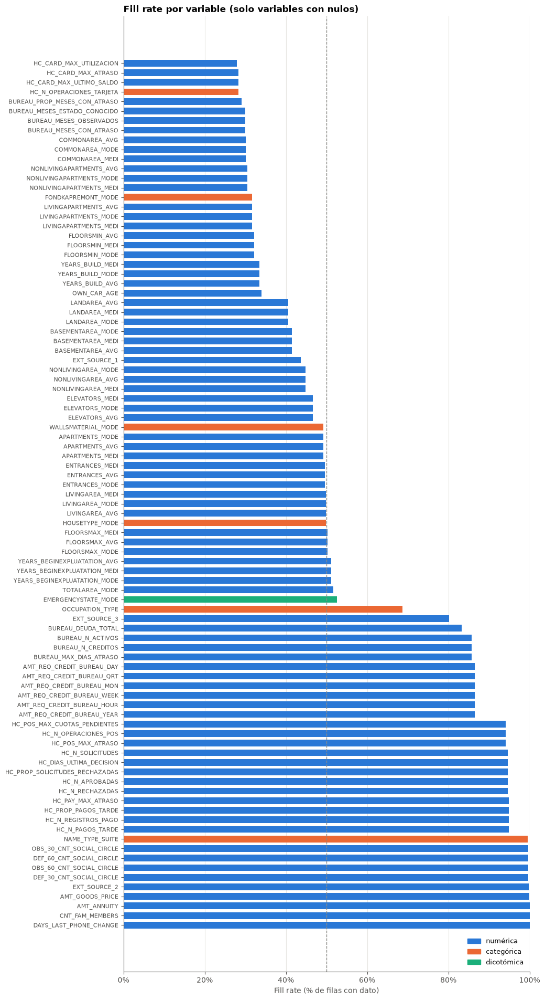

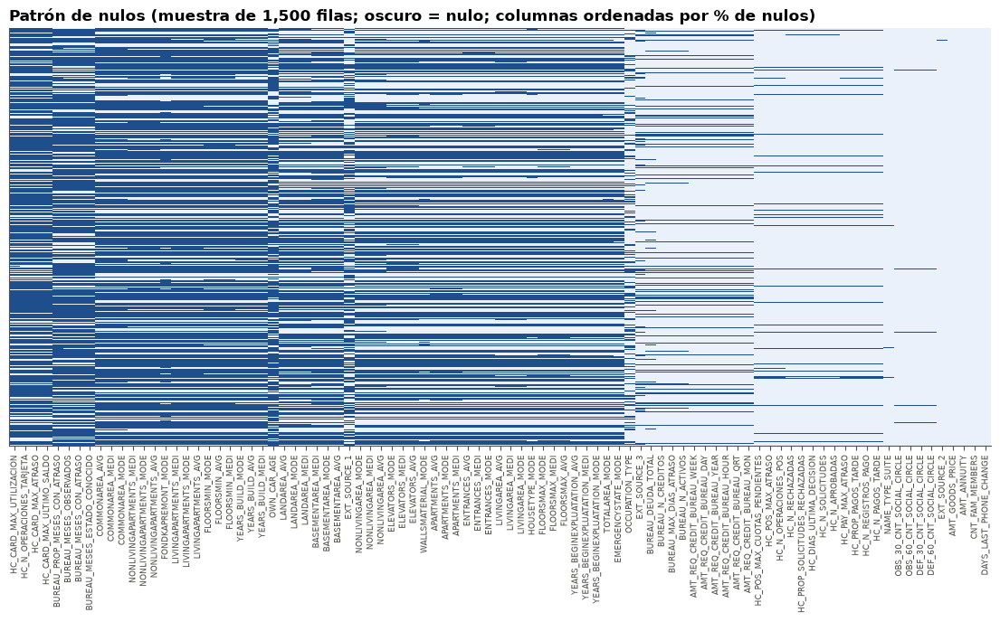

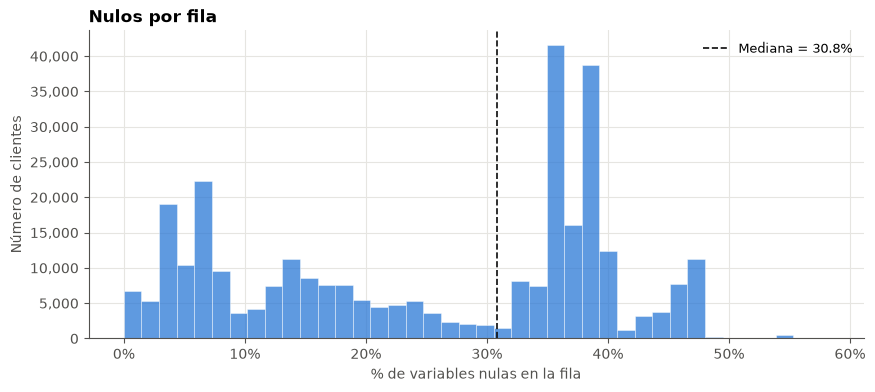

,pct_nulos_por_fila
count,"307,511.000"
mean,0.251
std,0.147
min,0.000
5%,0.034
25%,0.096
50%,0.308
75%,0.384
95%,0.459
max,0.582


In [12]:
def grafico_fill_rate():
    t = calidad.loc[(calidad["n_nulos"] > 0) & calidad["tipo"].isin(["numérica", "categórica", "dicotómica", "constante"])]
    t = t.sort_values("fill_rate")
    colores = {"numérica": C_PRINCIPAL, "categórica": C_TEORICA, "dicotómica": C_TERCERO, "constante": C_REF}
    fig, ax = plt.subplots(figsize=(10, 0.24 * len(t) + 1.8))
    ax.barh(range(len(t)), t["fill_rate"], color=[colores[x] for x in t["tipo"]], height=0.7)
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels(t.index, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.axvline(0.5, color=C_REF, lw=1, ls="--")
    ax.set_xlabel("Fill rate (% de filas con dato)")
    ax.set_title("Fill rate por variable (solo variables con nulos)")
    ax.grid(axis="y", visible=False)
    ax.legend(handles=[Patch(color=colores[k], label=k) for k in colores if k in set(t["tipo"])], loc="lower right")
    return guardar_figura(fig, "calidad_datos", "01_fill_rate_por_variable")


def grafico_matriz_nulos(n_filas=1500):
    cols = calidad.loc[(calidad["n_nulos"] > 0) & ~calidad["tipo"].isin(["identificador", "objetivo"])].sort_values("pct_nulos", ascending=False).index
    muestra = df[cols].sample(n_filas, random_state=SEMILLA)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(muestra.isna().to_numpy(), aspect="auto", interpolation="nearest", cmap=ListedColormap(["#eaf1fb", "#1f4e8c"]))
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=90, fontsize=6.5)
    ax.set_yticks([])
    ax.grid(False)
    ax.set_title(f"Patrón de nulos (muestra de {n_filas:,} filas; oscuro = nulo; columnas ordenadas por % de nulos)")
    return guardar_figura(fig, "calidad_datos", "02_matriz_nulos")


def grafico_nulos_por_fila():
    cols = [c for c in df.columns if c not in (COL_ID, COL_TARGET)]
    pct_fila = df[cols].isna().mean(axis=1)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(pct_fila, bins=40, color=C_PRINCIPAL, alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.axvline(pct_fila.median(), color=C_TEXTO, lw=1.2, ls="--", label=f"Mediana = {pct_fila.median():.1%}")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_xlabel("% de variables nulas en la fila")
    ax.set_ylabel("Número de clientes")
    ax.set_title("Nulos por fila")
    ax.legend()
    guardar_figura(fig, "calidad_datos", "03_nulos_por_fila")
    return pct_fila.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame("pct_nulos_por_fila")


grafico_fill_rate()
grafico_matriz_nulos()
display(grafico_nulos_por_fila())

### Resumen de alertas por variable
Alertas para revisar (no exclusiones): nulos altos, casi constante, centinela, asimetría > 2, outliers IQR > 5 %, mayoría de ceros y cardinalidad alta.

In [13]:
UMBRAL_NULOS_ALTO = 0.40
UMBRAL_CASI_CONSTANTE = 0.95
UMBRAL_ASIMETRIA = 2.0
UMBRAL_OUTLIERS = 0.05
UMBRAL_CEROS = 0.50

registros = []
for col in df.columns:
    tipo = tipos.loc[col, "tipo"]
    if tipo in ("identificador", "objetivo"):
        continue
    a = []
    if calidad.loc[col, "pct_nulos"] >= UMBRAL_NULOS_ALTO:
        a.append("nulos altos")
    if tipo == "constante":
        a.append("constante")
    elif tipo == "numérica":
        m = METRICAS.loc[col]
        if m["pct_moda"] > UMBRAL_CASI_CONSTANTE: a.append("casi constante")
        if not np.isnan(m["centinela"]): a.append("valor centinela")
        if abs(m["asimetria"]) > UMBRAL_ASIMETRIA: a.append("asimetría alta")
        if m["pct_outliers_iqr"] > UMBRAL_OUTLIERS: a.append("outliers (IQR)")
        if m["pct_ceros"] > UMBRAL_CEROS: a.append("mayoría de ceros")
    elif tipo == "dicotómica":
        if DICO.loc[col, "casi_constante"]: a.append("casi constante")
    elif tipo == "categórica":
        if CATM.loc[col, "pct_moda"] > UMBRAL_CASI_CONSTANTE: a.append("casi constante")
        if CATM.loc[col, "cardinalidad_alta"]: a.append("cardinalidad alta")
    registros.append({"variable": col, "tipo": tipo, "fill_rate": calidad.loc[col, "fill_rate"], "n_alertas": len(a), "alertas": ", ".join(a)})

ALERTAS = pd.DataFrame(registros).set_index("variable")

# Conteo de alertas por tipo de alerta y de variable
# (reset_index(drop=True) tras el explode: evita etiquetas de índice duplicadas)
largo = (ALERTAS.loc[ALERTAS["n_alertas"] > 0, ["tipo", "alertas"]]
         .assign(alerta=lambda d: d["alertas"].str.split(", "))
         .explode("alerta")
         .reset_index(drop=True))
display(pd.crosstab(largo["alerta"], largo["tipo"], margins=True, margins_name="Total"))

print(f"\nVariables sin ninguna alerta: {(ALERTAS['n_alertas'] == 0).sum()} de {len(ALERTAS)}")
mostrar(ALERTAS.loc[ALERTAS["n_alertas"] > 0].sort_values(["n_alertas", "fill_rate"], ascending=[False, True]), pct=["fill_rate"])

tipo,categórica,dicotómica,numérica,Total
alerta,,,,
asimetría alta,0,0,61,61
cardinalidad alta,2,0,0,2
casi constante,2,18,4,24
mayoría de ceros,0,0,25,25
nulos altos,4,1,52,57
outliers (IQR),0,0,50,50
valor centinela,0,0,1,1
Total,8,19,193,220



Variables sin ninguna alerta: 45 de 146


,tipo,fill_rate,n_alertas,alertas
variable,,,,
HC_CARD_MAX_ATRASO,numérica,28.26%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
HC_CARD_MAX_ULTIMO_SALDO,numérica,28.26%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
BUREAU_PROP_MESES_CON_ATRASO,numérica,29.13%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
BUREAU_MESES_CON_ATRASO,numérica,29.93%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
NONLIVINGAPARTMENTS_AVG,numérica,30.57%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
NONLIVINGAPARTMENTS_MODE,numérica,30.57%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
NONLIVINGAPARTMENTS_MEDI,numérica,30.57%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
ELEVATORS_AVG,numérica,46.70%,4,"nulos altos, asimetría alta, outliers (IQR), m..."
ELEVATORS_MODE,numérica,46.70%,4,"nulos altos, asimetría alta, outliers (IQR), m..."


### Diagnóstico de valores faltantes (*missings*) y centinelas
Evidencia (inventario, centinela, nulos estructurales, `EXT_SOURCE`, vivienda, despreciables) → plan, implementación, validación y exportación en el Paso 3. Sin partición: todo el dataset es train.

In [14]:
# ── 8.0 Configuración de la sección ─────────────────────────────────────────────────────────────
import json

N_MIN_GRUPO = 200                                   # mín. de obs. no nulas para usar la mediana de una celda (edad × ingreso)
EDAD_CORTES = [0, 30, 40, 50, 60, 120]
EDAD_ETIQ = ["≤30", "30-40", "40-50", "50-60", ">60"]

IMG_SUB.setdefault("missings", list(IMG_SUB.values())[0].parent / "missings")
IMG_SUB["missings"].mkdir(parents=True, exist_ok=True)

# Todo el dataset es la data de entrenamiento (application_train): NO se particiona.
# Los estadísticos de imputación y los hallazgos que usan TARGET se calculan con todos los clientes.
TASA_BASE = df[COL_TARGET].mean()

resumen_base = pd.DataFrame({"n_clientes": [len(df)], "n_default": [int(df[COL_TARGET].sum())], "tasa_default": [TASA_BASE]},
                            index=["dataset completo (train)"])
mostrar(resumen_base, pct=["tasa_default"], enteros=["n_clientes", "n_default"])

,n_clientes,n_default,tasa_default
dataset completo (train),"307,511","24,825",8.07%


#### Inventario de nulos
Default de quienes tienen vs. no tienen el dato: si difiere, el nulo es informativo.

91 variables con nulos (de 148). Las 47 de vivienda se resumen aparte (bloque de vivienda).


,familia,tipo,n_nulos,fill_rate,default_si_nulo,default_si_no_nulo,razon_default
variable,,,,,,,
HC_CARD_MAX_UTILIZACION,Tarjeta de crédito,numérica,"221,475",27.98%,7.85%,8.64%,0.909
HC_CARD_MAX_ATRASO,Tarjeta de crédito,numérica,"220,606",28.26%,7.84%,8.67%,0.904
HC_CARD_MAX_ULTIMO_SALDO,Tarjeta de crédito,numérica,"220,606",28.26%,7.84%,8.67%,0.904
HC_N_OPERACIONES_TARJETA,Tarjeta de crédito,categórica,"220,606",28.26%,7.84%,8.67%,0.904
BUREAU_PROP_MESES_CON_ATRASO,Buró,numérica,"217,933",29.13%,8.05%,8.13%,0.990
BUREAU_MESES_CON_ATRASO,Buró,numérica,"215,465",29.93%,8.05%,8.13%,0.990
BUREAU_MESES_ESTADO_CONOCIDO,Buró,numérica,"215,465",29.93%,8.05%,8.13%,0.990
BUREAU_MESES_OBSERVADOS,Buró,numérica,"215,465",29.93%,8.05%,8.13%,0.990
OWN_CAR_AGE,Auto,numérica,"202,929",34.01%,8.50%,7.24%,1.173



Tasa base de default: 8.07%. Vivienda: fill rate entre 30.1% y 52.6%.


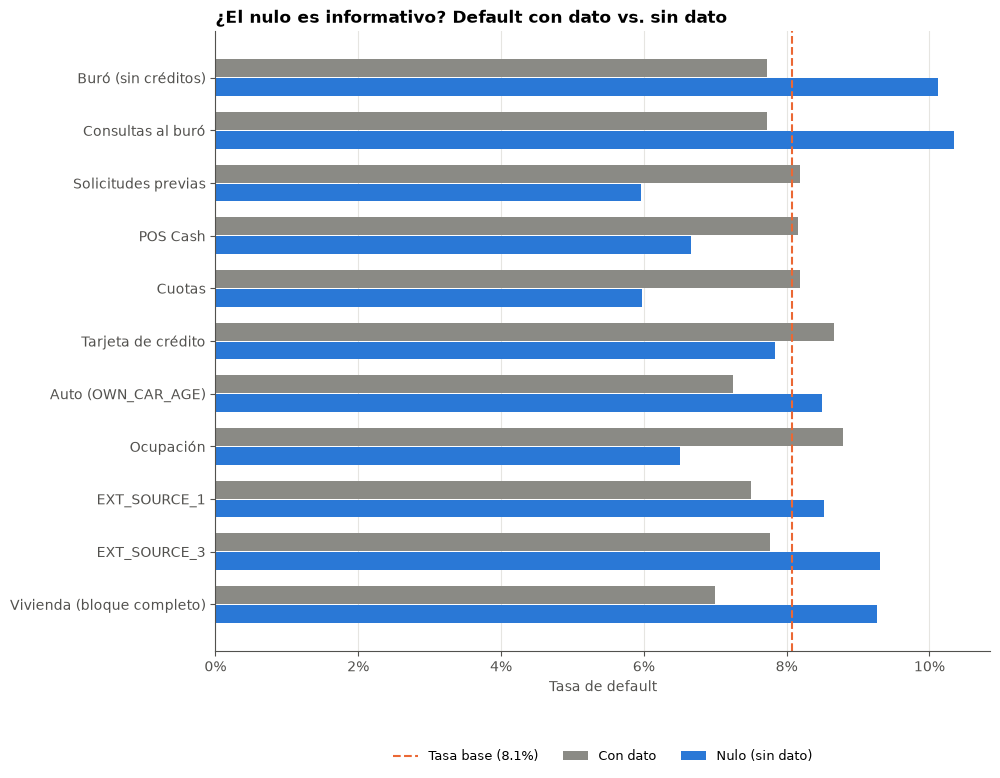

PosixPath('/home/claude/repo/artifacts/eda_figures/missings/01_default_nulo_vs_no_nulo.png')

In [15]:
VIVIENDA = [c for c in df.columns if c.endswith(("_AVG", "_MODE", "_MEDI"))]   # 42 numéricas + TOTALAREA_MODE + 4 categóricas
CONSULTAS_BURO = [c for c in df.columns if c.startswith("AMT_REQ_CREDIT_BUREAU")]
SOCIAL = [c for c in df.columns if c.endswith("_CNT_SOCIAL_CIRCLE")]
EXT = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

# Corregido al tablón oficial: cada familia = variables oficiales de esa tabla de origen
# (antes: bureau_*, prev_*, pos_*, inst_*, cc_* del tablón propio de 133 columnas).
FAMILIAS_NULOS = {
    "Buró": ["BUREAU_N_CREDITOS", "BUREAU_N_ACTIVOS", "BUREAU_DEUDA_TOTAL", "BUREAU_MAX_DIAS_ATRASO", "BUREAU_MESES_OBSERVADOS",
             "BUREAU_MESES_CON_ATRASO", "BUREAU_MESES_ESTADO_CONOCIDO", "BUREAU_PROP_MESES_CON_ATRASO"] + CONSULTAS_BURO,
    "Solicitudes previas": ["HC_N_SOLICITUDES", "HC_N_APROBADAS", "HC_N_RECHAZADAS", "HC_DIAS_ULTIMA_DECISION", "HC_PROP_SOLICITUDES_RECHAZADAS"],
    "POS Cash": ["HC_N_OPERACIONES_POS", "HC_POS_MAX_ATRASO", "HC_POS_MAX_CUOTAS_PENDIENTES"],
    "Cuotas": ["HC_N_REGISTROS_PAGO", "HC_N_PAGOS_TARDE", "HC_PAY_MAX_ATRASO", "HC_PROP_PAGOS_TARDE"],
    "Tarjeta de crédito": ["HC_N_OPERACIONES_TARJETA", "HC_CARD_MAX_ATRASO", "HC_CARD_MAX_UTILIZACION", "HC_CARD_MAX_ULTIMO_SALDO"],
    "Auto": ["OWN_CAR_AGE"],
    "Empleo": ["OCCUPATION_TYPE"],
    "Score externo": EXT,
    "Vivienda (edificio)": VIVIENDA,
    "Círculo social": SOCIAL,
}
FAMILIA_DE = {c: fam for fam, cols in FAMILIAS_NULOS.items() for c in cols}


def _tasa(d, mascara):
    return d.loc[mascara, COL_TARGET].mean() if mascara.any() else np.nan


filas = []
for c in df.columns:
    if c in (COL_ID, COL_TARGET) or df[c].isna().sum() == 0:
        continue
    nul = df[c].isna()
    filas.append({"variable": c, "familia": FAMILIA_DE.get(c, "Otros (nulos menores)"), "tipo": tipos.loc[c, "tipo"],
                  "n_nulos": int(df[c].isna().sum()), "fill_rate": calidad.loc[c, "fill_rate"],
                  "default_si_nulo": _tasa(df, nul), "default_si_no_nulo": _tasa(df, ~nul)})
INVENTARIO = pd.DataFrame(filas).set_index("variable")
INVENTARIO["razon_default"] = INVENTARIO["default_si_nulo"] / INVENTARIO["default_si_no_nulo"]

print(f"{len(INVENTARIO)} variables con nulos (de {df.shape[1]}). Las {len(VIVIENDA)} de vivienda se resumen aparte (bloque de vivienda).")
vista = INVENTARIO.loc[~INVENTARIO.index.isin(VIVIENDA)].sort_values("fill_rate")
mostrar(vista, pct=["fill_rate", "default_si_nulo", "default_si_no_nulo"], enteros=["n_nulos"])
print(f"\nTasa base de default: {TASA_BASE:.2%}. Vivienda: fill rate entre "
      f"{INVENTARIO.loc[INVENTARIO.index.isin(VIVIENDA), 'fill_rate'].min():.1%} y {INVENTARIO.loc[INVENTARIO.index.isin(VIVIENDA), 'fill_rate'].max():.1%}.")

# Representante de cada familia: la variable de conteo oficial (es nula solo si no hay registros en esa tabla)
REPRESENTANTES = [("Buró (sin créditos)", "BUREAU_N_CREDITOS"), ("Consultas al buró", "AMT_REQ_CREDIT_BUREAU_YEAR"),
                  ("Solicitudes previas", "HC_N_SOLICITUDES"), ("POS Cash", "HC_N_OPERACIONES_POS"), ("Cuotas", "HC_N_REGISTROS_PAGO"),
                  ("Tarjeta de crédito", "HC_N_OPERACIONES_TARJETA"), ("Auto (OWN_CAR_AGE)", "OWN_CAR_AGE"), ("Ocupación", "OCCUPATION_TYPE"),
                  ("EXT_SOURCE_1", "EXT_SOURCE_1"), ("EXT_SOURCE_3", "EXT_SOURCE_3"), ("Vivienda (bloque completo)", "__vivienda__")]


def grafico_default_nulos():
    etiquetas, d_nulo, d_no = [], [], []
    for nombre, col in REPRESENTANTES:
        nul = df[VIVIENDA].isna().all(axis=1) if col == "__vivienda__" else df[col].isna()
        etiquetas.append(nombre); d_nulo.append(_tasa(df, nul)); d_no.append(_tasa(df, ~nul))
    y = np.arange(len(etiquetas))
    fig, ax = plt.subplots(figsize=(10, 0.55 * len(etiquetas) + 2))
    ax.barh(y - 0.18, d_no, height=0.34, color=C_REF, label="Con dato")
    ax.barh(y + 0.18, d_nulo, height=0.34, color=C_PRINCIPAL, label="Nulo (sin dato)")
    ax.axvline(TASA_BASE, color=C_TEORICA, lw=1.5, ls="--", label=f"Tasa base ({TASA_BASE:.1%})")
    ax.set_yticks(y); ax.set_yticklabels(etiquetas); ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_xlabel("Tasa de default")
    ax.set_title("¿El nulo es informativo? Default con dato vs. sin dato")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)
    ax.grid(axis="y", visible=False)
    return guardar_figura(fig, "missings", "01_default_nulo_vs_no_nulo")


grafico_default_nulos()

### 2.1) Numéricas

#### Centinela de `DAYS_EMPLOYED`
Default según antigüedad laboral y posición del grupo con centinela.

,n_clientes,tasa_default
tramo,,
≤ 90 días,903,10.74%
90 d – 1 año,"27,079",10.98%
1 – 3 años,"61,472",11.07%
3 – 10 años,"111,729",8.34%
> 10 años,"50,954",5.19%
Centinela (sin empleo),"55,374",5.40%


Ceros reales en DAYS_EMPLOYED (sin contar el centinela): 2


,n
Filas con el centinela,"55,374"
… que tienen ORGANIZATION_TYPE = 'XNA',"55,374"
… que son NAME_INCOME_TYPE = 'Pensioner',"55,352"
… con FLAG_EMP_PHONE = 0,"55,374"
… con OCCUPATION_TYPE nulo,"55,372"
Total ORGANIZATION_TYPE = 'XNA',"55,374"


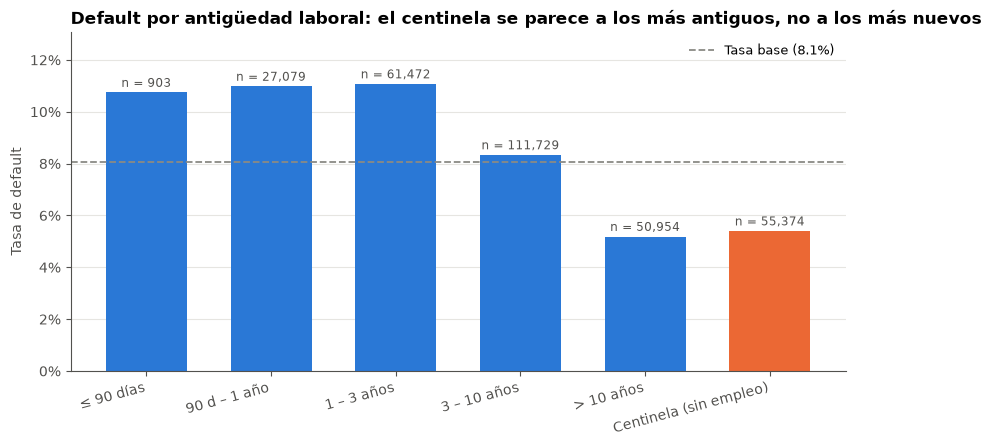

PosixPath('/home/claude/repo/artifacts/eda_figures/missings/02_default_por_antiguedad_y_centinela.png')

In [16]:
SENT = METRICAS.loc["DAYS_EMPLOYED", "centinela"]
es_sent = df["DAYS_EMPLOYED"] == SENT
dias = -df["DAYS_EMPLOYED"].where(~es_sent)         # antigüedad en días (positiva); NaN en el centinela
ORDEN_TRAMOS = ["≤ 90 días", "90 d – 1 año", "1 – 3 años", "3 – 10 años", "> 10 años", "Centinela (sin empleo)"]
tramo = (pd.cut(dias, [-np.inf, 90, 365, 1095, 3650, np.inf], labels=ORDEN_TRAMOS[:-1]).astype(object)
         .mask(es_sent, ORDEN_TRAMOS[-1]))
TENENCIA = (df.assign(tramo=tramo).groupby("tramo")[COL_TARGET].agg(n_clientes="size", tasa_default="mean").reindex(ORDEN_TRAMOS))
mostrar(TENENCIA, pct=["tasa_default"], enteros=["n_clientes"])
print(f"Ceros reales en DAYS_EMPLOYED (sin contar el centinela): {int((df.loc[~es_sent, 'DAYS_EMPLOYED'] == 0).sum())}")

coincidencias = pd.Series({
    "Filas con el centinela": int(es_sent.sum()),
    "… que tienen ORGANIZATION_TYPE = 'XNA'": int((es_sent & (df["ORGANIZATION_TYPE"] == "XNA")).sum()),
    "… que son NAME_INCOME_TYPE = 'Pensioner'": int((es_sent & (df["NAME_INCOME_TYPE"] == "Pensioner")).sum()),
    "… con FLAG_EMP_PHONE = 0": int((es_sent & (df["FLAG_EMP_PHONE"] == 0)).sum()),
    "… con OCCUPATION_TYPE nulo": int((es_sent & df["OCCUPATION_TYPE"].isna()).sum()),
    "Total ORGANIZATION_TYPE = 'XNA'": int((df["ORGANIZATION_TYPE"] == "XNA").sum()),
}, name="n").to_frame()
mostrar(coincidencias, enteros=["n"])


def grafico_tenencia():
    t = TENENCIA
    colores = [C_TEORICA if i == len(t) - 1 else C_PRINCIPAL for i in range(len(t))]
    fig, ax = plt.subplots(figsize=(10, 4.4))
    barras = ax.bar(range(len(t)), t["tasa_default"], color=colores, width=0.65)
    for b, n in zip(barras, t["n_clientes"]):
        ax.annotate(f"n = {int(n):,}", (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8.5, color=C_TEXTO2)
    ax.axhline(TASA_BASE, color=C_REF, lw=1.3, ls="--", label=f"Tasa base ({TASA_BASE:.1%})")
    ax.set_xticks(range(len(t))); ax.set_xticklabels(t.index, rotation=15, ha="right")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_ylabel("Tasa de default"); ax.set_ylim(0, t["tasa_default"].max() * 1.18)
    ax.set_title("Default por antigüedad laboral: el centinela se parece a los más antiguos, no a los más nuevos")
    ax.legend(loc="upper right"); ax.grid(axis="x", visible=False)
    return guardar_figura(fig, "missings", "02_default_por_antiguedad_y_centinela")


grafico_tenencia()

#### Nulos estructurales
¿Hay ceros reales? ¿Los nulos de una tabla ocurren juntos? ¿Los nulos de una familia están contenidos en otra?

In [17]:
filas = []
for fam in ["Buró", "Solicitudes previas", "POS Cash", "Cuotas", "Tarjeta de crédito"]:
    cols = FAMILIAS_NULOS[fam]
    todas = df[cols].isna().all(axis=1)
    for c in cols:
        s = df[c]
        filas.append({"familia": fam, "variable": c, "n_nulos": int(s.isna().sum()), "pct_nulos": s.isna().mean(),
                      "ceros_entre_no_nulos": int((s == 0).sum()), "filas_con_todas_las_var_nulas": int(todas.sum())})
ESTRUCTURAL = pd.DataFrame(filas)
mostrar(ESTRUCTURAL, pct=["pct_nulos"], enteros=["n_nulos", "ceros_entre_no_nulos", "filas_con_todas_las_var_nulas"])
conteos_sin_cero = ESTRUCTURAL.loc[(ESTRUCTURAL["ceros_entre_no_nulos"] == 0), "variable"].tolist()
print("\nLectura (a): variables de historial SIN ningún cero entre los no nulos (el nulo equivale a '0 registros'):", conteos_sin_cero)

# (c) consultas al buró vs. sin buró
sin_buro = df["BUREAU_N_CREDITOS"].isna()
sin_consultas = df[CONSULTAS_BURO].isna().all(axis=1)
display(Markdown("**Consultas al buró (`AMT_REQ_*`) vs. clientes sin créditos en el buró**"))
display(pd.crosstab(sin_consultas.rename("consultas nulas"), sin_buro.rename("sin créditos en buró")))
print(f"Consultas nulas que además están 'sin buró': {int((sin_consultas & sin_buro).sum()):,} de {int(sin_consultas.sum()):,} "
      "→ el nulo de las consultas significa 'no está en el buró', no '0 consultas'.")

# buró: meses con atraso (antes bureau_meses_mora; oficial: solo MONTHS_BALANCE < 0)
tiene_cred = ~sin_buro
print(f"\nBUREAU_MESES_CON_ATRASO: {int(df['BUREAU_MESES_CON_ATRASO'].isna().sum()):,} nulos; {int((df['BUREAU_MESES_CON_ATRASO'].isna() & tiene_cred).sum()):,} "
      f"son clientes CON créditos pero sin detalle mensual (bureau_balance); {int((df['BUREAU_MESES_CON_ATRASO'] == 0).sum()):,} son ceros reales "
      "→ aquí el nulo NO equivale a 0 (mezclaría 'sin detalle' con 'sin mora').")

# auto
sin_auto = df["FLAG_OWN_CAR"] == "N"
print(f"\nOWN_CAR_AGE: {int(df['OWN_CAR_AGE'].isna().sum()):,} nulos; clientes sin auto: {int(sin_auto.sum()):,}; "
      f"nulos que son 'sin auto': {int((df['OWN_CAR_AGE'].isna() & sin_auto).sum()):,}; autos de edad 0 (reales): {int((df['OWN_CAR_AGE'] == 0).sum()):,} "
      "→ el 0 ya existe como valor real: no sirve para representar 'sin auto' (ya lo informa FLAG_OWN_CAR).")

# ocupación
sent_total = df["DAYS_EMPLOYED"] == SENT
occ_nul = df["OCCUPATION_TYPE"].isna()
print(f"\nOCCUPATION_TYPE: {int(occ_nul.sum()):,} nulos; {int((occ_nul & sent_total).sum()):,} coinciden con el centinela de DAYS_EMPLOYED (sin empleo); "
      f"quedan {int((occ_nul & ~sent_total).sum()):,} sin explicación (default: {_tasa(df, df['OCCUPATION_TYPE'].isna() & (df['DAYS_EMPLOYED'] != SENT)):.2%}).")

,familia,variable,n_nulos,pct_nulos,ceros_entre_no_nulos,filas_con_todas_las_var_nulas
0,Buró,BUREAU_N_CREDITOS,"44,020",14.31%,0,"41,519"
1,Buró,BUREAU_N_ACTIVOS,"44,020",14.31%,"46,341","41,519"
2,Buró,BUREAU_DEUDA_TOTAL,"51,380",16.71%,"69,689","41,519"
3,Buró,BUREAU_MAX_DIAS_ATRASO,"44,020",14.31%,"260,094","41,519"
4,Buró,BUREAU_MESES_OBSERVADOS,"215,465",70.07%,0,"41,519"
5,Buró,BUREAU_MESES_CON_ATRASO,"215,465",70.07%,"61,401","41,519"
6,Buró,BUREAU_MESES_ESTADO_CONOCIDO,"215,465",70.07%,"2,468","41,519"
7,Buró,BUREAU_PROP_MESES_CON_ATRASO,"217,933",70.87%,"58,933","41,519"
8,Buró,AMT_REQ_CREDIT_BUREAU_HOUR,"41,519",13.50%,"264,366","41,519"
9,Buró,AMT_REQ_CREDIT_BUREAU_DAY,"41,519",13.50%,"264,503","41,519"



Lectura (a): variables de historial SIN ningún cero entre los no nulos (el nulo equivale a '0 registros'): ['BUREAU_N_CREDITOS', 'BUREAU_MESES_OBSERVADOS', 'HC_N_SOLICITUDES', 'HC_DIAS_ULTIMA_DECISION', 'HC_N_OPERACIONES_POS', 'HC_N_REGISTROS_PAGO', 'HC_N_OPERACIONES_TARJETA']


**Consultas al buró (`AMT_REQ_*`) vs. clientes sin créditos en el buró**

sin créditos en buró,False,True
consultas nulas,,
False,263491,2501
True,0,41519


Consultas nulas que además están 'sin buró': 41,519 de 41,519 → el nulo de las consultas significa 'no está en el buró', no '0 consultas'.

BUREAU_MESES_CON_ATRASO: 215,465 nulos; 171,445 son clientes CON créditos pero sin detalle mensual (bureau_balance); 61,401 son ceros reales → aquí el nulo NO equivale a 0 (mezclaría 'sin detalle' con 'sin mora').

OWN_CAR_AGE: 202,929 nulos; clientes sin auto: 202,924; nulos que son 'sin auto': 202,924; autos de edad 0 (reales): 2,134 → el 0 ya existe como valor real: no sirve para representar 'sin auto' (ya lo informa FLAG_OWN_CAR).

OCCUPATION_TYPE: 96,391 nulos; 55,372 coinciden con el centinela de DAYS_EMPLOYED (sin empleo); quedan 41,019 sin explicación (default: 8.02%).


#### `EXT_SOURCE_1` y `EXT_SOURCE_3`
El nulo depende de la edad y del tipo de ingreso. **Decisión final (03-10-2026): no se imputa.** La mediana por grupo creaba picos y llevaba a los nulos (con más default que el promedio) a tramos de score sano; el nulo queda como tramo propio en el WoE.

Tipos de ingreso con grupo propio: ['Working', 'Commercial associate', 'Pensioner', 'State servant'] | resto → 'Other'


**% de nulos de `EXT_SOURCE_1` por edad × tipo de ingreso**

NAME_INCOME_TYPE,Commercial associate,Other,Pensioner,State servant,Working
DAYS_BIRTH,,,,,
30-40,41.1%,35.7%,54.8%,40.1%,44.6%
40-50,53.3%,57.1%,61.0%,52.1%,57.5%
50-60,65.6%,75.0%,73.6%,63.9%,69.2%
>60,74.8%,60.0%,80.8%,75.6%,76.6%
≤30,41.5%,60.0%,51.1%,38.7%,43.1%


EXT_SOURCE_1: mediana global 0.506 | medianas por celda entre 0.270 y 0.881 | celdas con n < 200: 7 de 25


ing,Commercial associate,Other,Pensioner,State servant,Working
edad,,,,,
30-40,0.456,0.376,0.376,0.469,0.420
40-50,0.595,0.612,0.556,0.615,0.557
50-60,0.706,0.724,0.711,0.731,0.676
>60,0.800,0.881,0.768,0.808,0.772
≤30,0.322,0.291,0.270,0.329,0.293


**% de nulos de `EXT_SOURCE_3` por edad × tipo de ingreso**

NAME_INCOME_TYPE,Commercial associate,Other,Pensioner,State servant,Working
DAYS_BIRTH,,,,,
30-40,19.3%,50.0%,34.3%,13.7%,19.0%
40-50,19.0%,64.3%,23.2%,13.2%,18.1%
50-60,19.6%,41.7%,18.4%,13.1%,18.7%
>60,17.3%,100.0%,20.7%,12.6%,15.7%
≤30,27.5%,60.0%,37.6%,23.5%,26.8%


EXT_SOURCE_3: mediana global 0.535 | medianas por celda entre 0.291 y 0.709 | celdas con n < 200: 5 de 24


ing,Commercial associate,Other,Pensioner,State servant,Working
edad,,,,,
30-40,0.515,0.496,0.508,0.529,0.510
40-50,0.550,0.479,0.583,0.559,0.548
50-60,0.562,0.709,0.569,0.578,0.562
>60,0.587,NaN,0.613,0.598,0.583
≤30,0.431,0.291,0.492,0.451,0.429


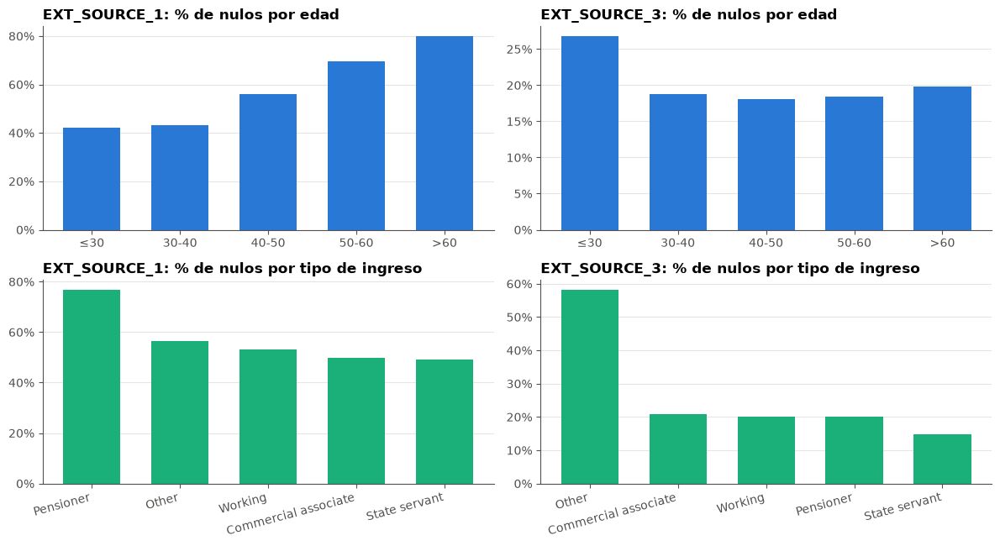

PosixPath('/home/claude/repo/artifacts/eda_figures/missings/03_nulos_ext_source_por_grupo.png')

In [18]:
INGRESOS_PRINCIPALES = df["NAME_INCOME_TYPE"].value_counts(normalize=True).loc[lambda s: s >= 0.01].index.tolist()


def claves_grupo(d):
    # Edad en tramos y tipo de ingreso (los tipos con < 1 % de los clientes se agrupan en 'Other').
    edad = pd.cut(-d["DAYS_BIRTH"] / 365.25, EDAD_CORTES, labels=EDAD_ETIQ).astype(str)
    ing = d["NAME_INCOME_TYPE"].where(d["NAME_INCOME_TYPE"].isin(INGRESOS_PRINCIPALES), "Other")
    return edad, ing


edad_tr, ing_tr = claves_grupo(df)
print("Tipos de ingreso con grupo propio:", INGRESOS_PRINCIPALES, "| resto → 'Other'")
for c in ["EXT_SOURCE_1", "EXT_SOURCE_3"]:
    pct_nulo = pd.crosstab(edad_tr, ing_tr, values=df[c].isna(), aggfunc="mean")
    display(Markdown(f"**% de nulos de `{c}` por edad × tipo de ingreso**"))
    display(pct_nulo.apply(lambda col: col.map(lambda v: "" if pd.isna(v) else f"{v:.1%}")))

    ok = df[c].notna()
    g = pd.DataFrame({"v": df.loc[ok, c], "edad": edad_tr[ok], "ing": ing_tr[ok]})
    celdas = g.groupby(["edad", "ing"])["v"].agg(n="size", mediana="median")
    print(f"{c}: mediana global {df[c].median():.3f} | medianas por celda entre {celdas['mediana'].min():.3f} y {celdas['mediana'].max():.3f} "
          f"| celdas con n < {N_MIN_GRUPO}: {int((celdas['n'] < N_MIN_GRUPO).sum())} de {len(celdas)}")
    display(celdas["mediana"].unstack("ing").round(3))


def grafico_nulos_ext():
    fig, axes = plt.subplots(2, 2, figsize=(12, 6.6))
    for j, c in enumerate(["EXT_SOURCE_1", "EXT_SOURCE_3"]):
        a = df[c].isna().groupby(edad_tr).mean().reindex(EDAD_ETIQ)
        axes[0, j].bar(range(len(a)), a.values, color=C_PRINCIPAL, width=0.65)
        axes[0, j].set_xticks(range(len(a))); axes[0, j].set_xticklabels(a.index)
        axes[0, j].set_title(f"{c}: % de nulos por edad")
        b = df[c].isna().groupby(ing_tr).mean().sort_values(ascending=False)
        axes[1, j].bar(range(len(b)), b.values, color=C_TERCERO, width=0.65)
        axes[1, j].set_xticks(range(len(b))); axes[1, j].set_xticklabels(b.index, rotation=15, ha="right")
        axes[1, j].set_title(f"{c}: % de nulos por tipo de ingreso")
        for ax in axes[:, j]:
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.grid(axis="x", visible=False)
    fig.tight_layout()
    return guardar_figura(fig, "missings", "03_nulos_ext_source_por_grupo")


grafico_nulos_ext()

#### Bloque de vivienda (47 variables)
Estado por cliente (sin info / parcial / completa) y su default. Decisión: dejar el `NaN` y crear `flag_sin_info_vivienda`.

,n_clientes,pct_clientes,tasa_default
estado_vivienda,,,
info completa,"78,595",25.56%,6.96%
info parcial,"83,161",27.04%,7.04%
sin ninguna info,"145,755",47.40%,9.26%


En las filas con info parcial faltan, en mediana, 16 de las 47 variables.


**% de clientes 'sin ninguna info' de vivienda según `NAME_HOUSING_TYPE`**

,pct_sin_info,n_clientes
NAME_HOUSING_TYPE,,
Rented apartment,63.72%,"4,881"
With parents,54.25%,"14,840"
Office apartment,50.86%,"2,617"
House / apartment,47.42%,"272,868"
Co-op apartment,39.57%,"1,122"
Municipal apartment,30.64%,"11,183"


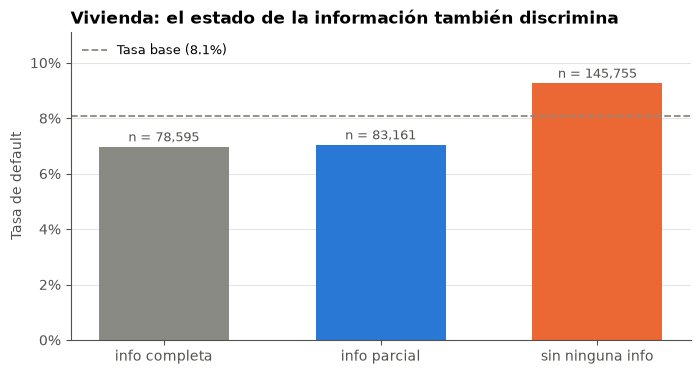

PosixPath('/home/claude/repo/artifacts/eda_figures/missings/04_default_por_estado_vivienda.png')

In [19]:
n_null_viv = df[VIVIENDA].isna().sum(axis=1)
estado_viv = pd.Series(np.select([n_null_viv == len(VIVIENDA), n_null_viv == 0], ["sin ninguna info", "info completa"], "info parcial"),
                       index=df.index, name="estado_vivienda")
ORDEN_VIV = ["info completa", "info parcial", "sin ninguna info"]
tabla_viv = pd.DataFrame({"n_clientes": estado_viv.value_counts(), "pct_clientes": estado_viv.value_counts(normalize=True)}).reindex(ORDEN_VIV)
tabla_viv["tasa_default"] = df.groupby(estado_viv)[COL_TARGET].mean().reindex(ORDEN_VIV)
mostrar(tabla_viv, pct=["pct_clientes", "tasa_default"], enteros=["n_clientes"])

parcial = estado_viv == "info parcial"
print(f"En las filas con info parcial faltan, en mediana, {int(n_null_viv[parcial].median())} de las {len(VIVIENDA)} variables.")

display(Markdown("**% de clientes 'sin ninguna info' de vivienda según `NAME_HOUSING_TYPE`**"))
por_tipo = (estado_viv == "sin ninguna info").groupby(df["NAME_HOUSING_TYPE"]).agg(pct_sin_info="mean", n_clientes="size")
mostrar(por_tipo.sort_values("pct_sin_info", ascending=False), pct=["pct_sin_info"], enteros=["n_clientes"])


def grafico_vivienda():
    t = tabla_viv
    fig, ax = plt.subplots(figsize=(8, 4))
    b = ax.bar(range(len(t)), t["tasa_default"], color=[C_REF, C_PRINCIPAL, C_TEORICA], width=0.6)
    for r, n in zip(b, t["n_clientes"]):
        ax.annotate(f"n = {int(n):,}", (r.get_x() + r.get_width() / 2, r.get_height()), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9, color=C_TEXTO2)
    ax.axhline(TASA_BASE, color=C_REF, lw=1.3, ls="--", label=f"Tasa base ({TASA_BASE:.1%})")
    ax.set_xticks(range(len(t))); ax.set_xticklabels(t.index)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_ylim(0, t["tasa_default"].max() * 1.2)
    ax.set_ylabel("Tasa de default"); ax.set_title("Vivienda: el estado de la información también discrimina")
    ax.legend(loc="upper left"); ax.grid(axis="x", visible=False)
    return guardar_figura(fig, "missings", "04_default_por_estado_vivienda")


grafico_vivienda()

#### Nulos despreciables (< 0,5 %)
Moda (conteos y categorías), razón mediana sobre `AMT_CREDIT` (montos) o mediana.

In [20]:
menores = {c: int(df[c].isna().sum()) for c in ["NAME_TYPE_SUITE"] + SOCIAL + ["AMT_GOODS_PRICE", "AMT_ANNUITY", "CNT_FAM_MEMBERS", "DAYS_LAST_PHONE_CHANGE", "EXT_SOURCE_2"]}
menores["CODE_GENDER = 'XNA' (categoría centinela)"] = int((df["CODE_GENDER"] == "XNA").sum())
menores["NAME_FAMILY_STATUS = 'Unknown' (categoría centinela)"] = int((df["NAME_FAMILY_STATUS"] == "Unknown").sum())
MENORES = pd.Series(menores, name="n_casos").to_frame()
MENORES["pct_del_total"] = MENORES["n_casos"] / len(df)
mostrar(MENORES.sort_values("n_casos", ascending=False), pct=["pct_del_total"], enteros=["n_casos"])

# Conteos del círculo social: media vs. mediana vs. moda
CONT = pd.DataFrame({"media": df[SOCIAL].mean(), "mediana": df[SOCIAL].median(), "moda": df[SOCIAL].mode().iloc[0], "pct_ceros": (df[SOCIAL] == 0).mean()})
display(Markdown("**Círculo social: ¿media, mediana o moda?**"))
mostrar(CONT, pct=["pct_ceros"])


# Montos: ¿mediana global o razón mediana sobre AMT_CREDIT? (error relativo mediano sobre los datos no nulos)
def _err_rel(real, pred):
    return float(np.median(np.abs(real - pred) / real))


filas = []
for c in ["AMT_GOODS_PRICE", "AMT_ANNUITY"]:
    ok = df[c].notna()
    razon = (df[c] / df["AMT_CREDIT"]).groupby(df["NAME_CONTRACT_TYPE"]).median()
    pred_razon = df.loc[ok, "AMT_CREDIT"] * df.loc[ok, "NAME_CONTRACT_TYPE"].map(razon)
    filas.append({"variable": c, "corr_spearman_con_AMT_CREDIT": df.loc[ok, [c, "AMT_CREDIT"]].corr(method="spearman").iloc[0, 1],
                  "error_rel_mediano_con_mediana_global": _err_rel(df.loc[ok, c], df.loc[ok, c].median()),
                  "error_rel_mediano_con_razon_por_contrato": _err_rel(df.loc[ok, c], pred_razon)})
display(Markdown("**Montos: error relativo mediano al imputar (menor = mejor)**"))
mostrar(pd.DataFrame(filas).set_index("variable"), pct=["error_rel_mediano_con_mediana_global", "error_rel_mediano_con_razon_por_contrato"])

,n_casos,pct_del_total
NAME_TYPE_SUITE,"1,292",0.42%
OBS_30_CNT_SOCIAL_CIRCLE,"1,021",0.33%
DEF_30_CNT_SOCIAL_CIRCLE,"1,021",0.33%
OBS_60_CNT_SOCIAL_CIRCLE,"1,021",0.33%
DEF_60_CNT_SOCIAL_CIRCLE,"1,021",0.33%
EXT_SOURCE_2,660,0.21%
AMT_GOODS_PRICE,278,0.09%
AMT_ANNUITY,12,0.00%
CODE_GENDER = 'XNA' (categoría centinela),4,0.00%
CNT_FAM_MEMBERS,2,0.00%


**Círculo social: ¿media, mediana o moda?**

,media,mediana,moda,pct_ceros
OBS_30_CNT_SOCIAL_CIRCLE,1.422,0.000,0.000,53.30%
DEF_30_CNT_SOCIAL_CIRCLE,0.143,0.000,0.000,88.23%
OBS_60_CNT_SOCIAL_CIRCLE,1.405,0.000,0.000,53.55%
DEF_60_CNT_SOCIAL_CIRCLE,0.100,0.000,0.000,91.29%


**Montos: error relativo mediano al imputar (menor = mejor)**

,corr_spearman_con_AMT_CREDIT,error_rel_mediano_con_mediana_global,error_rel_mediano_con_razon_por_contrato
variable,,,
AMT_GOODS_PRICE,0.985,50.00%,5.83%
AMT_ANNUITY,0.830,34.12%,27.02%


### 2.2) Categóricas
Diagnóstico categórico ya calculado en celdas anteriores: nulos y *fill rate* (inicio del Paso 2), categorías raras y cardinalidad (`CATM`, 1.2),
`OCCUPATION_TYPE` (nulos estructurales) y categorías centinela `CODE_GENDER = 'XNA'` / `NAME_FAMILY_STATUS = 'Unknown'` (nulos despreciables).

> **TODO(Isaac):** la guía pide aquí (2.2) *missing* codificado, baja frecuencia y valores inesperados de las categóricas. En tu notebook esos
> diagnósticos están repartidos en las celdas citadas; decide si los reagrupas en esta subsección.

## Paso 3) Preprocesamiento
Tratamiento de faltantes y centinelas (numéricas y categóricas), luego topes de outliers (numéricas). Sin re-escalado ni *encoding* (la guía los difiere).

### Plan de tratamiento de faltantes y centinelas

In [21]:
PLAN = pd.DataFrame([
    ("Buró: `BUREAU_*` (8 variables), `AMT_REQ_CREDIT_BUREAU_*`", "Estructural", "Sin imputar · `flag_sin_buro` (= `BUREAU_N_CREDITOS` nulo; complemento de `TIENE_BUREAU`)"),
    ("Solicitudes previas: `HC_N_SOLICITUDES`, `HC_N_APROBADAS`, `HC_N_RECHAZADAS`, `HC_DIAS_ULTIMA_DECISION`, `HC_PROP_SOLICITUDES_RECHAZADAS`", "Estructural", "Sin imputar · `flag_sin_previas` (complemento de `TIENE_HISTORIAL_HOME_CREDIT`)"),
    ("Cuotas: `HC_N_REGISTROS_PAGO`, `HC_N_PAGOS_TARDE`, `HC_PAY_MAX_ATRASO`, `HC_PROP_PAGOS_TARDE`", "Estructural", "Sin imputar · sin flag"),
    ("Tarjeta: `HC_N_OPERACIONES_TARJETA`, `HC_CARD_MAX_ATRASO`, `HC_CARD_MAX_UTILIZACION`, `HC_CARD_MAX_ULTIMO_SALDO`", "Estructural", "Sin imputar · sin flag"),
    ("POS Cash: `HC_N_OPERACIONES_POS`, `HC_POS_MAX_ATRASO`, `HC_POS_MAX_CUOTAS_PENDIENTES`", "Estructural", "Sin imputar · sin flag (no se pidió; el nulo se conserva)"),
    ("`OWN_CAR_AGE`", "Estructural", "Sin imputar · ya lo informa `FLAG_OWN_CAR`"),
    ("`DAYS_EMPLOYED` (365243)", "Centinela", "Reemplazo por 0 · `flag_sin_empleo`"),
    ("`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`", "Falta de información", "Sin imputar: el nulo es un tramo propio en el WoE (decisión del 03-10-2026)"),
    ("Vivienda (47 variables)", "Falta de información (bloque)", "Sin imputar valores · `flag_sin_info_vivienda` (recomendación)"),
    ("`OCCUPATION_TYPE`", "Mixto", "Sin imputar (pendiente de decisión)"),
    ("`OBS/DEF_*_CNT_SOCIAL_CIRCLE`, `CNT_FAM_MEMBERS`", "Despreciable", "Moda; `CNT_FAM_MEMBERS` ≥ hijos + 1"),
    ("`AMT_GOODS_PRICE`, `AMT_ANNUITY`", "Despreciable", "`AMT_CREDIT` × razón mediana por tipo de contrato"),
    ("`DAYS_LAST_PHONE_CHANGE`", "Despreciable", "Mediana"),
    ("`NAME_TYPE_SUITE` (nulos), `CODE_GENDER` 'XNA', `NAME_FAMILY_STATUS` 'Unknown'", "Despreciable", "Moda"),
    ("`ORGANIZATION_TYPE` = 'XNA'", "Categoría real ('sin empleador')", "Se conserva como categoría"),
], columns=["variables", "tipo de nulo", "tratamiento"])
with pd.option_context("display.max_colwidth", 200):
    display(PLAN)

,variables,tipo de nulo,tratamiento
0,"Buró: `BUREAU_*` (8 variables), `AMT_REQ_CREDIT_BUREAU_*`",Estructural,Sin imputar · `flag_sin_buro` (= `BUREAU_N_CREDITOS` nulo; complemento de `TIENE_BUREAU`)
1,"Solicitudes previas: `HC_N_SOLICITUDES`, `HC_N_APROBADAS`, `HC_N_RECHAZADAS`, `HC_DIAS_ULTIMA_DECISION`, `HC_PROP_SOLICITUDES_RECHAZADAS`",Estructural,Sin imputar · `flag_sin_previas` (complemento de `TIENE_HISTORIAL_HOME_CREDIT`)
2,"Cuotas: `HC_N_REGISTROS_PAGO`, `HC_N_PAGOS_TARDE`, `HC_PAY_MAX_ATRASO`, `HC_PROP_PAGOS_TARDE`",Estructural,Sin imputar · sin flag
3,"Tarjeta: `HC_N_OPERACIONES_TARJETA`, `HC_CARD_MAX_ATRASO`, `HC_CARD_MAX_UTILIZACION`, `HC_CARD_MAX_ULTIMO_SALDO`",Estructural,Sin imputar · sin flag
4,"POS Cash: `HC_N_OPERACIONES_POS`, `HC_POS_MAX_ATRASO`, `HC_POS_MAX_CUOTAS_PENDIENTES`",Estructural,Sin imputar · sin flag (no se pidió; el nulo se conserva)
5,`OWN_CAR_AGE`,Estructural,Sin imputar · ya lo informa `FLAG_OWN_CAR`
6,`DAYS_EMPLOYED` (365243),Centinela,Reemplazo por 0 · `flag_sin_empleo`
7,"`EXT_SOURCE_1`, `EXT_SOURCE_3`",Falta de información,Mediana por grupo (edad × tipo de ingreso)
8,`EXT_SOURCE_2`,Falta de información,Mediana global
9,Vivienda (47 variables),Falta de información (bloque),Sin imputar valores · `flag_sin_info_vivienda` (recomendación)


### Implementación
`ajustar_imputadores` aprende los parámetros y `aplicar_tratamiento` los aplica.

> **Actualización 03-10-2026 — scores externos sin imputar.** Con la imputación, el 27 % de los nulos de `EXT_SOURCE_1` (default 8.5 %) caía en el decil de score con 3.5 % de default, y los nulos de `EXT_SOURCE_3` (default 9.3 %, más que el promedio) en deciles con 5–8 %: se cargaba la tasa de default de los nulos en rangos sanos y se creaban picos en la distribución. Por eso `IMPUTAR_EXT = False`: los tres scores conservan su nulo y el *binning* (OptBinning) lo trata como un tramo propio. Las salidas de las celdas siguientes son de la ejecución anterior; `artifacts/tablon_imputado.parquet` ya refleja esta decisión.

In [22]:
# ── Parámetros de las decisiones ────────────────────────────────────────────────────────────────
# TODO(Isaac): flag_sin_buro y flag_sin_previas son el complemento exacto de TIENE_BUREAU y TIENE_HISTORIAL_HOME_CREDIT,
#   que ya vienen en el tablón oficial. ¿Los conservas (redundantes) o usas los indicadores oficiales?
FLAGS_ESTRUCTURALES = {"flag_sin_buro": "BUREAU_N_CREDITOS", "flag_sin_previas": "HC_N_SOLICITUDES"}
VALOR_CENTINELA_NUEVO = 0            # DAYS_EMPLOYED = 365243 → 0 (sin días de trabajo)
CREAR_FLAG_SIN_EMPLEO = True         # flag que acompaña al reemplazo del centinela
CREAR_FLAG_VIVIENDA = True           # flag del bloque de vivienda (los valores NO se imputan)
IMPUTAR_EXT = False                  # 03-10-2026: los scores externos NO se imputan (picos y RD de los nulos cargada en tramos sanos)
MEDIANA_GLOBAL = (["EXT_SOURCE_2"] if IMPUTAR_EXT else []) + ["DAYS_LAST_PHONE_CHANGE"]
MODA_NUMERICA = SOCIAL + ["CNT_FAM_MEMBERS"]
MODA_CATEGORICA = {"NAME_TYPE_SUITE": None, "CODE_GENDER": "XNA", "NAME_FAMILY_STATUS": "Unknown"}   # None → rellena nulos; texto → reemplaza esa categoría
RAZON_MONTOS = ["AMT_GOODS_PRICE", "AMT_ANNUITY"]


def ajustar_imputadores(tr):
    # Aprende TODOS los parámetros con el dataset de entrenamiento (todo el tablón).
    P = {"ext_grupo": {}, "mediana": {}, "moda": {}, "moda_cat": {}, "razon": {}}
    edad, ing = claves_grupo(tr)
    for c in (["EXT_SOURCE_1", "EXT_SOURCE_3"] if IMPUTAR_EXT else []):
        ok = tr[c].notna()
        g = pd.DataFrame({"v": tr.loc[ok, c], "edad": edad[ok], "ing": ing[ok]})
        celdas = g.groupby(["edad", "ing"])["v"].agg(["median", "size"])
        P["ext_grupo"][c] = {
            "global": float(tr[c].median()),
            "por_ingreso": {k: float(v) for k, v in g.groupby("ing")["v"].median().items()},
            "por_celda": {f"{a}|{b}": float(r["median"]) for (a, b), r in celdas.iterrows() if r["size"] >= N_MIN_GRUPO},
        }
    for c in MEDIANA_GLOBAL:
        P["mediana"][c] = float(tr[c].median())
    for c in MODA_NUMERICA:
        P["moda"][c] = float(tr[c].mode().iloc[0])
    for c, raro in MODA_CATEGORICA.items():
        validos = tr[c].dropna()
        if raro is not None:
            validos = validos[validos != raro]
        P["moda_cat"][c] = str(validos.mode().iloc[0])
    for c in RAZON_MONTOS:
        r = tr[c] / tr["AMT_CREDIT"]
        P["razon"][c] = {"global": float(r.median()), "por_contrato": {k: float(v) for k, v in r.groupby(tr["NAME_CONTRACT_TYPE"]).median().items()}}
    return P


def aplicar_tratamiento(d, P):
    out = d.copy()
    # 1) Flags: siempre sobre los nulos/centinelas ORIGINALES
    for flag, col in FLAGS_ESTRUCTURALES.items():
        out[flag] = out[col].isna().astype("int8")
    sent = out["DAYS_EMPLOYED"] == SENT
    if CREAR_FLAG_SIN_EMPLEO:
        out["flag_sin_empleo"] = sent.astype("int8")
    if CREAR_FLAG_VIVIENDA:
        out["flag_sin_info_vivienda"] = out[VIVIENDA].isna().all(axis=1).astype("int8")
    # 2) Centinela de DAYS_EMPLOYED
    out.loc[sent, "DAYS_EMPLOYED"] = VALOR_CENTINELA_NUEVO
    # 3) EXT_SOURCE_1/3: mediana por grupo con respaldo (ingreso → global)
    edad, ing = claves_grupo(out)
    clave = edad + "|" + ing
    for c, p in P["ext_grupo"].items():
        valor = clave.map(p["por_celda"]).fillna(ing.map(p["por_ingreso"])).fillna(p["global"])
        out[c] = out[c].fillna(valor)
    # 4) Medianas globales
    for c, m in P["mediana"].items():
        out[c] = out[c].fillna(m)
    # 5) Modas numéricas (CNT_FAM_MEMBERS con la regla miembros ≥ hijos + 1)
    fam_nulo = d["CNT_FAM_MEMBERS"].isna()
    for c, m in P["moda"].items():
        out[c] = out[c].fillna(m)
    out.loc[fam_nulo, "CNT_FAM_MEMBERS"] = np.maximum(out.loc[fam_nulo, "CNT_FAM_MEMBERS"], out.loc[fam_nulo, "CNT_CHILDREN"] + 1)
    # 6) Categóricas
    for c, m in P["moda_cat"].items():
        raro = MODA_CATEGORICA[c]
        out[c] = out[c].fillna(m) if raro is None else out[c].replace(raro, m)
    # 7) Montos: AMT_CREDIT × razón mediana por tipo de contrato
    for c, p in P["razon"].items():
        nul = out[c].isna()
        r = out.loc[nul, "NAME_CONTRACT_TYPE"].map(p["por_contrato"]).fillna(p["global"])
        out.loc[nul, c] = out.loc[nul, "AMT_CREDIT"] * r
    return out


PARAMS = ajustar_imputadores(df)          # ← aprende con todos los clientes (todo el dataset es train)
df_imp = aplicar_tratamiento(df, PARAMS)  # ← se aplica al tablón completo

COLUMNAS_NUEVAS = [c for c in df_imp.columns if c not in df.columns]
print("Columnas nuevas:", COLUMNAS_NUEVAS)
print("Forma original:", df.shape, "→ tratado:", df_imp.shape)
display(df_imp[[c for c in COLUMNAS_NUEVAS if c.startswith("flag_")]].agg(["sum", "mean"]).T.rename(columns={"sum": "n_clientes_con_flag", "mean": "proporción"}))

Columnas nuevas: ['flag_sin_buro', 'flag_sin_previas', 'flag_sin_empleo', 'flag_sin_info_vivienda']
Forma original: (307511, 148) → tratado: (307511, 152)


,n_clientes_con_flag,proporción
flag_sin_buro,"44,020.000",0.143
flag_sin_previas,"16,454.000",0.054
flag_sin_empleo,"55,374.000",0.180
flag_sin_info_vivienda,"145,755.000",0.474


### Validación
Estructura, nulos que deben seguir intactos y valores originales sin tocar; un `assert` detiene la ejecución si algo falla.

,verificación,resultado
0,Mismo número de filas,✔
1,SK_ID_CURR idéntico y único,✔
2,TARGET sin cambios,✔
3,Variables imputadas sin nulos,✔
4,DAYS_EMPLOYED sin el centinela 365243,✔
5,Sin 'XNA' en CODE_GENDER ni 'Unknown' en NAME_...,✔
6,flag_sin_buro = nulos originales de BUREAU_N_C...,✔
7,flag_sin_previas = nulos originales de HC_N_SO...,✔
8,flag_sin_empleo = filas con centinela,✔
9,flag_sin_info_vivienda = filas con las 47 vari...,✔


Todas las verificaciones pasaron.


**Efecto sobre media y desviación estándar** — imputar concentra valores y reduce la dispersión; en `DAYS_EMPLOYED` la comparación 'antes' excluye el centinela

,n_imputados,media_antes,media_despues,std_antes,std_despues
variable,,,,,
AMT_ANNUITY,12,"27,108.574","27,108.584","14,493.737","14,493.839"
AMT_GOODS_PRICE,278,"538,396.207","538,162.275","369,446.461","369,405.272"
CNT_FAM_MEMBERS,2,2.153,2.153,0.911,0.911
DAYS_LAST_PHONE_CHANGE,1,-962.859,-962.858,826.808,826.807
DEF_30_CNT_SOCIAL_CIRCLE,"1,021",0.143,0.143,0.447,0.446
DEF_60_CNT_SOCIAL_CIRCLE,"1,021",0.100,0.100,0.362,0.362
EXT_SOURCE_1,"173,378",0.502,0.546,0.211,0.184
EXT_SOURCE_2,660,0.514,0.515,0.191,0.191
EXT_SOURCE_3,"60,965",0.511,0.514,0.195,0.176


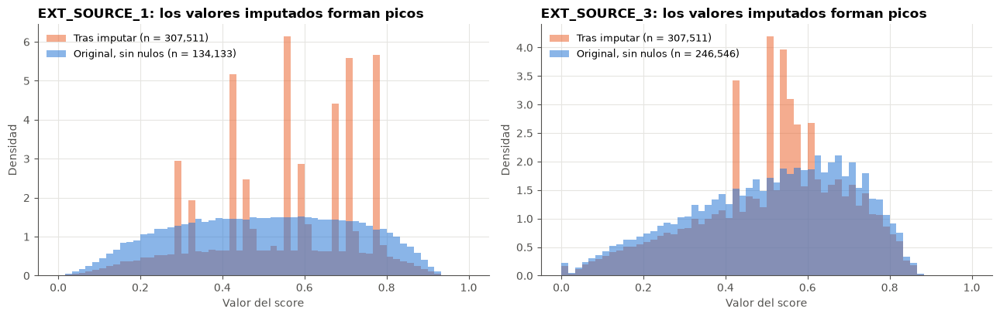

PosixPath('/home/claude/repo/artifacts/eda_figures/missings/05_antes_despues_ext_source.png')

In [23]:
IMPUTADAS_NUM = sorted(set((EXT if IMPUTAR_EXT else []) + MEDIANA_GLOBAL + MODA_NUMERICA + RAZON_MONTOS))
CAMBIAN_ESPERADAS = set(IMPUTADAS_NUM) | {"DAYS_EMPLOYED"} | set(MODA_CATEGORICA)
SIN_TOCAR = (FAMILIAS_NULOS["Buró"] + FAMILIAS_NULOS["Solicitudes previas"] + FAMILIAS_NULOS["POS Cash"] + FAMILIAS_NULOS["Cuotas"]
             + FAMILIAS_NULOS["Tarjeta de crédito"] + ["OWN_CAR_AGE", "OCCUPATION_TYPE"] + VIVIENDA + ([] if IMPUTAR_EXT else EXT))

verificaciones = []


def verificar(nombre, condicion):
    verificaciones.append({"verificación": nombre, "resultado": "✔" if bool(condicion) else "✖"})


verificar("Mismo número de filas", len(df_imp) == len(df))
verificar("SK_ID_CURR idéntico y único", df_imp[COL_ID].equals(df[COL_ID]) and df_imp[COL_ID].is_unique)
verificar("TARGET sin cambios", df_imp[COL_TARGET].equals(df[COL_TARGET]))
verificar("Variables imputadas sin nulos", int(df_imp[IMPUTADAS_NUM + ["NAME_TYPE_SUITE"]].isna().sum().sum()) == 0)
verificar("DAYS_EMPLOYED sin el centinela 365243", not (df_imp["DAYS_EMPLOYED"] == SENT).any())
verificar("Sin 'XNA' en CODE_GENDER ni 'Unknown' en NAME_FAMILY_STATUS", not (df_imp["CODE_GENDER"] == "XNA").any() and not (df_imp["NAME_FAMILY_STATUS"] == "Unknown").any())
for flag, col in FLAGS_ESTRUCTURALES.items():
    verificar(f"{flag} = nulos originales de {col}", int(df_imp[flag].sum()) == int(df[col].isna().sum()))
verificar("flag_sin_empleo = filas con centinela", int(df_imp["flag_sin_empleo"].sum()) == int((df["DAYS_EMPLOYED"] == SENT).sum()))
verificar("flag_sin_info_vivienda = filas con las 47 variables nulas", int(df_imp["flag_sin_info_vivienda"].sum()) == int(df[VIVIENDA].isna().all(axis=1).sum()))
verificar("Nulos intactos en estructurales, vivienda y OCCUPATION_TYPE", all(int(df_imp[c].isna().sum()) == int(df[c].isna().sum()) for c in SIN_TOCAR))
verificar("Valores no nulos originales intactos en las imputadas", all(
    (df_imp.loc[df[c].notna(), c] == df.loc[df[c].notna(), c]).all() for c in IMPUTADAS_NUM if c != "CNT_FAM_MEMBERS"))
cambiaron = {c for c in df.columns if not df[c].equals(df_imp[c])}
verificar("Solo cambiaron las columnas previstas", cambiaron == CAMBIAN_ESPERADAS)

VERIF = pd.DataFrame(verificaciones)
display(VERIF)
if cambiaron != CAMBIAN_ESPERADAS:
    print("Columnas cambiadas no previstas:", cambiaron - CAMBIAN_ESPERADAS, "| previstas que no cambiaron:", CAMBIAN_ESPERADAS - cambiaron)
assert (VERIF["resultado"] == "✔").all(), "Alguna verificación del tratamiento falló"
print("Todas las verificaciones pasaron.")

# Efecto del tratamiento sobre la distribución
idx = df.index
filas = []
for c in IMPUTADAS_NUM + ["DAYS_EMPLOYED"]:
    a, b = df.loc[idx, c], df_imp.loc[idx, c]
    filas.append({"variable": c, "n_imputados": int(a.isna().sum()) if c != "DAYS_EMPLOYED" else int((a == SENT).sum()),
                  "media_antes": a.where(a != SENT).mean() if c == "DAYS_EMPLOYED" else a.mean(), "media_despues": b.mean(),
                  "std_antes": a.where(a != SENT).std() if c == "DAYS_EMPLOYED" else a.std(), "std_despues": b.std()})
display(Markdown("**Efecto sobre media y desviación estándar** — imputar concentra valores y reduce la dispersión; en `DAYS_EMPLOYED` la comparación 'antes' excluye el centinela"))
mostrar(pd.DataFrame(filas).set_index("variable"), enteros=["n_imputados"])


def grafico_antes_despues():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    for ax, c in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_3"]):
        a, b = df.loc[idx, c].dropna(), df_imp.loc[idx, c]
        bins = np.linspace(0, 1, 61)
        ax.hist(b, bins=bins, density=True, color=C_TEORICA, alpha=0.55, label=f"Tras imputar (n = {len(b):,})")
        ax.hist(a, bins=bins, density=True, color=C_PRINCIPAL, alpha=0.55, label=f"Original, sin nulos (n = {len(a):,})")
        ax.set_title(f"{c}: los valores imputados forman picos"); ax.set_xlabel("Valor del score"); ax.set_ylabel("Densidad")
        ax.legend(loc="upper left")
    fig.tight_layout()
    return guardar_figura(fig, "missings", "05_antes_despues_ext_source")


grafico_antes_despues()

### Exportación
`artifacts/tablon_imputado.parquet` y `artifacts/parametros_imputacion.json`.

In [24]:
# TODO(Isaac): antes se exportaba en CSV (~190 MB); se cambió a parquet porque GitHub rechaza archivos > 100 MB.
RUTA_IMPUTADO = ARTIFACTS_DIR / "tablon_imputado.parquet"
RUTA_PARAMS = ARTIFACTS_DIR / "parametros_imputacion.json"

df_imp.to_parquet(RUTA_IMPUTADO, compression="zstd", index=False)
with open(RUTA_PARAMS, "w", encoding="utf-8") as f:
    json.dump(PARAMS, f, ensure_ascii=False, indent=2)

# Verificación de lo escrito: se relee y se compara con lo que se quería guardar
chequeo = pd.read_parquet(RUTA_IMPUTADO, columns=[COL_ID, COL_TARGET] + [c for c in COLUMNAS_NUEVAS if c.startswith("flag_")])
assert len(chequeo) == len(df_imp) and chequeo[COL_ID].is_unique
print(f"Guardado: {RUTA_IMPUTADO.name} — {df_imp.shape[0]:,} filas × {df_imp.shape[1]} columnas ({RUTA_IMPUTADO.stat().st_size / 1e6:,.0f} MB)")
print(f"Guardado: {RUTA_PARAMS.name}")

Guardado: tablon_imputado.parquet — 307,511 filas × 152 columnas (25 MB)
Guardado: parametros_imputacion.json


### 3.1) Numéricas

### Tratamiento de outliers
Partimos de `df_imp` (tras missings). Evidencia → plan → aplicación, validación y exportación. Criterio: se *topea* una cola solo si no aporta señal distinta a la del tramo previo.

In [25]:
# ── 9.0 Configuración de la sección ───────────────────────────────────────────────────────────────
import json

IMG_SUB.setdefault("outliers", IMG_DIR / "outliers")
IMG_SUB["outliers"].mkdir(parents=True, exist_ok=True)

GRUPOS_OUT = {
    "Ingreso y hogar": ["AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS"],
    "Círculo social y consultas": ["OBS_30_CNT_SOCIAL_CIRCLE", "OBS_60_CNT_SOCIAL_CIRCLE", "AMT_REQ_CREDIT_BUREAU_QRT"],
    "Auto": ["OWN_CAR_AGE"],
}
VARS_OUT = [v for grupo in GRUPOS_OUT.values() for v in grupo]
PCTS = [95, 99, 99.9]                    # percentiles candidatos para el tope
PCT_PREVIO = {95: 90, 99: 95, 99.9: 99}  # tramo contra el que se compara la cola

dfo = df_imp                             # tablón ya imputado (sección 8); todo el dataset es train
y_all = dfo[COL_TARGET]
TASA_BASE = y_all.mean()


def tope(s, p):
    # Valor del percentil p (0-100) sobre los no nulos; en variables enteras devuelve un valor observado.
    s = s.dropna()
    entera = bool((s % 1 == 0).all())
    return float(s.quantile(p / 100, interpolation="higher" if entera else "linear"))


display(Markdown(f"**{len(VARS_OUT)} variables a revisar** · tasa de default base: {TASA_BASE:.2%}"))

**7 variables a revisar** · tasa de default base: 8.07%

#### Dónde están las colas
Percentiles altos y default por tramo de cola (barras grises: menos de 300 casos, tasa poco fiable).

,mediana,p95,p99,p99.9,máximo,máx / p99.9
variable,,,,,,
AMT_INCOME_TOTAL,"147,150.000","337,500.000","472,500.000","900,000.000","117,000,000.000",130.000
CNT_CHILDREN,0.000,2.000,3.000,4.000,19.000,4.750
CNT_FAM_MEMBERS,2.000,4.000,5.000,6.000,20.000,3.333
OBS_30_CNT_SOCIAL_CIRCLE,0.000,6.000,10.000,17.000,348.000,20.471
OBS_60_CNT_SOCIAL_CIRCLE,0.000,6.000,10.000,16.000,344.000,21.500
AMT_REQ_CREDIT_BUREAU_QRT,0.000,2.000,2.000,4.000,261.000,65.250
OWN_CAR_AGE,9.000,30.000,64.000,65.000,91.000,1.400


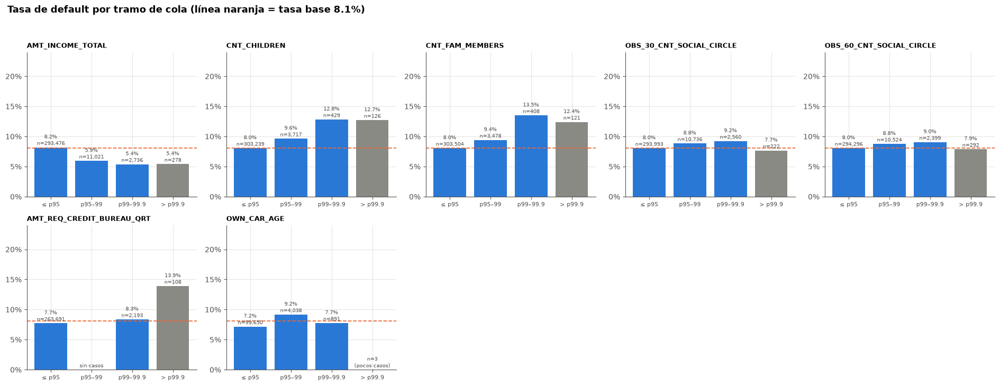

PosixPath('/home/claude/repo/artifacts/eda_figures/outliers/01_default_por_tramo_de_cola.png')

In [26]:
filas = []
for v in VARS_OUT:
    s = dfo[v].dropna()
    t = {p: tope(s, p) for p in PCTS}
    filas.append({"variable": v, "mediana": s.median(), "p95": t[95], "p99": t[99], "p99.9": t[99.9],
                  "máximo": s.max(), "máx / p99.9": s.max() / t[99.9] if t[99.9] > 0 else np.nan})
COLAS = pd.DataFrame(filas).set_index("variable")
display(COLAS)


def grafico_default_por_cola():
    fig, axes = plt.subplots(2, 5, figsize=(19, 7.4))
    etiquetas = ["≤ p95", "p95–99", "p99–99.9", "> p99.9"]
    for ax, v in zip(axes.ravel(), VARS_OUT):
        s = dfo[v].dropna(); y = y_all[s.index]
        t = [tope(s, p) for p in PCTS]
        masks = [s <= t[0], (s > t[0]) & (s <= t[1]), (s > t[1]) & (s <= t[2]), s > t[2]]
        ns = [int(m.sum()) for m in masks]
        tasas = [y[m].mean() if n >= 20 else np.nan for m, n in zip(masks, ns)]
        ax.bar(range(4), [0 if np.isnan(r) else r for r in tasas], color=[C_PRINCIPAL if n >= 300 else C_REF for n in ns])
        ax.axhline(TASA_BASE, color=C_TEORICA, lw=1.3, ls="--")
        for i, (r, n) in enumerate(zip(tasas, ns)):
            ax.text(i, (0 if np.isnan(r) else r) + 0.004, ("sin casos" if n == 0 else f"n={n:,}\n(pocos casos)") if np.isnan(r) else f"{r:.1%}\nn={n:,}",
                    ha="center", fontsize=7.5, color=C_TEXTO2, clip_on=True)
        ax.set_xticks(range(4)); ax.set_xticklabels(etiquetas, fontsize=8)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_ylim(0, 0.24)
        ax.set_title(v, fontsize=9.5)
    for ax in axes.ravel()[len(VARS_OUT):]:          # cuadrícula 2×5: oculta ejes sin variable
        ax.set_visible(False)
    fig.suptitle(f"Tasa de default por tramo de cola (línea naranja = tasa base {TASA_BASE:.1%})", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return guardar_figura(fig, "outliers", "01_default_por_tramo_de_cola")


grafico_default_por_cola()

#### ¿Qué percentil de tope pierde menos señal?
Por variable y percentil: casos afectados, default de la cola vs. tramo previo (test χ²; p ≥ 0.05 = cola homogénea, el tope no pierde señal), y cambio de log-verosimilitud (`delta_logL`) y de AUC (`delta_AUC`) de una logística univariada.

tope n_afectados pct_de_no_nulos default_tramo_previo default_cola p_valor  delta_logL delta_AUC
variable                  percentil                                                                                                        
AMT_INCOME_TOTAL          95.000    337,500.000      14,035           4.56%                6.48%        5.81%  0.0231      57.044   -0.0000
                          99.000    472,500.000       3,014           0.98%                5.93%        5.37%   0.263      64.247   -0.0000
                          99.900    900,000.000         278           0.09%                5.37%        5.40%       1      64.567   +0.0000
CNT_CHILDREN              95.000          2.000       4,272           1.39%                            10.04%              -2.690   -0.0001
                          99.000          3.000         555           0.18%                9.63%       12.79%  0.0254      -1.225   -0.0000
                          99.900          4.000         126           0.04%               12.82%       12.70%       1      -0.022   -0.0000
CNT_FAM_MEMBERS           95.000          4.000       4,007           1.30%                8.65%        9.91%    0.01      -2.844   -0.0001
                          99.000          5.000         529           0.17%                9.40%       13.23%  0.0076      -1.149   -0.0000
                          99.900          6.000         121           0.04%               13.48%       12.40%   0.876      -0.339   +0.0000
OBS_30_CNT_SOCIAL_CIRCLE  95.000          6.000      13,518           4.40%                8.51%        8.88%   0.263       4.944   +0.0000
                          99.000         10.000       2,782           0.90%                8.83%        9.09%    0.69       3.971   +0.0000
                          99.900         17.000         222           0.07%                9.22%        7.66%   0.513       2.713   -0.0000
OBS_60_CNT_SOCIAL_CIRCLE  95.000          6.000      13,215           4.30%                8.62%        8.79%   0.633       5.142   +0.0000
                          99.000         10.000       2,691           0.88%                8.75%        8.92%   0.814       3.980   +0.0000
                          99.900         16.000         292           0.09%                9.05%        7.88%    0.58       2.794   -0.0000
AMT_REQ_CREDIT_BUREAU_QRT 95.000          2.000       2,301           0.87%                8.35%        8.60%   0.709       1.610   +0.0000
                          99.000          2.000       2,301           0.87%                             8.60%               1.610   +0.0000
                          99.900          4.000         108           0.04%                8.34%       13.89%  0.0673       0.304   +0.0000
OWN_CAR_AGE               95.000         30.000       4,932           4.72%                9.41%        8.92%    0.41      60.174   +0.0000
                          99.000         64.000         894           0.85%                9.16%        7.83%    0.23       0.183   +0.0000
                          99.900         65.000           3           0.00%                7.74%       33.33%              -0.194   -0.0000

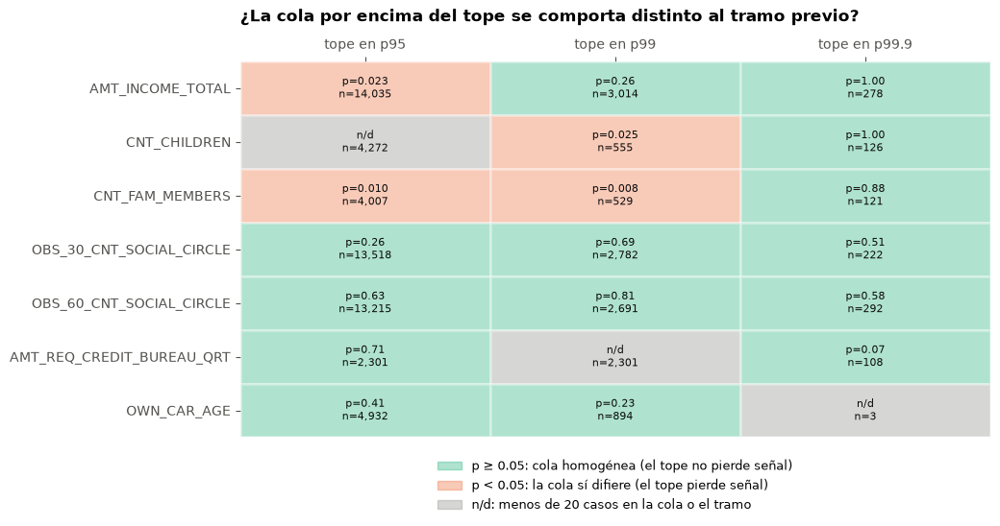

PosixPath('/home/claude/repo/artifacts/eda_figures/outliers/02_homogeneidad_de_la_cola.png')

In [27]:
def _logit_ll(x, y, it=30):
    # Log-verosimilitud de una regresión logística univariada (x estandarizada), por IRLS.
    x = (x - x.mean()) / x.std()
    Xd = np.c_[np.ones(len(x)), x]; b = np.zeros(2)
    for _ in range(it):
        p = 1 / (1 + np.exp(-(Xd @ b))); w = p * (1 - p) + 1e-12
        b = b + np.linalg.solve((Xd * w[:, None]).T @ Xd, Xd.T @ (y - p))
    p = np.clip(1 / (1 + np.exp(-(Xd @ b))), 1e-12, 1 - 1e-12)
    return float((y * np.log(p) + (1 - y) * np.log(1 - p)).sum())


def _auc(x, y):
    r = stats.rankdata(x); n1 = y.sum(); n0 = len(y) - n1
    a = (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)
    return max(a, 1 - a)


filas = []
for v in VARS_OUT:
    s = dfo[v].dropna(); x = s.values.astype(float); y = y_all[s.index].values.astype(float)
    ll0, auc0 = _logit_ll(x, y), _auc(x, y)
    for p in PCTS:
        cap, previo = tope(s, p), tope(s, PCT_PREVIO[p])
        cola, tramo = y[x > cap], y[(x > previo) & (x <= cap)]
        p_val = np.nan
        if len(cola) >= 20 and len(tramo) >= 20:
            try:
                p_val = stats.chi2_contingency([[tramo.sum(), len(tramo) - tramo.sum()], [cola.sum(), len(cola) - cola.sum()]])[1]
            except ValueError:
                pass
        xc = np.minimum(x, cap)
        filas.append({"variable": v, "percentil": p, "tope": cap, "n_afectados": len(cola), "pct_de_no_nulos": len(cola) / len(x),
                      "default_tramo_previo": tramo.mean() if len(tramo) else np.nan, "default_cola": cola.mean() if len(cola) else np.nan,
                      "p_valor": p_val, "delta_logL": _logit_ll(xc, y) - ll0, "delta_AUC": _auc(xc, y) - auc0})
EVID = pd.DataFrame(filas)

vista = EVID.copy()
vista["p_valor"] = vista["p_valor"].map(lambda v: "" if pd.isna(v) else f"{v:.3g}")
vista["delta_AUC"] = vista["delta_AUC"].map(lambda v: f"{v:+.4f}")
mostrar(vista.set_index(["variable", "percentil"]), pct=["pct_de_no_nulos", "default_tramo_previo", "default_cola"], enteros=["n_afectados"])


def grafico_homogeneidad():
    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    for i, v in enumerate(VARS_OUT):
        for j, p in enumerate(PCTS):
            r = EVID[(EVID["variable"] == v) & (EVID["percentil"] == p)].iloc[0]
            if np.isnan(r["p_valor"]):
                color, txt = C_REF, f"n/d\nn={r['n_afectados']:,}"
            elif r["p_valor"] >= 0.05:
                color, txt = C_TERCERO, f"p={r['p_valor']:.2f}\nn={r['n_afectados']:,}"
            else:
                color, txt = C_TEORICA, f"p={r['p_valor']:.3f}\nn={r['n_afectados']:,}"
            ax.add_patch(Rectangle((j, -i - 1), 1, 1, facecolor=color, alpha=0.35, edgecolor="white", lw=2))
            ax.text(j + 0.5, -i - 0.5, txt, ha="center", va="center", fontsize=8, color=C_TEXTO)
    ax.set_xlim(0, len(PCTS)); ax.set_ylim(-len(VARS_OUT), 0)
    ax.set_xticks([j + 0.5 for j in range(len(PCTS))]); ax.set_xticklabels([f"tope en p{p}" for p in PCTS])
    ax.set_yticks([-i - 0.5 for i in range(len(VARS_OUT))]); ax.set_yticklabels(VARS_OUT)
    ax.xaxis.tick_top(); ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title("¿La cola por encima del tope se comporta distinto al tramo previo?", pad=30)
    ax.legend(handles=[Patch(color=C_TERCERO, alpha=0.35, label="p ≥ 0.05: cola homogénea (el tope no pierde señal)"),
                       Patch(color=C_TEORICA, alpha=0.35, label="p < 0.05: la cola sí difiere (el tope pierde señal)"),
                       Patch(color=C_REF, alpha=0.35, label="n/d: menos de 20 casos en la cola o el tramo")],
              loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=1)
    fig.tight_layout()
    return guardar_figura(fig, "outliers", "02_homogeneidad_de_la_cola")


grafico_homogeneidad()

#### Casos especiales
`OWN_CAR_AGE`: bloque anómalo en 64–65 años.

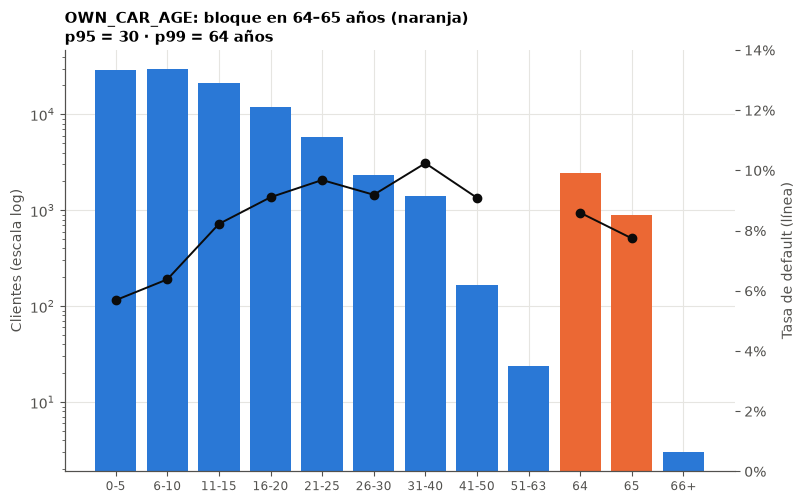

PosixPath('/home/claude/repo/artifacts/eda_figures/outliers/03_casos_especiales.png')

In [28]:
def barras_default(ax, serie, bordes, etiquetas, titulo):
    s = serie.dropna(); y = y_all[s.index]
    g = y.groupby(pd.cut(s, bordes, labels=etiquetas, include_lowest=True), observed=False).agg(["mean", "size"])
    ax.bar(range(len(g)), g["mean"].fillna(0), color=[C_PRINCIPAL if n >= 300 else C_REF for n in g["size"]])
    ax.axhline(TASA_BASE, color=C_TEORICA, lw=1.3, ls="--")
    for i, (r, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, (0 if pd.isna(r) else r) + 0.003, f"{r:.1%}\nn={n:,}", ha="center", fontsize=7.5, color=C_TEXTO2,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1))
    ax.set_xticks(range(len(g))); ax.set_xticklabels(etiquetas, fontsize=8.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_ylim(0, max(0.16, float(g["mean"].max()) + 0.05))
    ax.set_ylabel("Tasa de default"); ax.set_title(titulo, fontsize=10.5)


def grafico_casos_especiales():
    fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))
    ax1, ax2, ax3, ax4 = axes.ravel()

    # (a) OWN_CAR_AGE: frecuencia (escala log) y default por rango de edad del auto
    s = dfo["OWN_CAR_AGE"].dropna(); y = y_all[s.index]
    tramos = [(0, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30), (31, 40), (41, 50), (51, 63), (64, 64), (65, 65), (66, 200)]
    etq = ["0-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-40", "41-50", "51-63", "64", "65", "66+"]
    ms = [(s >= a) & (s <= b) for a, b in tramos]
    ax1.bar(range(len(etq)), [int(m.sum()) for m in ms], color=[C_TEORICA if e in ("64", "65") else C_PRINCIPAL for e in etq])
    ax1.set_yscale("log"); ax1.set_ylabel("Clientes (escala log)"); ax1.set_xticks(range(len(etq))); ax1.set_xticklabels(etq, fontsize=8.5)
    ax1b = ax1.twinx(); ax1b.plot(range(len(etq)), [y[m].mean() if m.sum() >= 100 else np.nan for m in ms], color=C_TEXTO, marker="o", lw=1.4)
    ax1b.set_ylim(0, 0.14); ax1b.grid(False); ax1b.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax1b.set_ylabel("Tasa de default (línea)")
    ax1.set_title(f"OWN_CAR_AGE: bloque en 64–65 años (naranja)\np95 = {tope(s, 95):.0f} · p99 = {tope(s, 99):.0f} años", fontsize=10.5)

    for ax in (ax2, ax3, ax4):
        ax.set_visible(False)

    fig.tight_layout()
    return guardar_figura(fig, "outliers", "03_casos_especiales")


grafico_casos_especiales()

#### Plan de tratamiento
Solo tope superior (winsorización) con percentil elegido por variable; el resto de variables numéricas no se toca (colas reales o falsos outliers por ceros/acotación).

In [29]:
CAPS = {   # variable: percentil del tope superior
    "AMT_INCOME_TOTAL": 99.9, "CNT_CHILDREN": 99.9, "CNT_FAM_MEMBERS": 99.9,
    "OBS_30_CNT_SOCIAL_CIRCLE": 99.9, "OBS_60_CNT_SOCIAL_CIRCLE": 99.9, "AMT_REQ_CREDIT_BUREAU_QRT": 99.9,
    "OWN_CAR_AGE": 95,
}
CRITERIO = {
    "AMT_INCOME_TOTAL": "Neutraliza el máximo (117 M); mantiene a los ingresos altos, cuya cola tiene menor default",
    "CNT_CHILDREN": "En p99 la cola difiere del tramo previo (pierde señal); en p99.9 no",
    "CNT_FAM_MEMBERS": "En p99 la cola difiere del tramo previo (pierde señal); en p99.9 no",
    "OBS_30_CNT_SOCIAL_CIRCLE": "Cola homogénea; neutraliza el valor 348 (el siguiente es 47)",
    "OBS_60_CNT_SOCIAL_CIRCLE": "Cola homogénea; neutraliza el valor 344 (el siguiente es 47)",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Neutraliza el valor 261 (el siguiente es 19)",
    "OWN_CAR_AGE": "p99 = 64 no corrige el bloque 64–65; p95 = 30 con cola homogénea",
}
PLAN_OUT = pd.DataFrame({
    "percentil": pd.Series(CAPS),
    "tope": pd.Series({v: tope(dfo[v], p) for v, p in CAPS.items()}),
    "n_afectados": pd.Series({v: int((dfo[v] > tope(dfo[v], p)).sum()) for v, p in CAPS.items()}),
    "criterio": pd.Series(CRITERIO),
})
PLAN_OUT["pct_del_total"] = PLAN_OUT["n_afectados"] / len(dfo)
with pd.option_context("display.max_colwidth", 120):
    mostrar(PLAN_OUT[["percentil", "tope", "n_afectados", "pct_del_total", "criterio"]], pct=["pct_del_total"], enteros=["n_afectados"])

,percentil,tope,n_afectados,pct_del_total,criterio
AMT_INCOME_TOTAL,99.900,"900,000.000",278,0.09%,"Neutraliza el máximo (117 M); mantiene a los ingresos altos, cuya cola tiene menor default"
CNT_CHILDREN,99.900,4.000,126,0.04%,En p99 la cola difiere del tramo previo (pierde señal); en p99.9 no
CNT_FAM_MEMBERS,99.900,6.000,121,0.04%,En p99 la cola difiere del tramo previo (pierde señal); en p99.9 no
OBS_30_CNT_SOCIAL_CIRCLE,99.900,17.000,222,0.07%,Cola homogénea; neutraliza el valor 348 (el siguiente es 47)
OBS_60_CNT_SOCIAL_CIRCLE,99.900,16.000,292,0.09%,Cola homogénea; neutraliza el valor 344 (el siguiente es 47)
AMT_REQ_CREDIT_BUREAU_QRT,99.900,4.000,108,0.04%,Neutraliza el valor 261 (el siguiente es 19)
OWN_CAR_AGE,95.000,30.000,"4,932",1.60%,p99 = 64 no corrige el bloque 64–65; p95 = 30 con cola homogénea


#### Implementación
`ajustar_topes` aprende los topes (percentiles del dataset) y `aplicar_topes` los aplica; los nulos no se tocan.

In [30]:
def ajustar_topes(d, caps):
    return {v: tope(d[v], p) for v, p in caps.items()}


def aplicar_topes(d, topes):
    out = d.copy()
    for v, t in topes.items():
        capeada = out[v].clip(upper=t)
        if pd.api.types.is_integer_dtype(d[v]) and float(t).is_integer():
            capeada = capeada.astype(d[v].dtype)
        out[v] = capeada
    return out


TOPES = ajustar_topes(dfo, CAPS)
df_out = aplicar_topes(dfo, TOPES)
print(f"Topes aplicados a {len(TOPES)} variables sobre {len(df_out):,} filas.")

Topes aplicados a 7 variables sobre 307,511 filas.


#### Validación y efecto del tratamiento

,verificación,resultado
0,Misma forma y mismas columnas,✔
1,SK_ID_CURR y TARGET sin cambios,✔
2,Solo cambiaron las variables previstas,✔
3,Ningún valor supera su tope,✔
4,El tope se alcanza (máximo = tope),✔
5,Nulos intactos,✔
6,Valores ≤ tope intactos,✔
7,N.º de valores modificados = n.º por encima de...,✔
8,Flags intactos,✔
9,Coherencia miembros ≥ hijos + 1 no empeora,✔


Todas las verificaciones pasaron.


,tope,n_modificados,máx_antes,máx_después,media_antes,media_después,std_antes,std_después,asim_antes,asim_después
AMT_INCOME_TOTAL,"900,000.000",278,"117,000,000.000","900,000.000","168,797.919","167,771.351","237,123.146","91,928.893",391.560,2.359
CNT_CHILDREN,4.000,126,19.000,4.000,0.417,0.416,0.722,0.715,1.975,1.714
CNT_FAM_MEMBERS,6.000,121,20.000,6.000,2.153,2.152,0.911,0.905,0.988,0.852
OBS_30_CNT_SOCIAL_CIRCLE,17.000,222,348.000,17.000,1.418,1.414,2.398,2.293,12.144,2.419
OBS_60_CNT_SOCIAL_CIRCLE,16.000,292,344.000,16.000,1.401,1.396,2.377,2.267,12.075,2.397
AMT_REQ_CREDIT_BUREAU_QRT,4.000,108,261.000,4.000,0.265,0.264,0.794,0.606,134.366,2.540
OWN_CAR_AGE,30.000,"4,932",91.000,30.000,12.061,10.882,11.945,7.791,2.745,0.842


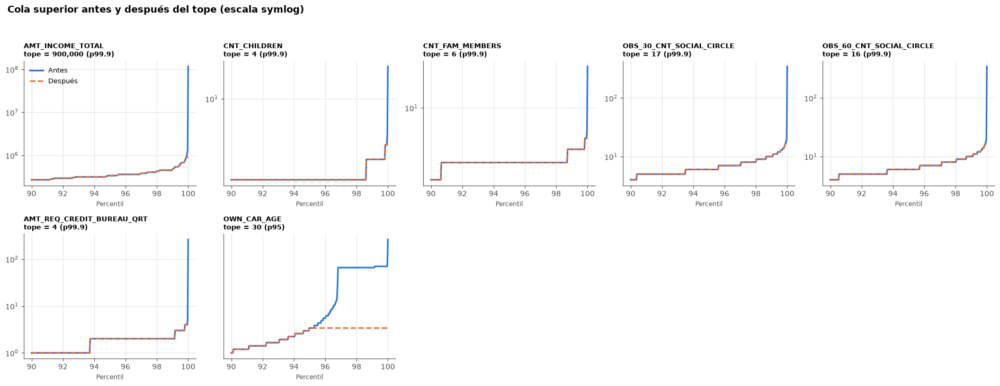

PosixPath('/home/claude/repo/artifacts/eda_figures/outliers/04_antes_despues_topes.png')

In [31]:
verif_out = []


def verificar_out(nombre, condicion):
    verif_out.append({"verificación": nombre, "resultado": "✔" if bool(condicion) else "✖"})


modificadas = {v: int((dfo[v] > TOPES[v]).sum()) for v in VARS_OUT}
cambiaron = {c for c in dfo.columns if not dfo[c].equals(df_out[c])}
verificar_out("Misma forma y mismas columnas", df_out.shape == dfo.shape and list(df_out.columns) == list(dfo.columns))
verificar_out("SK_ID_CURR y TARGET sin cambios", df_out[COL_ID].equals(dfo[COL_ID]) and df_out[COL_TARGET].equals(dfo[COL_TARGET]))
verificar_out("Solo cambiaron las variables previstas", cambiaron == set(VARS_OUT))
verificar_out("Ningún valor supera su tope", all(df_out[v].max() <= TOPES[v] for v in VARS_OUT))
verificar_out("El tope se alcanza (máximo = tope)", all(df_out[v].max() == TOPES[v] for v in VARS_OUT))
verificar_out("Nulos intactos", all(df_out[v].isna().equals(dfo[v].isna()) for v in VARS_OUT))
verificar_out("Valores ≤ tope intactos", all(df_out.loc[dfo[v] <= TOPES[v], v].equals(dfo.loc[dfo[v] <= TOPES[v], v]) for v in VARS_OUT))
verificar_out("N.º de valores modificados = n.º por encima del tope", all(int(((df_out[v] != dfo[v]) & dfo[v].notna()).sum()) == modificadas[v] for v in VARS_OUT))
verificar_out("Flags intactos", all(df_out[c].equals(dfo[c]) for c in dfo.columns if c.startswith("flag_")))
verificar_out("Coherencia miembros ≥ hijos + 1 no empeora",
              int((df_out["CNT_FAM_MEMBERS"] < df_out["CNT_CHILDREN"] + 1).sum()) <= int((dfo["CNT_FAM_MEMBERS"] < dfo["CNT_CHILDREN"] + 1).sum()))

VERIF_OUT = pd.DataFrame(verif_out)
display(VERIF_OUT)
assert (VERIF_OUT["resultado"] == "✔").all(), "Alguna verificación del tratamiento de outliers falló"
print("Todas las verificaciones pasaron.")

efecto = pd.DataFrame({
    "tope": pd.Series(TOPES), "n_modificados": pd.Series(modificadas),
    "máx_antes": dfo[VARS_OUT].max(), "máx_después": df_out[VARS_OUT].max(),
    "media_antes": dfo[VARS_OUT].mean(), "media_después": df_out[VARS_OUT].mean(),
    "std_antes": dfo[VARS_OUT].std(), "std_después": df_out[VARS_OUT].std(),
    "asim_antes": dfo[VARS_OUT].skew(), "asim_después": df_out[VARS_OUT].skew(),
}).loc[VARS_OUT]
mostrar(efecto, enteros=["n_modificados"])


def grafico_antes_despues_topes():
    fig, axes = plt.subplots(2, 5, figsize=(19, 7.4))
    q = np.linspace(0.90, 1.0, 300)
    for ax, v in zip(axes.ravel(), VARS_OUT):
        a, b = dfo[v].dropna(), df_out[v].dropna()
        ax.plot(q * 100, a.quantile(q).values, color=C_PRINCIPAL, lw=2.2, label="Antes")
        ax.plot(q * 100, b.quantile(q).values, color=C_TEORICA, lw=2, ls="--", label="Después")
        ax.set_yscale("symlog", linthresh=max(1.0, abs(float(a.quantile(0.9)))))
        ax.set_title(f"{v}\ntope = {TOPES[v]:,.0f} (p{CAPS[v]:g})" if TOPES[v] >= 100 else f"{v}\ntope = {TOPES[v]:.4g} (p{CAPS[v]:g})", fontsize=9)
        ax.set_xlabel("Percentil", fontsize=8.5)
    for ax in axes.ravel()[len(VARS_OUT):]:          # cuadrícula 2×5: oculta ejes sin variable
        ax.set_visible(False)
    axes.ravel()[0].legend(loc="upper left")
    fig.suptitle("Cola superior antes y después del tope (escala symlog)", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return guardar_figura(fig, "outliers", "04_antes_despues_topes")


grafico_antes_despues_topes()

#### Exportación
`artifacts/tablon_tratado.parquet` (imputado + topes) y `artifacts/parametros_outliers.json`. **Siguiente etapa:** bivariado sobre `tablon_tratado.parquet`.

In [32]:
# TODO(Isaac): antes CSV (~190 MB); parquet por el límite de 100 MB de GitHub.
RUTA_TRATADO = ARTIFACTS_DIR / "tablon_tratado.parquet"
RUTA_TOPES = ARTIFACTS_DIR / "parametros_outliers.json"

df_out.to_parquet(RUTA_TRATADO, compression="zstd", index=False)
with open(RUTA_TOPES, "w", encoding="utf-8") as f:
    json.dump({"percentiles": CAPS, "topes": TOPES}, f, ensure_ascii=False, indent=2)

# Verificación de lo escrito: se relee y se compara
chequeo = pd.read_parquet(RUTA_TRATADO, columns=[COL_ID, COL_TARGET] + VARS_OUT)
assert len(chequeo) == len(df_out) and chequeo[COL_ID].is_unique
assert all(chequeo[v].max() <= TOPES[v] * (1 + 1e-9) for v in VARS_OUT)
print(f"Guardado: {RUTA_TRATADO.name} — {df_out.shape[0]:,} filas × {df_out.shape[1]} columnas ({RUTA_TRATADO.stat().st_size / 1e6:,.0f} MB)")
print(f"Guardado: {RUTA_TOPES.name}")

Guardado: tablon_tratado.parquet — 307,511 filas × 152 columnas (25 MB)
Guardado: parametros_outliers.json


### 3.2) Categóricas
Las imputaciones categóricas (`NAME_TYPE_SUITE` nulo, `CODE_GENDER = 'XNA'`, `NAME_FAMILY_STATUS = 'Unknown'` → moda) se aplican dentro de `aplicar_tratamiento` (arriba). `ORGANIZATION_TYPE = 'XNA'` se conserva como categoría y `OCCUPATION_TYPE` sigue sin imputar (pendiente en tu plan).

## Paso 4) Análisis Exploratorio (EDA univariado) y Visualización
Los gráficos se generan sobre `df` (tablón oficial **sin** tratar): EDA univariado *ex-ante* (guía, Paso 4, precisión a).

### 4A) Numéricas: descriptivo y visualización

#### Ajuste de distribuciones teóricas
Máxima verosimilitud sobre `N_MUESTRA_AJUSTE` observaciones. Continuas: normal, logística, skew-normal, lognormal, gamma, Weibull, exponencial y beta; conteos: Poisson y binomial negativa. Se elige por **AIC** y se reporta el **D de Kolmogorov–Smirnov** (tamaño del desajuste; con 300 mil filas un p-value siempre rechazaría).

In [33]:
FAMILIAS_CONTINUAS = {
    "normal": stats.norm, "logística": stats.logistic, "skew-normal": stats.skewnorm,
    "lognormal": stats.lognorm, "gamma": stats.gamma, "weibull": stats.weibull_min,
    "exponencial": stats.expon, "beta": stats.beta,
}
FAMILIAS_CON_COTA = {"lognormal", "gamma", "weibull", "exponencial"}
FAMILIAS_CONTEO = {"poisson": stats.poisson, "binomial negativa": stats.nbinom}


def ajustar_continua(x):
    xmin, xmax = x.min(), x.max()
    loc0 = xmin - 1e-3 * (xmax - xmin)          # cota inferior justo debajo del mínimo observado
    filas, params_por_dist = [], {}
    for nombre, dist in FAMILIAS_CONTINUAS.items():
        try:
            xx = x
            if nombre in FAMILIAS_CON_COTA:
                p = dist.fit(x, floc=loc0)
            elif nombre == "beta":
                if xmin < 0 or xmax > 1:
                    continue
                xx = np.clip(x, 1e-6, 1 - 1e-6)
                p = dist.fit(xx, floc=0, fscale=1)
            else:
                p = dist.fit(x)
            logl = float(np.sum(dist.logpdf(xx, *p)))
            if not np.isfinite(logl):
                continue
            d_ks = float(stats.kstest(xx, dist.cdf, args=p).statistic)
            filas.append({"distribución": nombre, "k": len(p), "logL": logl, "AIC": 2 * len(p) - 2 * logl, "D_KS": d_ks})
            params_por_dist[nombre] = p
        except Exception:
            continue
    tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
    tabla["ΔAIC"] = tabla["AIC"] - tabla["AIC"].min()
    return tabla, params_por_dist


def ajustar_conteo(x):
    x = x.astype(int)
    n, m, v = len(x), x.mean(), x.var(ddof=1)
    soporte = np.arange(0, x.max() + 1)
    ecdf = np.searchsorted(np.sort(x), soporte, side="right") / n
    filas, params_por_dist = [], {}
    candidatas = {"poisson": (m,)}
    if v > m > 0:                                # sobredispersión -> binomial negativa por momentos
        r = m ** 2 / (v - m)
        candidatas["binomial negativa"] = (r, r / (r + m))
    for nombre, p in candidatas.items():
        dist = FAMILIAS_CONTEO[nombre]
        logl = float(np.sum(dist.logpmf(x, *p)))
        if not np.isfinite(logl):
            continue
        d_ks = float(np.max(np.abs(ecdf - dist.cdf(soporte, *p))))
        filas.append({"distribución": nombre, "k": len(p), "logL": logl, "AIC": 2 * len(p) - 2 * logl, "D_KS": d_ks})
        params_por_dist[nombre] = p
    tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
    tabla["ΔAIC"] = tabla["AIC"] - tabla["AIC"].min()
    return tabla, params_por_dist


import time
rng = np.random.default_rng(SEMILLA)
AJUSTES = {}
t0 = time.time()
for i, col in enumerate(NUMERICAS, 1):
    x = df[col].dropna().to_numpy(dtype=float)
    sent = METRICAS.loc[col, "centinela"]
    if not np.isnan(sent):
        x = x[x != sent]
    x_fit = rng.choice(x, size=min(len(x), N_MUESTRA_AJUSTE), replace=False)
    if METRICAS.loc[col, "es_conteo"]:
        tabla, params = ajustar_conteo(x_fit)
        tipo_ajuste = "conteo"
    else:
        tabla, params = ajustar_continua(x_fit)
        tipo_ajuste = "continua"
    AJUSTES[col] = {"tipo": tipo_ajuste, "tabla": tabla, "params": params}
    if i % 20 == 0 or i == len(NUMERICAS):
        print(f"  ajustadas {i}/{len(NUMERICAS)} variables ({time.time() - t0:,.0f} s)")

  ajustadas 20/93 variables (7 s)


  ajustadas 40/93 variables (30 s)


  ajustadas 60/93 variables (51 s)


  ajustadas 80/93 variables (63 s)


  ajustadas 93/93 variables (90 s)


In [34]:
def _d_normal(a):
    t = a["tabla"]
    fila = t.loc[t["distribución"] == "normal", "D_KS"]
    return fila.iloc[0] if len(fila) else np.nan


RESUMEN_AJUSTE = pd.DataFrame([{
    "variable": c, "tipo_ajuste": a["tipo"], "mejor_distribución": a["tabla"].loc[0, "distribución"],
    "AIC": a["tabla"].loc[0, "AIC"], "D_KS_mejor": a["tabla"].loc[0, "D_KS"], "D_KS_normal": _d_normal(a),
    "asimetria": METRICAS.loc[c, "asimetria"], "curtosis": METRICAS.loc[c, "curtosis"],
} for c, a in AJUSTES.items()]).set_index("variable")

display(RESUMEN_AJUSTE["mejor_distribución"].value_counts().rename("n_variables").to_frame())
display(RESUMEN_AJUSTE)

,n_variables
mejor_distribución,
beta,22
binomial negativa,20
gamma,20
skew-normal,14
lognormal,9
logística,6
poisson,2


,tipo_ajuste,mejor_distribución,AIC,D_KS_mejor,D_KS_normal,asimetria,curtosis
variable,,,,,,,
CNT_CHILDREN,conteo,binomial negativa,"34,734.369",0.022,NaN,1.975,7.904
AMT_INCOME_TOTAL,continua,lognormal,"504,740.473",0.063,0.231,391.560,"191,786.554"
AMT_CREDIT,continua,gamma,"565,378.304",0.049,0.107,1.235,1.934
AMT_ANNUITY,continua,gamma,"434,954.546",0.026,0.078,1.580,7.707
AMT_GOODS_PRICE,continua,gamma,"561,678.766",0.068,0.145,1.349,2.432
REGION_POPULATION_RELATIVE,continua,gamma,"-121,728.128",0.107,0.111,1.488,3.260
DAYS_BIRTH,continua,skew-normal,"391,985.926",0.067,0.050,-0.116,-1.049
DAYS_EMPLOYED,continua,skew-normal,"353,854.215",0.134,0.159,1.664,0.772
DAYS_REGISTRATION,continua,skew-normal,"377,582.008",0.044,0.079,-0.591,-0.321


#### Histograma, boxplot y Q-Q por variable
Histograma con la mejor distribución teórica (naranja) y la normal (gris), boxplot y Q-Q. Las variables de cola pesada añaden una vista log1p. Rango visible: p0.5–p99.5 (las métricas usan todos los datos).

In [35]:
DIST_TODAS = {**FAMILIAS_CONTINUAS, **FAMILIAS_CONTEO}
_fmt_eje = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}" if abs(v) >= 1000 else f"{v:g}")
_fmt_dens = mtick.FuncFormatter(lambda v, _: "0" if v == 0 else f"{v:.2g}")


def graficar_numerica(col):
    m, aj = METRICAS.loc[col], AJUSTES[col]
    x_all = df[col].dropna().to_numpy(dtype=float)
    sent = m["centinela"]
    x = x_all if np.isnan(sent) else x_all[x_all != sent]
    if len(x) == 0 or x.min() == x.max():
        print(f"{col}: sin variabilidad, no se grafica")
        return None

    es_conteo = aj["tipo"] == "conteo"
    lo, hi = np.percentile(x, [0.5, 99.5])
    if lo == hi:
        lo, hi = x.min(), x.max()
    visibles = x[(x >= lo) & (x <= hi)]
    if es_conteo:
        edges = np.arange(np.floor(lo) - 0.5, np.ceil(hi) + 1.5, 1.0)
    else:
        n_bins = int(np.clip(len(np.histogram_bin_edges(visibles, bins="fd")) - 1, 25, 80))
        edges = np.linspace(lo, hi, n_bins + 1)
    conteos, _ = np.histogram(visibles, bins=edges)
    ancho = np.diff(edges)
    dens = conteos / (len(x) * ancho)              # densidad respecto del total (no solo de lo visible)

    fig = plt.figure(figsize=(13, 5.4))
    gs = GridSpec(2, 2, figure=fig, width_ratios=[2.3, 1], height_ratios=[4, 1], hspace=0.06, wspace=0.25)
    ax_h = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[1, 0], sharex=ax_h)
    ax_q = fig.add_subplot(gs[:, 1])

    # ── Histograma + teóricas ────────────────────────────────────────────────
    ax_h.bar(edges[:-1], dens, width=ancho, align="edge", color=C_PRINCIPAL, alpha=0.55, edgecolor="white", linewidth=0.4, label="Datos")
    media, mediana = x.mean(), np.median(x)
    ax_h.axvline(media, color=C_TEXTO, lw=1.3, label=f"Media = {media:,.2f}")
    ax_h.axvline(mediana, color=C_TEXTO, lw=1.3, ls=":", label=f"Mediana = {mediana:,.2f}")

    tabla, params = aj["tabla"], aj["params"]
    mejor = tabla.loc[0, "distribución"]
    d_mejor = tabla.loc[0, "D_KS"]
    if es_conteo:
        ks = np.arange(int(np.floor(lo)), int(np.ceil(hi)) + 1)
        for j, fila in tabla.iterrows():
            nom = fila["distribución"]
            es_mejor = j == 0
            ax_h.plot(ks, FAMILIAS_CONTEO[nom].pmf(ks, *params[nom]), "o-" if es_mejor else "o--", ms=4,
                      color=C_TEORICA if es_mejor else C_REF, lw=1.8 if es_mejor else 1.2,
                      label=f"{nom}{' (mejor AIC)' if es_mejor else ''} · D={fila['D_KS']:.3f}")
    else:
        grid = np.linspace(lo, hi, 400)
        ax_h.plot(grid, DIST_TODAS[mejor].pdf(grid, *params[mejor]), color=C_TEORICA, lw=2.2, label=f"{mejor} (mejor AIC) · D={d_mejor:.3f}")
        if mejor != "normal" and "normal" in params:
            d_norm = tabla.loc[tabla["distribución"] == "normal", "D_KS"].iloc[0]
            ax_h.plot(grid, stats.norm.pdf(grid, *params["normal"]), color=C_REF, lw=1.5, ls="--", label=f"normal · D={d_norm:.3f}")
    ax_h.set_ylabel("Densidad")
    ax_h.yaxis.set_major_formatter(_fmt_dens)
    ax_h.tick_params(labelbottom=False)
    ax_h.legend(loc="best", frameon=True, framealpha=0.92, facecolor="white", edgecolor="none")
    ax_h.set_title(col, pad=20)
    ax_h.annotate(f"n = {m['n_validos']:,.0f} · fill rate {m['fill_rate']:.1%} · asimetría {m['asimetria']:.2f} · curtosis {m['curtosis']:.2f} · ceros {m['pct_ceros']:.1%}",
                  xy=(0, 1), xycoords="axes fraction", xytext=(0, 5), textcoords="offset points", fontsize=9, color=C_TEXTO2)

    # ── Boxplot dibujado a mano (evita depender de la versión de matplotlib) ──
    q1, med, q3 = np.percentile(x, [25, 50, 75])
    iqr = q3 - q1
    lim_i, lim_s = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    dentro = x[(x >= lim_i) & (x <= lim_s)]
    w_lo, w_hi = dentro.min(), dentro.max()
    fl = x[((x < lim_i) | (x > lim_s)) & (x >= lo) & (x <= hi)]
    rg = np.random.default_rng(SEMILLA)
    if len(fl) > 4000:
        fl = rg.choice(fl, 4000, replace=False)
    ax_b.add_patch(Rectangle((q1, 0.25), q3 - q1, 0.5, facecolor=C_PRINCIPAL, alpha=0.35, edgecolor=C_PRINCIPAL, lw=1.2))
    ax_b.plot([med, med], [0.25, 0.75], color=C_TEXTO, lw=2)
    for a, b in ((w_lo, q1), (q3, w_hi)):
        ax_b.plot([a, b], [0.5, 0.5], color=C_PRINCIPAL, lw=1.2)
    for w in (w_lo, w_hi):
        ax_b.plot([w, w], [0.36, 0.64], color=C_PRINCIPAL, lw=1.2)
    ax_b.scatter(fl, 0.5 + rg.uniform(-0.15, 0.15, len(fl)), s=5, color=C_PRINCIPAL, alpha=0.25, linewidths=0)
    ax_b.plot(media, 0.5, marker="D", color=C_TEXTO, ms=5, ls="none")
    pad = 0.5 if es_conteo else 0.02 * (hi - lo)
    ax_b.set_xlim(lo - pad, hi + pad)
    ax_b.set_ylim(0, 1)
    ax_b.set_yticks([])
    ax_b.grid(axis="y", visible=False)
    ax_b.xaxis.set_major_formatter(_fmt_eje)
    ax_b.set_xlabel(col)

    # ── Q-Q (continuas) o ECDF vs CDF (conteos) ──────────────────────────────
    if es_conteo:
        ks_all = np.arange(0, int(np.ceil(hi)) + 1)
        ecdf = np.searchsorted(np.sort(x), ks_all, side="right") / len(x)
        ax_q.step(ks_all, ecdf, where="post", color=C_PRINCIPAL, lw=2, label="CDF empírica")
        ax_q.step(ks_all, FAMILIAS_CONTEO[mejor].cdf(ks_all, *params[mejor]), where="post", color=C_TEORICA, lw=1.8, label=f"CDF {mejor}")
        ax_q.set_xlabel(col)
        ax_q.set_ylabel("Probabilidad acumulada")
        ax_q.set_title("CDF empírica vs teórica")
        ax_q.legend(loc="center right")
    else:
        probs = np.linspace(0.005, 0.995, 200)
        obs = np.quantile(x, probs)
        teo = DIST_TODAS[mejor].ppf(probs, *params[mejor])
        ok = np.isfinite(teo)
        ax_q.scatter(teo[ok], obs[ok], s=12, color=C_PRINCIPAL, alpha=0.75, linewidths=0)
        lims = [min(teo[ok].min(), obs.min()), max(teo[ok].max(), obs.max())]
        ax_q.plot(lims, lims, color=C_TEORICA, lw=1.5)
        ax_q.xaxis.set_major_formatter(_fmt_eje)
        ax_q.yaxis.set_major_formatter(_fmt_eje)
        ax_q.xaxis.set_major_locator(mtick.MaxNLocator(5))
        ax_q.set_xlabel(f"Cuantiles teóricos ({mejor})")
        ax_q.set_ylabel("Cuantiles observados")
        ax_q.set_title(f"Q-Q vs {mejor}")

    # ── Notas al pie ─────────────────────────────────────────────────────────
    notas = []
    fuera = 1 - len(visibles) / len(x)
    notas.append(f"Vista: percentil 0.5 a 99.5 (deja fuera {fuera:.1%} de las observaciones)")
    if m["pct_moda"] > 0.5 and np.isnan(sent):
        notas.append(f"El valor {m['valor_moda']:,.4g} concentra {m['pct_moda']:.1%} de las observaciones")
    if not np.isnan(sent):
        notas.append(f"EXCLUIDO del gráfico y del ajuste: valor centinela {sent:,.0f} ({m['pct_centinela']:.1%} de las filas)")
    fig.text(0.01, -0.01, " · ".join(notas), fontsize=8.5, color=C_TEXTO2, va="top")
    return guardar_figura(fig, "numericas", col)

42 variables con vista logarítmica: ['AMT_INCOME_TOTAL', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE', 'BUREAU_MAX_DIAS_ATRASO', 'BUREAU_MESES_OBSERVADOS', 'BUREAU_MESES_CON_ATRASO', 'BUREAU_MESES_ESTADO_CONOCIDO', 'BUREAU_PROP_MESES_CON_ATRASO', 'HC_POS_MAX_ATRASO', 'HC_CARD_MAX_ATRASO', 'HC_CARD_MAX_ULTIMO_SALDO', 'HC_PAY_MAX_ATRASO', 'HC_PROP_PAGOS_TARDE']


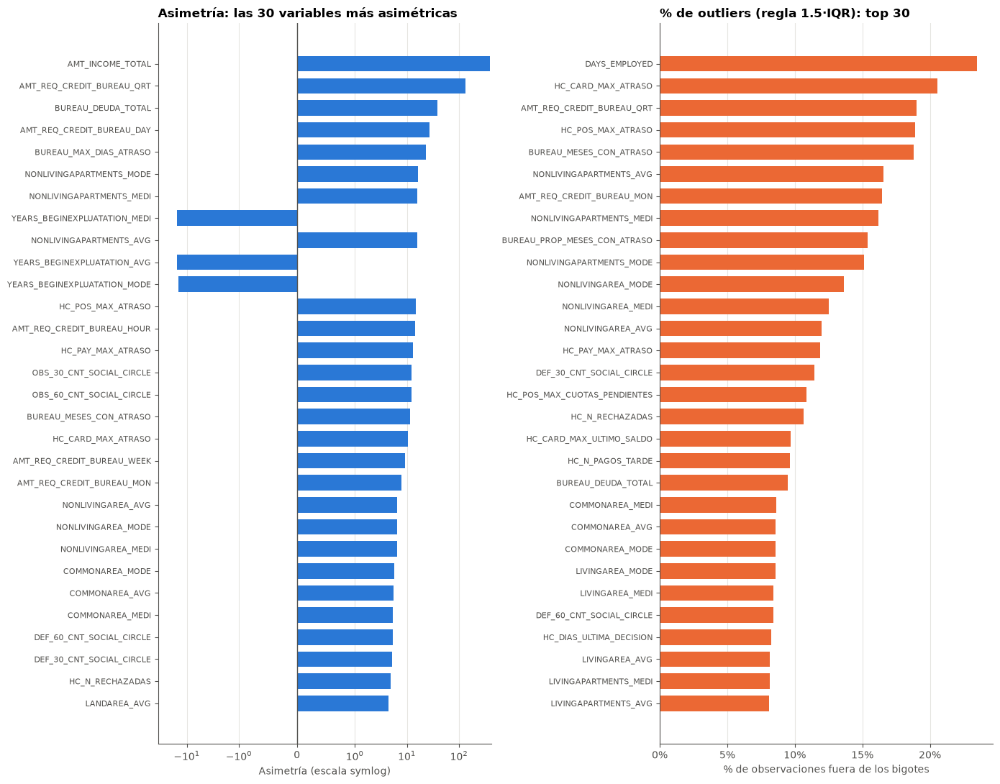

PosixPath('/home/claude/repo/artifacts/eda_figures/numericas/00_panorama_asimetria_outliers.png')

In [36]:
# Variables continuas, no negativas y con cola derecha pesada: se complementa con la vista en log(1+x)
LOG_CANDIDATAS = [c for c in NUMERICAS if METRICAS.loc[c, "min"] >= 0 and METRICAS.loc[c, "asimetria"] > 2 and not METRICAS.loc[c, "es_conteo"]]
print(f"{len(LOG_CANDIDATAS)} variables con vista logarítmica:", LOG_CANDIDATAS)


def graficar_numerica_log(col):
    m = METRICAS.loc[col]
    x = df[col].dropna().to_numpy(dtype=float)
    if not np.isnan(m["centinela"]):
        x = x[x != m["centinela"]]
    z = np.log1p(x[x > -1])
    mu, sd = z.mean(), z.std()
    rg = np.random.default_rng(SEMILLA)
    d_ks = stats.kstest(rg.choice(z, min(len(z), N_MUESTRA_AJUSTE), replace=False), "norm", args=(mu, sd)).statistic

    fig, (ax, axq) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [2.3, 1], "wspace": 0.25})
    n_bins = int(np.clip(len(np.histogram_bin_edges(z, bins="fd")) - 1, 25, 80))
    edges = np.linspace(z.min(), z.max(), n_bins + 1)
    ax.hist(z, bins=edges, density=True, color=C_PRINCIPAL, alpha=0.55, edgecolor="white", linewidth=0.4, label="Datos")
    grid = np.linspace(z.min(), z.max(), 400)
    ax.plot(grid, stats.norm.pdf(grid, mu, sd), color=C_TEORICA, lw=2.2, label=f"normal (μ={mu:.2f}, σ={sd:.2f}) · D={d_ks:.3f}")
    ax.axvline(z.mean(), color=C_TEXTO, lw=1.3, label=f"Media = {z.mean():.2f}")
    ax.axvline(np.median(z), color=C_TEXTO, lw=1.3, ls=":", label=f"Mediana = {np.median(z):.2f}")
    ax.set_xlabel(f"log(1 + {col})")
    ax.set_ylabel("Densidad")
    ax.yaxis.set_major_formatter(_fmt_dens)
    ax.legend(loc="best", frameon=True, framealpha=0.92, facecolor="white", edgecolor="none")
    ax.set_title(f"{col} · vista logarítmica", pad=20)
    ax.annotate(f"asimetría original {m['asimetria']:.2f} → asimetría en log(1+x) {stats.skew(z):.2f} · si la normal ajusta bien, la variable es ≈ lognormal",
                xy=(0, 1), xycoords="axes fraction", xytext=(0, 5), textcoords="offset points", fontsize=9, color=C_TEXTO2)

    probs = np.linspace(0.005, 0.995, 200)
    axq.scatter(stats.norm.ppf(probs, mu, sd), np.quantile(z, probs), s=12, color=C_PRINCIPAL, alpha=0.75, linewidths=0)
    lims = [z.min(), z.max()]
    axq.plot(lims, lims, color=C_TEORICA, lw=1.5)
    axq.set_xlabel("Cuantiles teóricos (normal)")
    axq.set_ylabel("Cuantiles observados")
    axq.set_title("Q-Q vs normal")
    return guardar_figura(fig, "numericas", f"{col}_log1p")


def grafico_panorama_numericas(top=30):
    m = METRICAS
    top = min(top, len(m))
    ord_skew = m["asimetria"].abs().sort_values(ascending=False).head(top).index
    ord_out = m["pct_outliers_iqr"].sort_values(ascending=False).head(top).index
    fig, axes = plt.subplots(1, 2, figsize=(14, 0.3 * top + 2))
    axes[0].barh(range(top), m.loc[ord_skew, "asimetria"], color=C_PRINCIPAL, height=0.7)
    axes[0].set_yticks(range(top)); axes[0].set_yticklabels(ord_skew, fontsize=8); axes[0].invert_yaxis()
    axes[0].axvline(0, color=C_TEXTO2, lw=1)
    axes[0].set_xscale("symlog", linthresh=1)
    axes[0].set_title(f"Asimetría: las {top} variables más asimétricas")
    axes[0].set_xlabel("Asimetría (escala symlog)")
    axes[1].barh(range(top), m.loc[ord_out, "pct_outliers_iqr"], color=C_TEORICA, height=0.7)
    axes[1].set_yticks(range(top)); axes[1].set_yticklabels(ord_out, fontsize=8); axes[1].invert_yaxis()
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    axes[1].set_title(f"% de outliers (regla 1.5·IQR): top {top}")
    axes[1].set_xlabel("% de observaciones fuera de los bigotes")
    for ax in axes:
        ax.grid(axis="y", visible=False)
    fig.tight_layout()
    return guardar_figura(fig, "numericas", "00_panorama_asimetria_outliers")


grafico_panorama_numericas()

#### `CNT_CHILDREN`

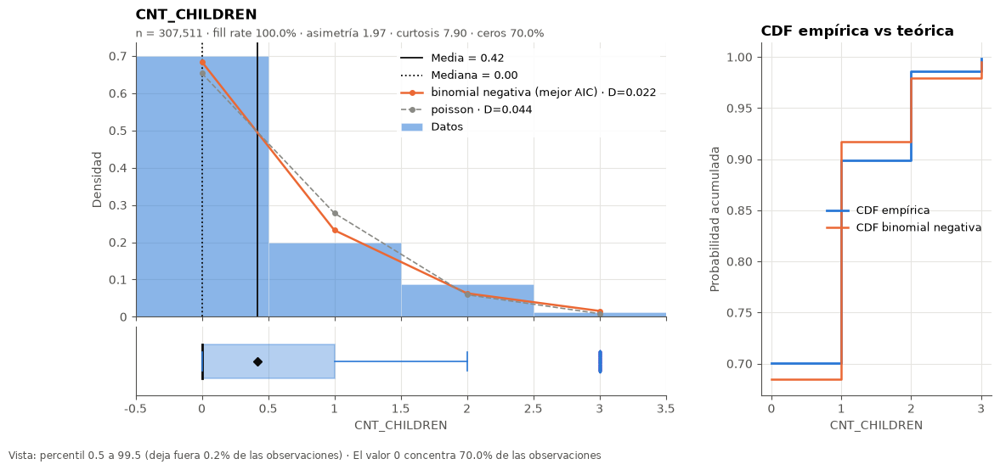

#### `AMT_INCOME_TOTAL`

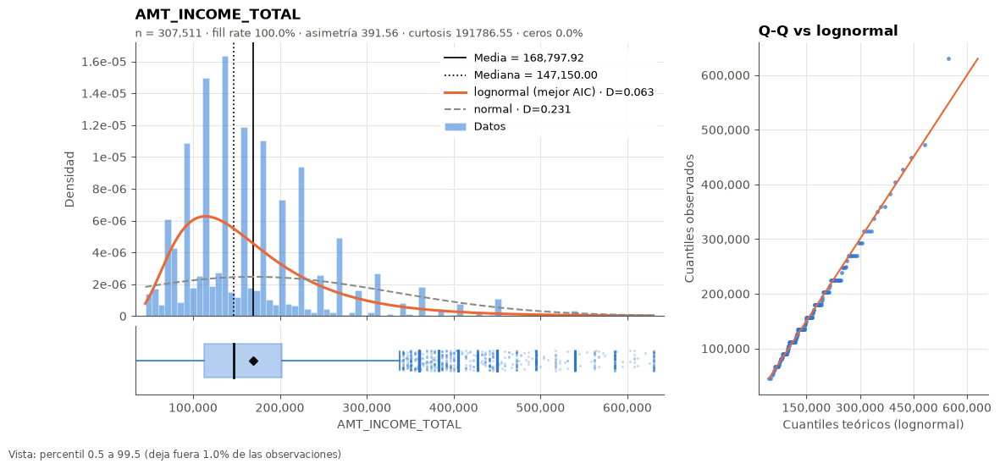

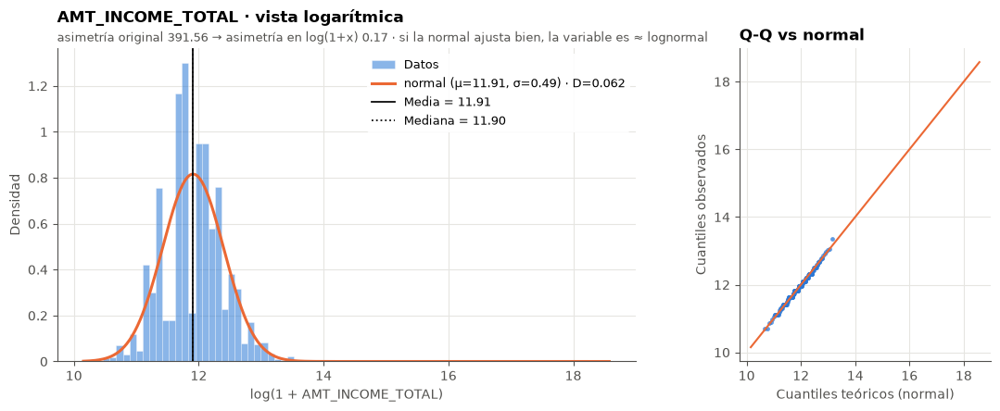

#### `AMT_CREDIT`

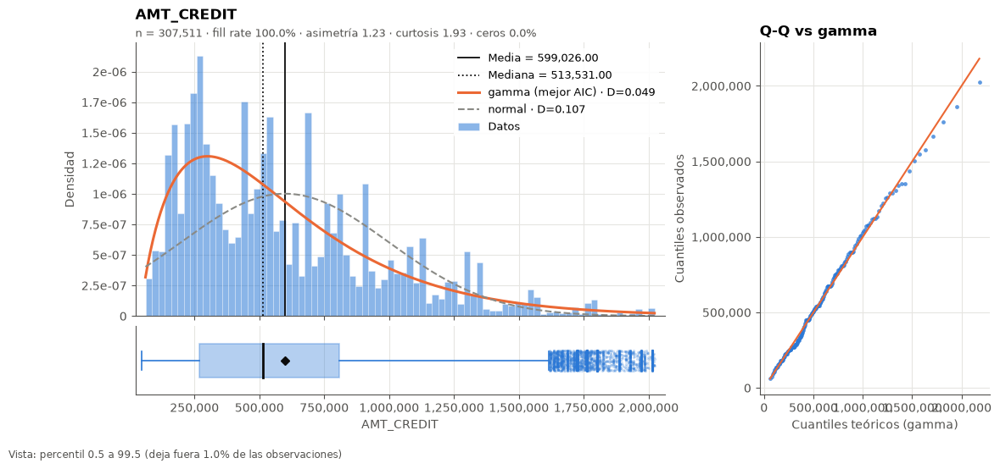

#### `AMT_ANNUITY`

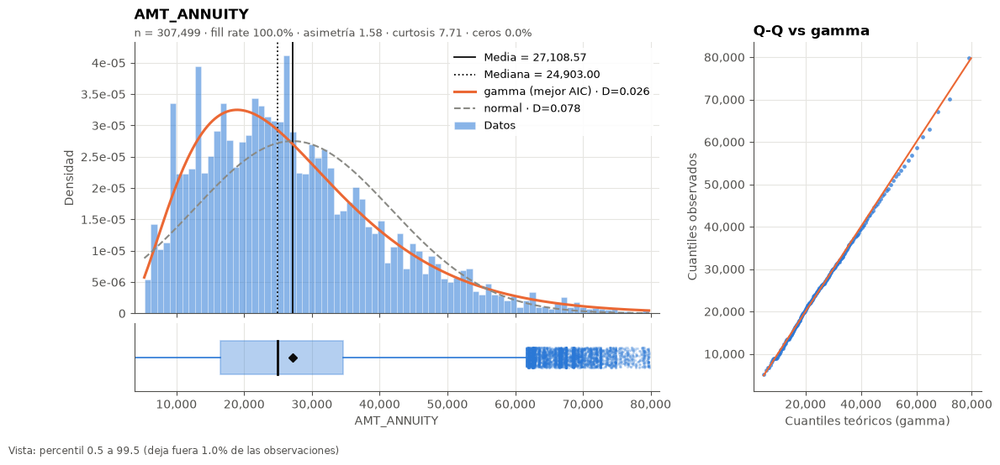

#### `AMT_GOODS_PRICE`

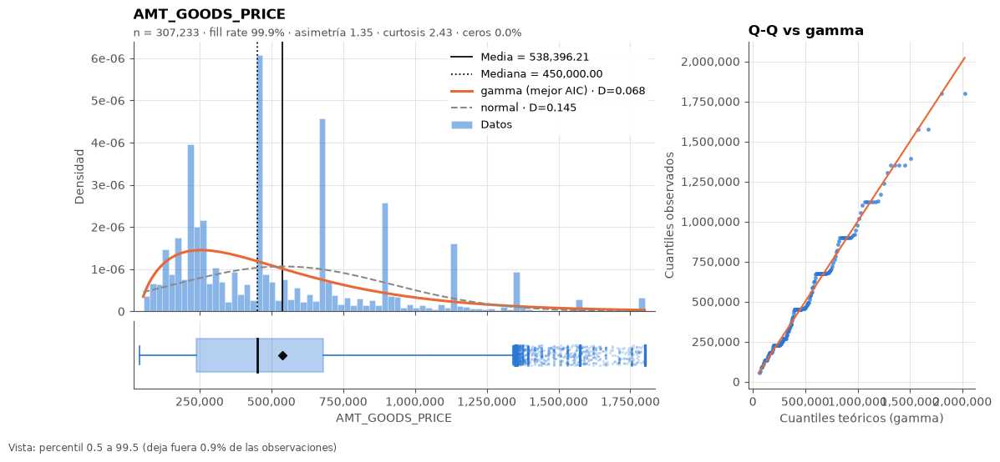

#### `REGION_POPULATION_RELATIVE`

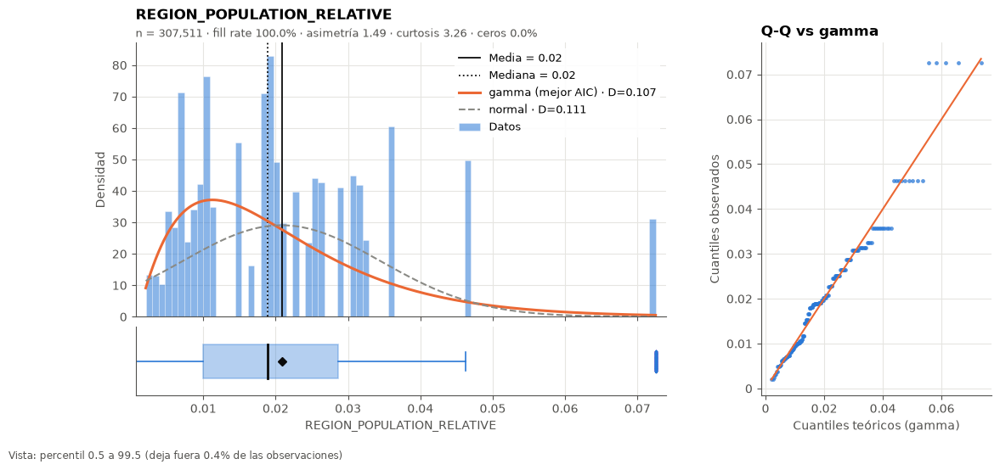

#### `DAYS_BIRTH`

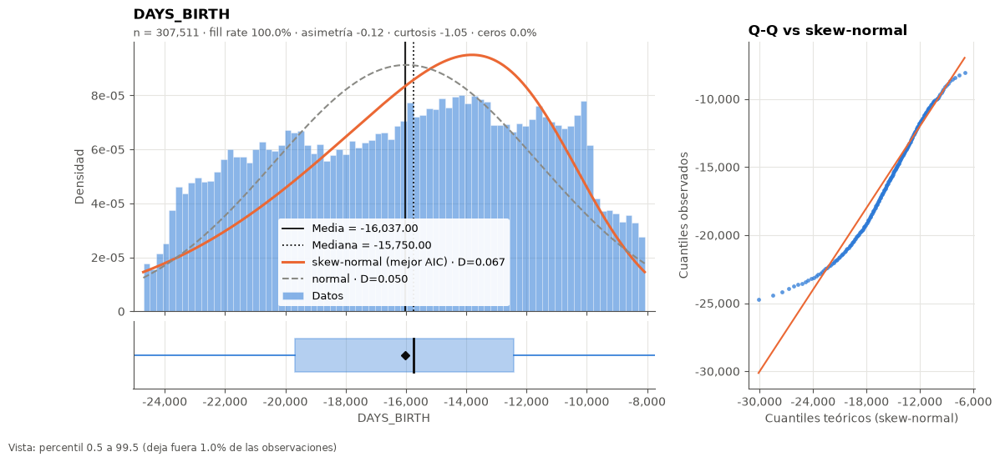

#### `DAYS_EMPLOYED`

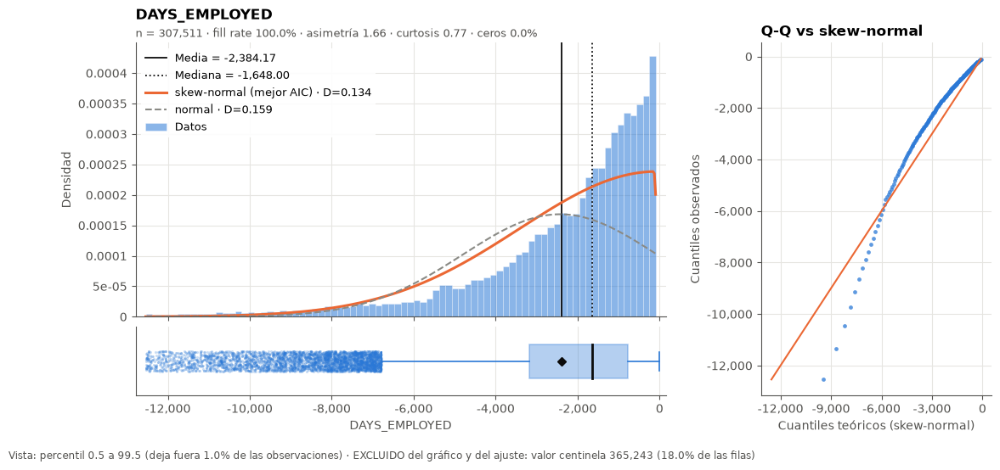

#### `DAYS_REGISTRATION`

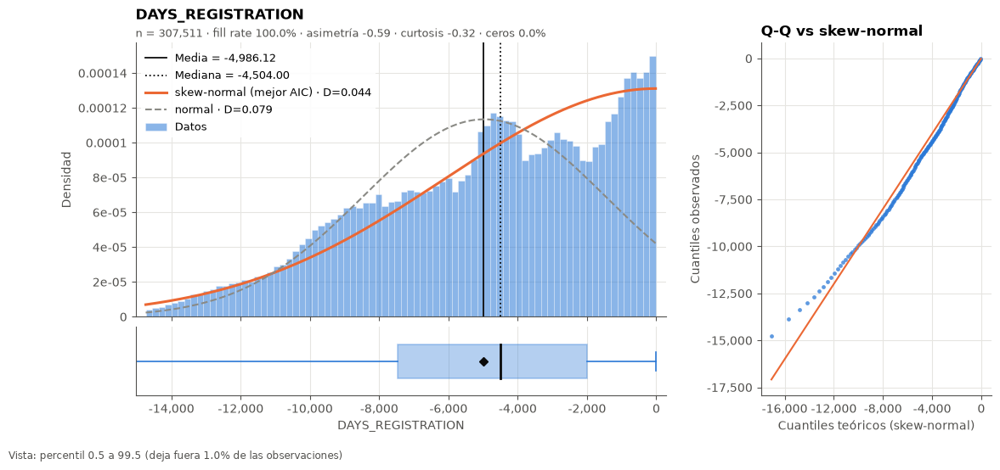

#### `DAYS_ID_PUBLISH`

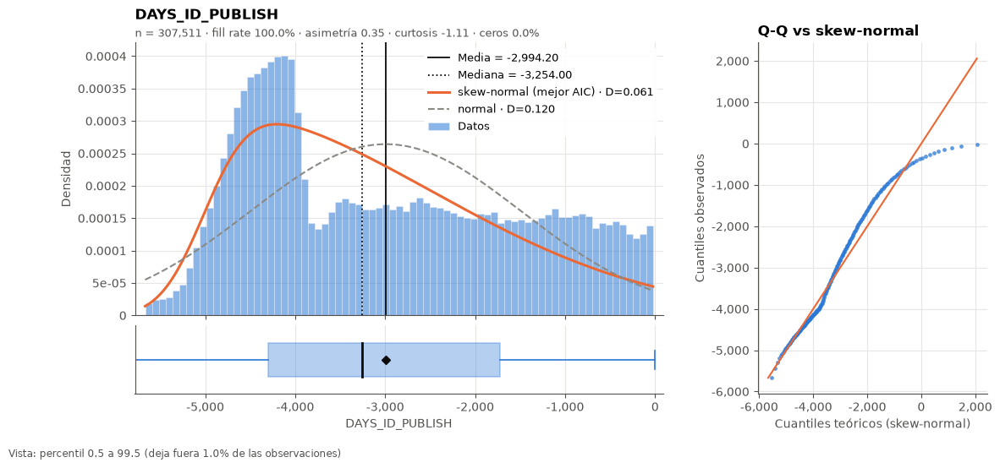

#### `OWN_CAR_AGE`

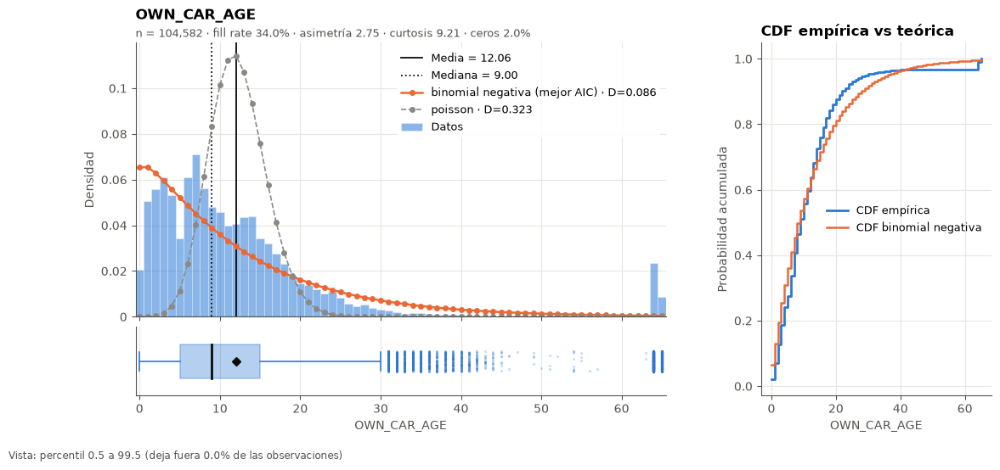

#### `CNT_FAM_MEMBERS`

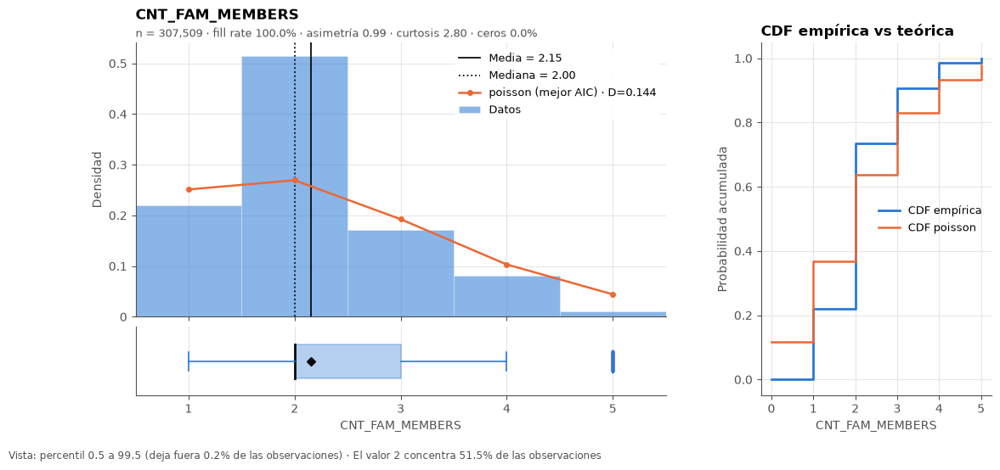

#### `HOUR_APPR_PROCESS_START`

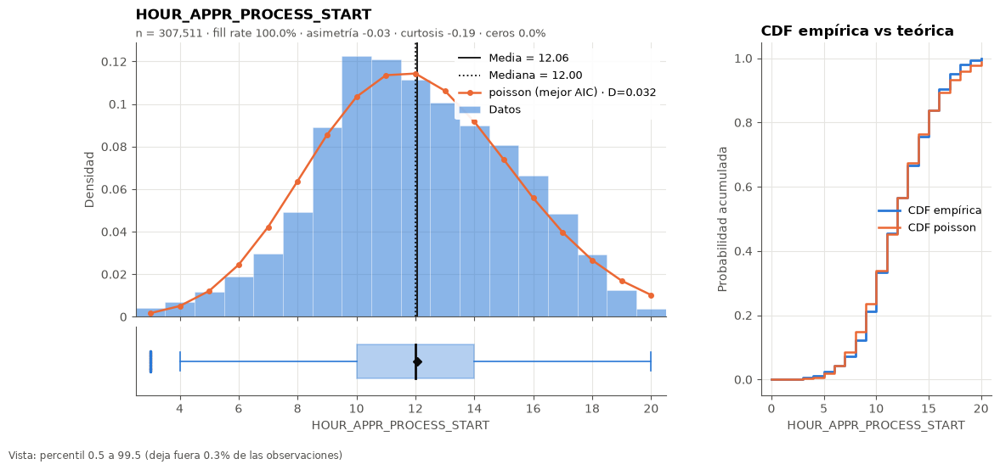

#### `EXT_SOURCE_1`

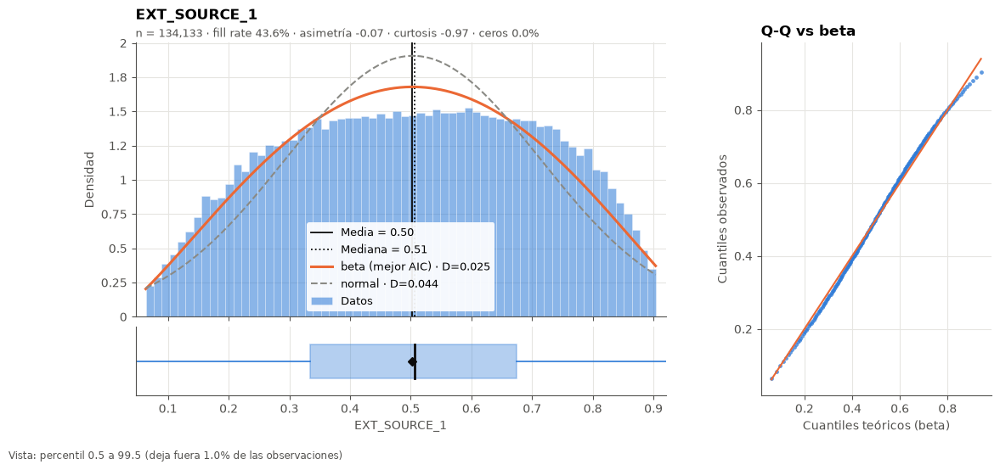

#### `EXT_SOURCE_2`

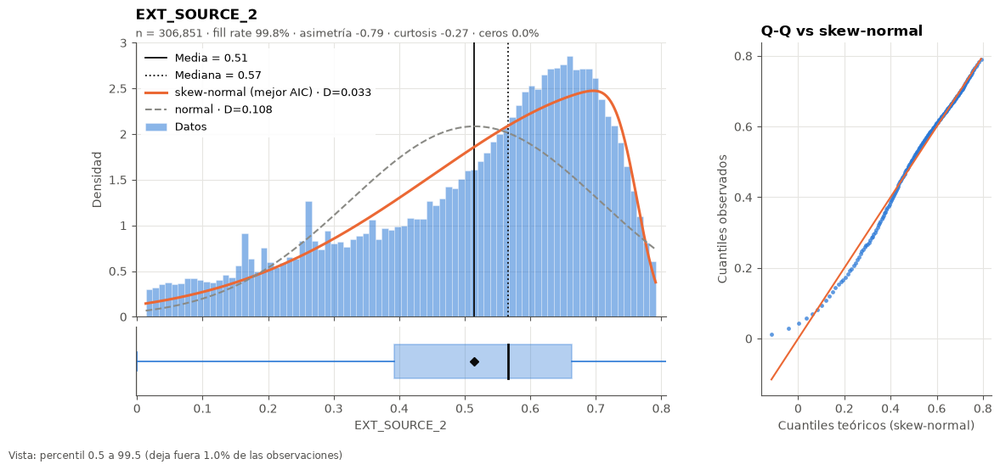

#### `EXT_SOURCE_3`

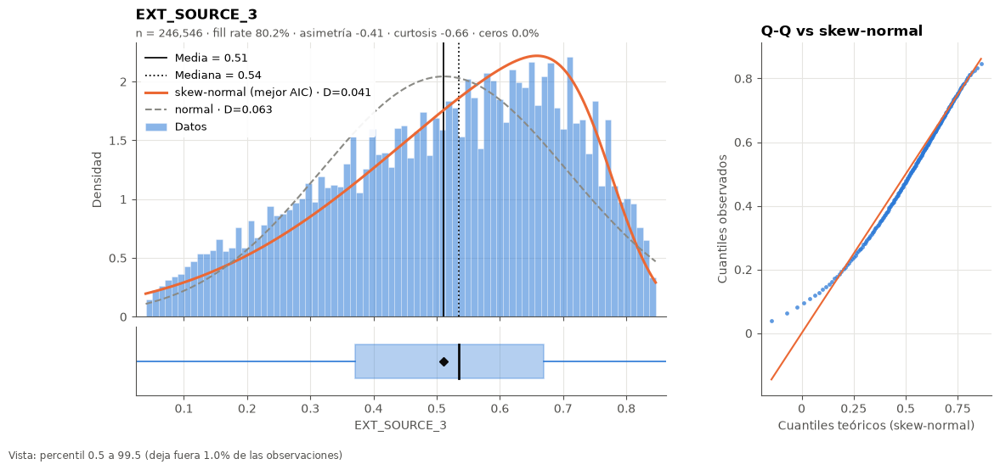

#### `APARTMENTS_AVG`

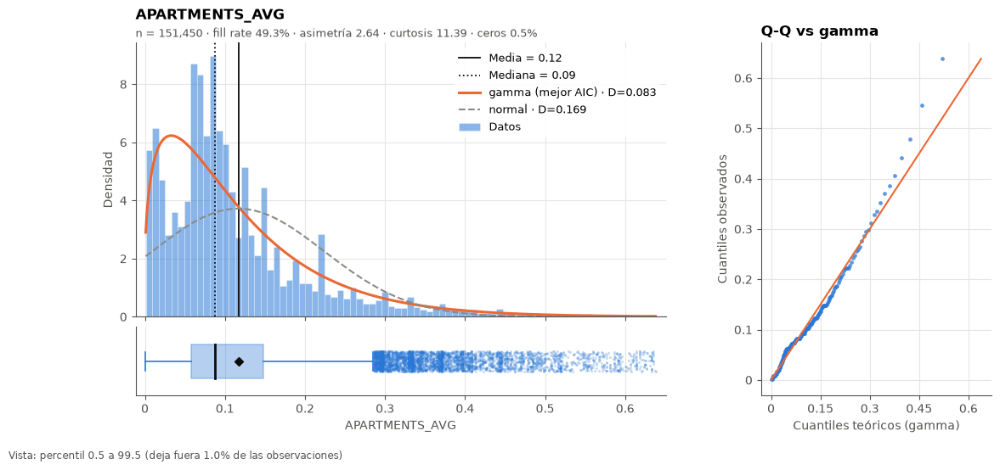

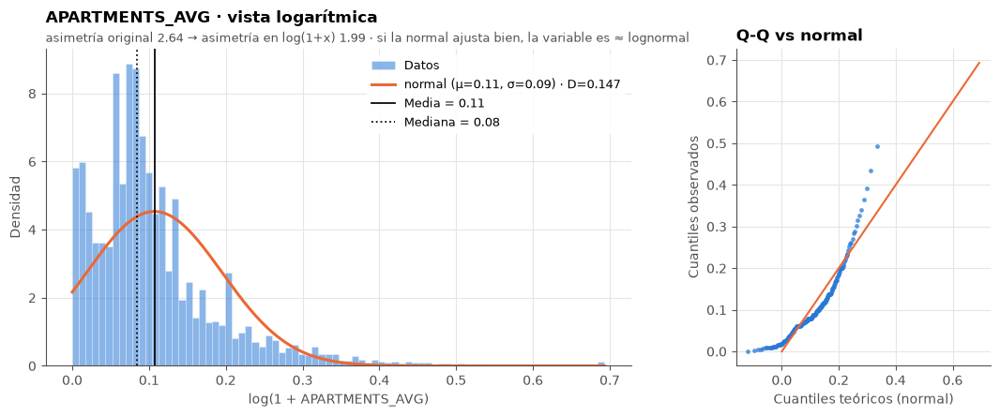

#### `BASEMENTAREA_AVG`

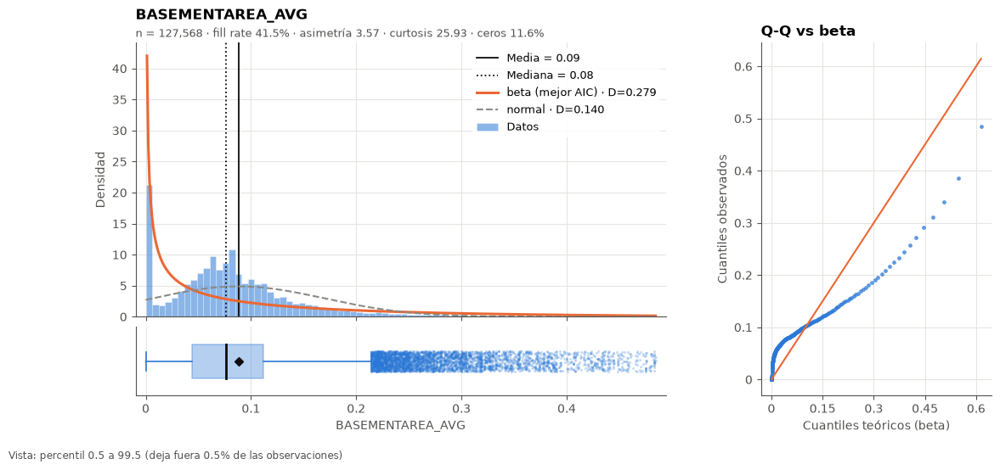

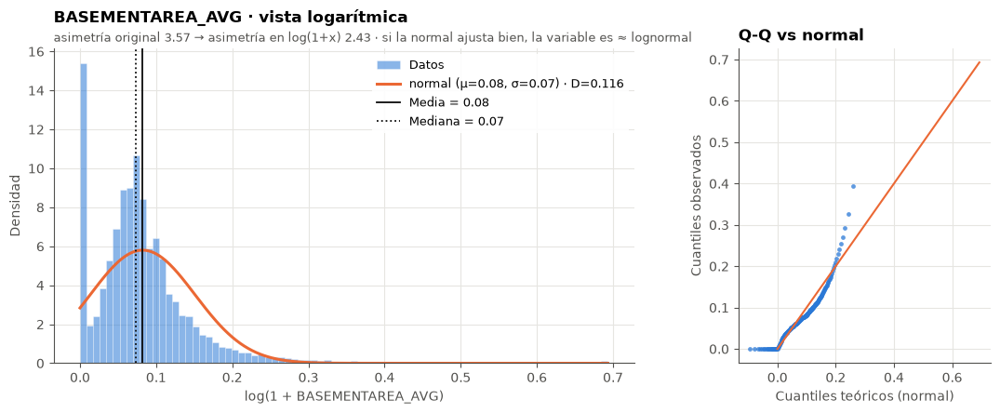

#### `YEARS_BEGINEXPLUATATION_AVG`

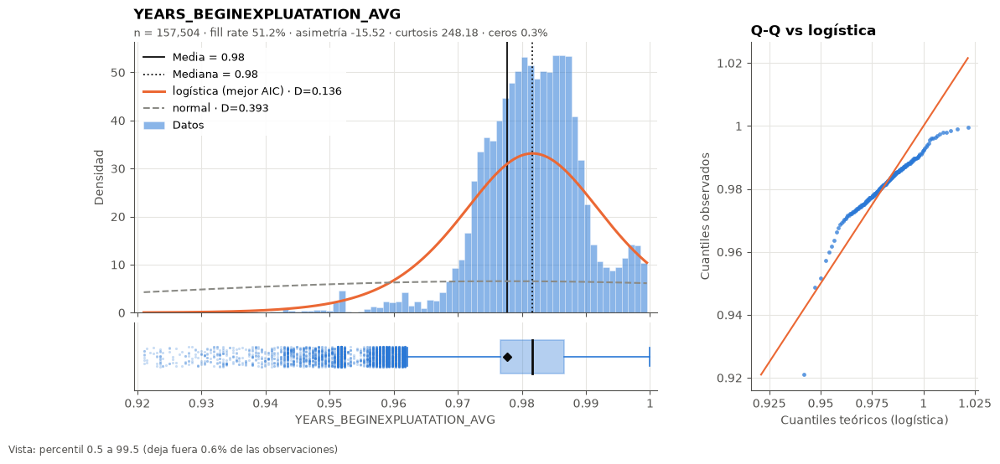

#### `YEARS_BUILD_AVG`

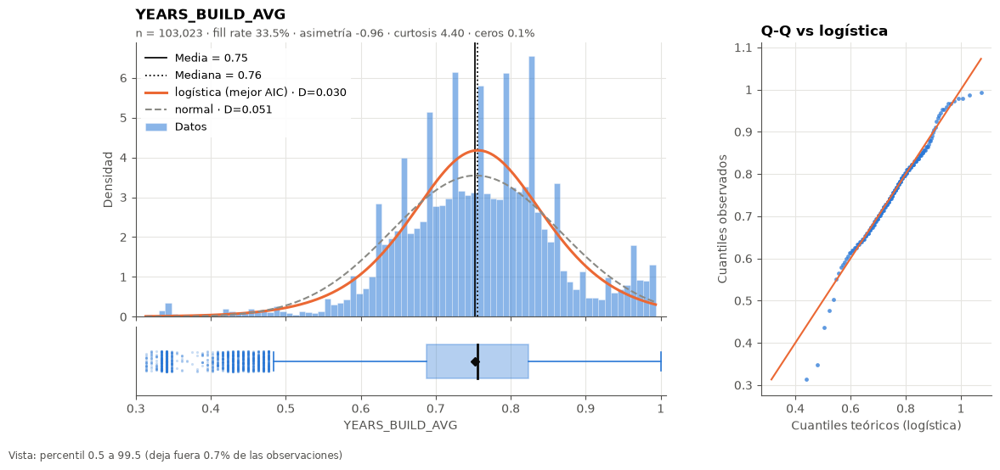

#### `COMMONAREA_AVG`

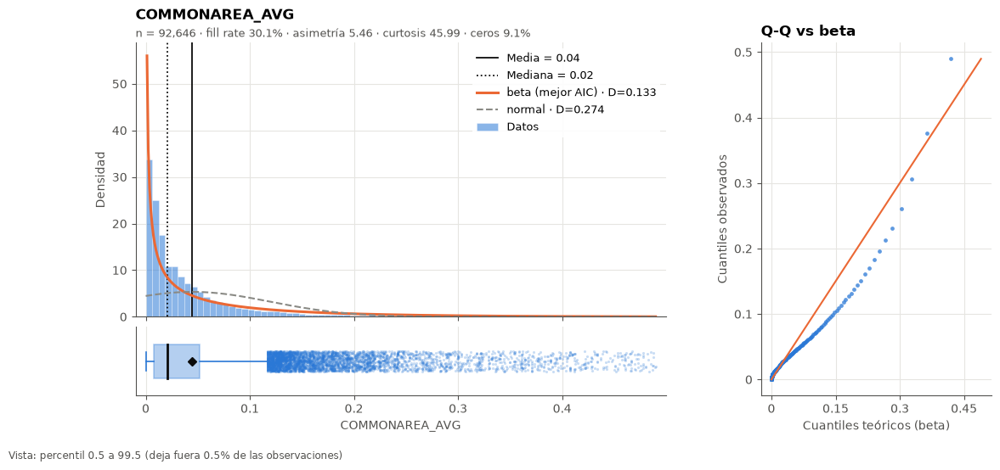

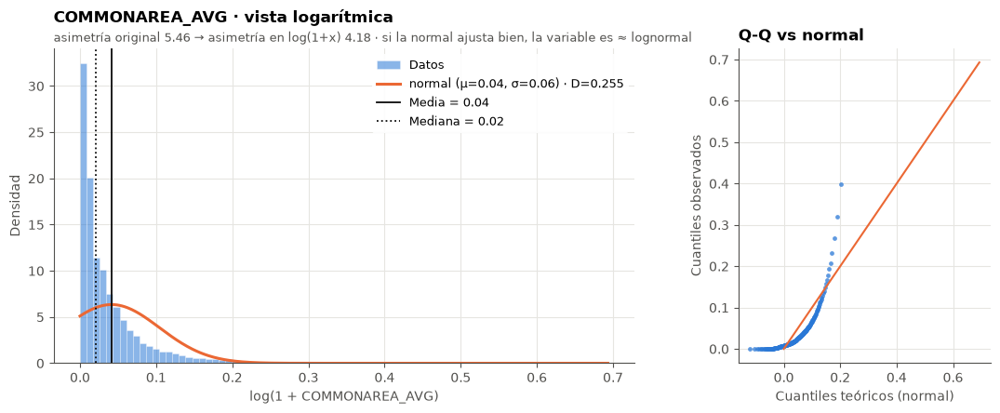

#### `ELEVATORS_AVG`

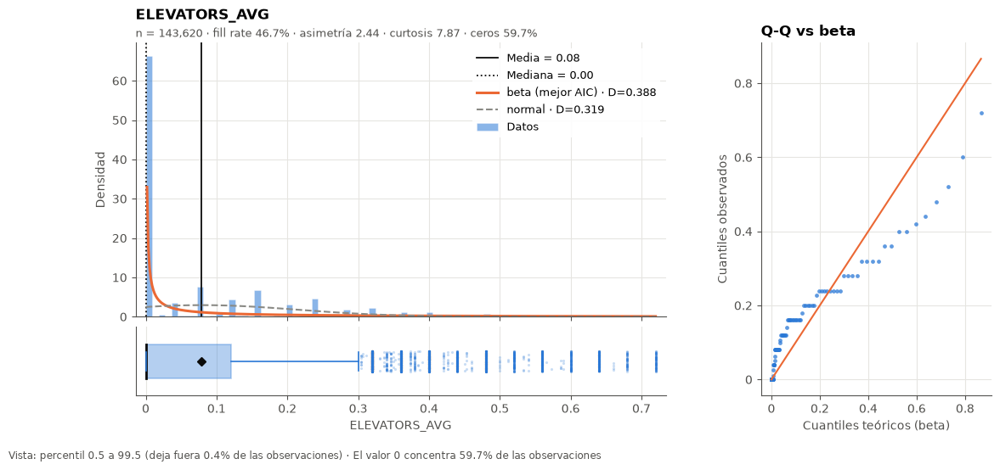

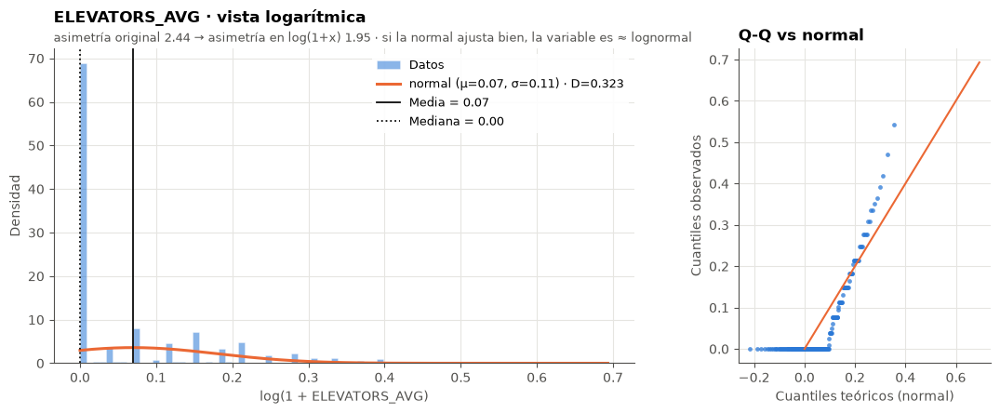

#### `ENTRANCES_AVG`

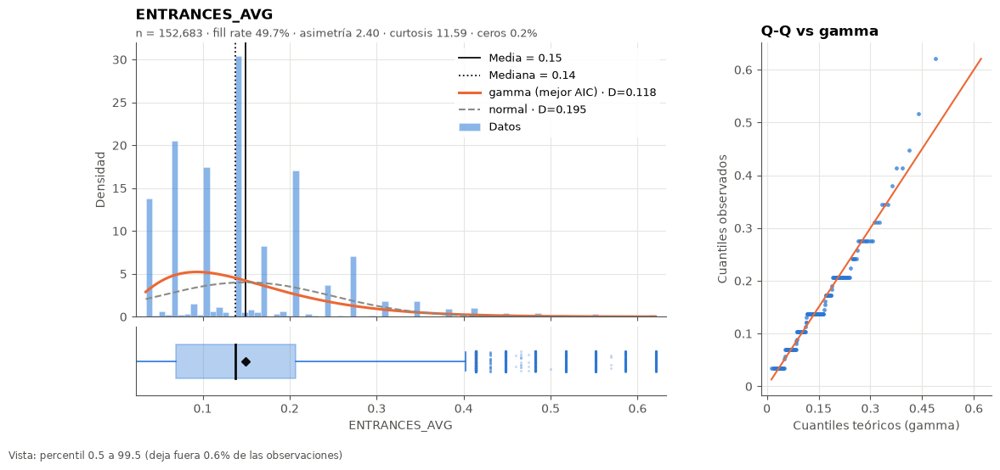

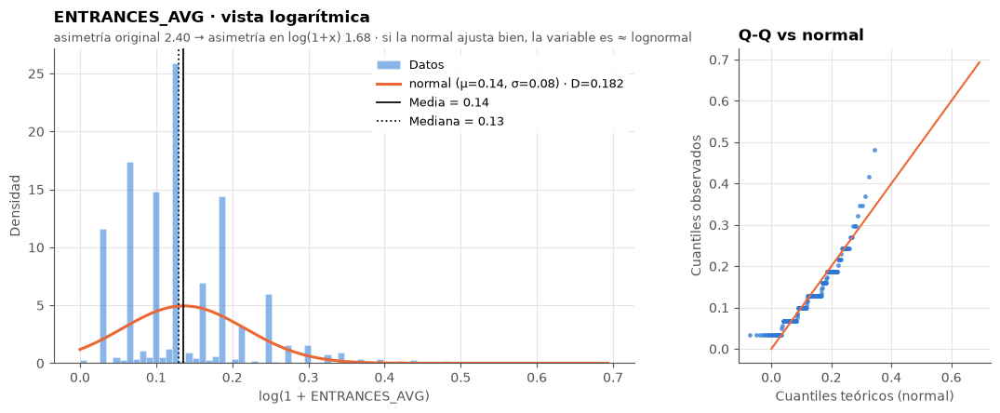

#### `FLOORSMAX_AVG`

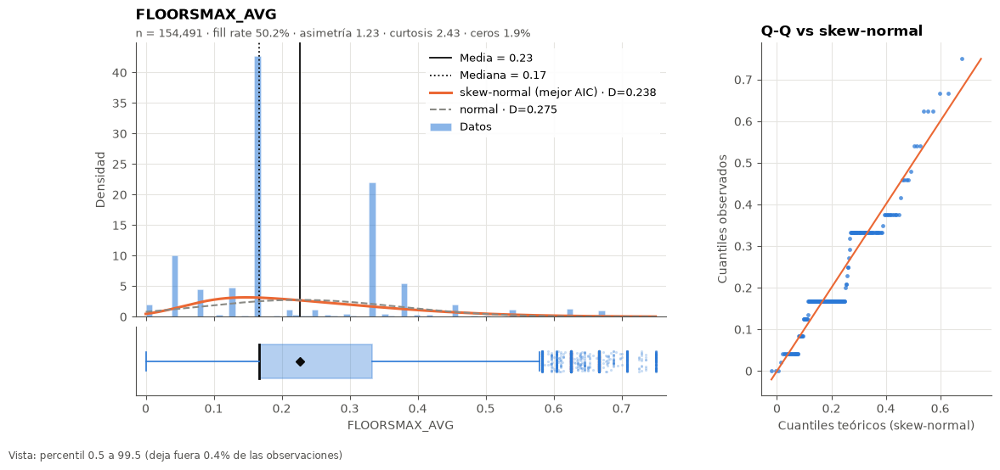

#### `FLOORSMIN_AVG`

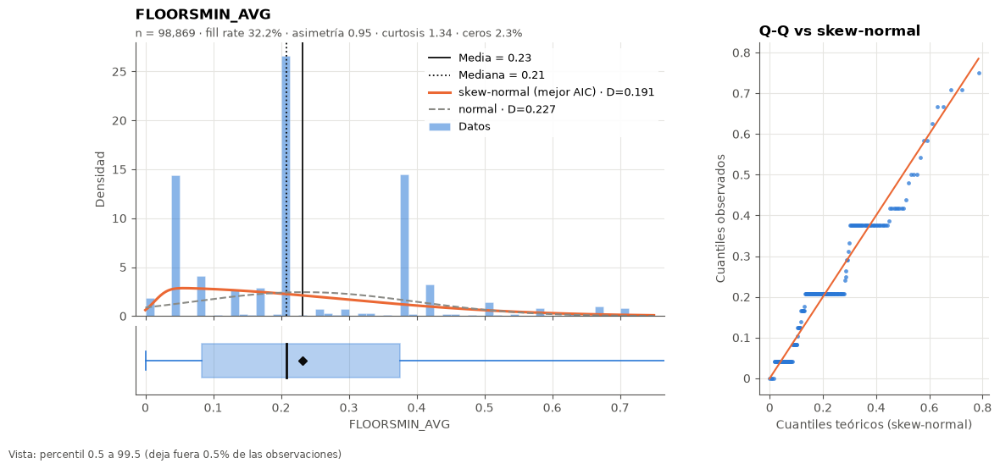

#### `LANDAREA_AVG`

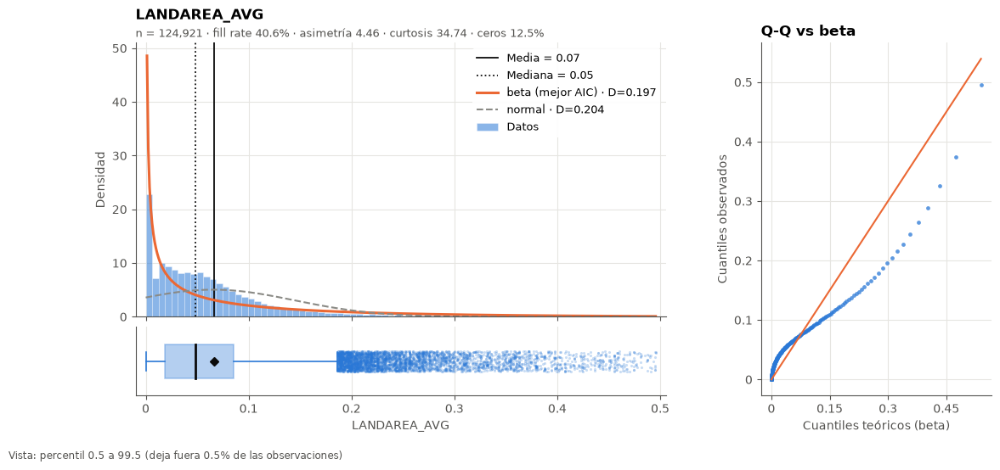

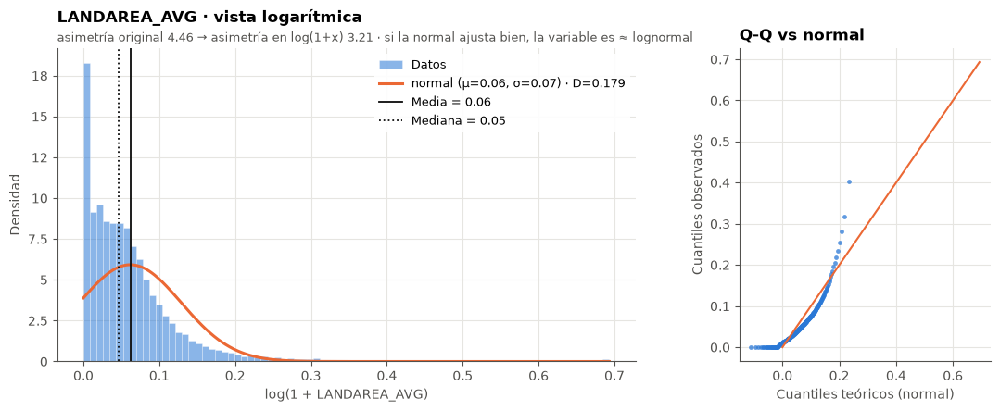

#### `LIVINGAPARTMENTS_AVG`

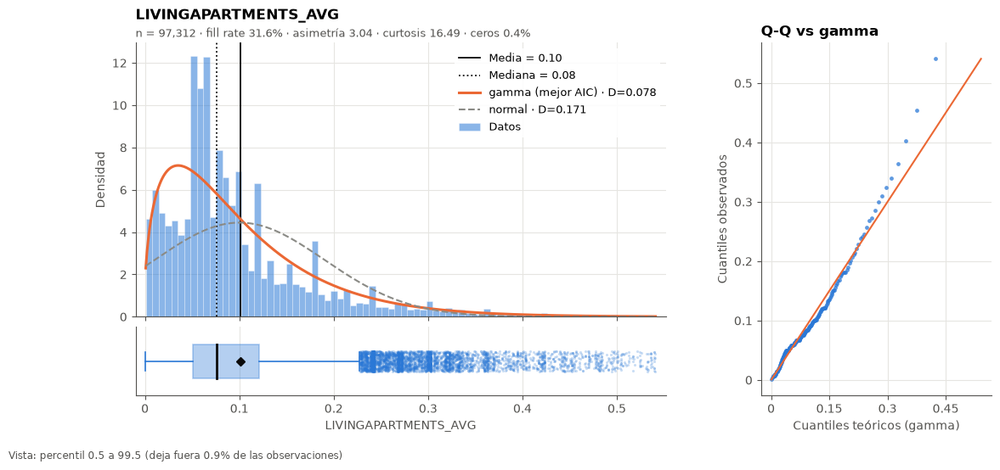

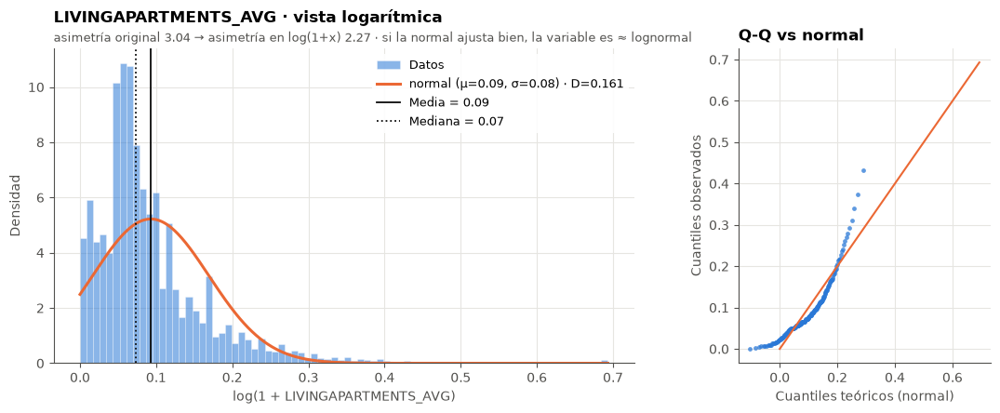

#### `LIVINGAREA_AVG`

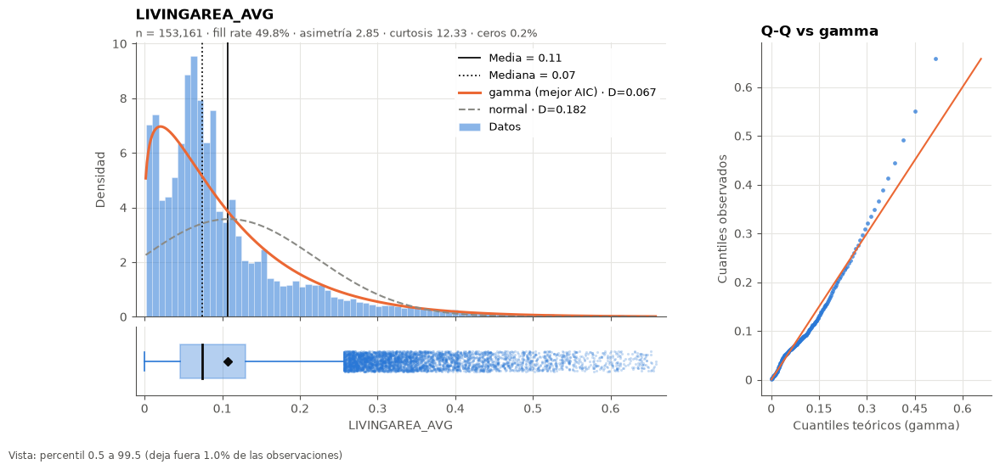

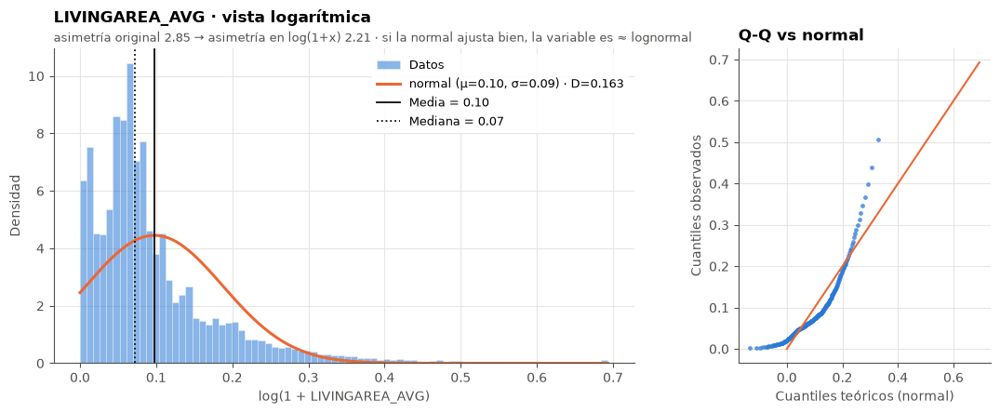

#### `NONLIVINGAPARTMENTS_AVG`

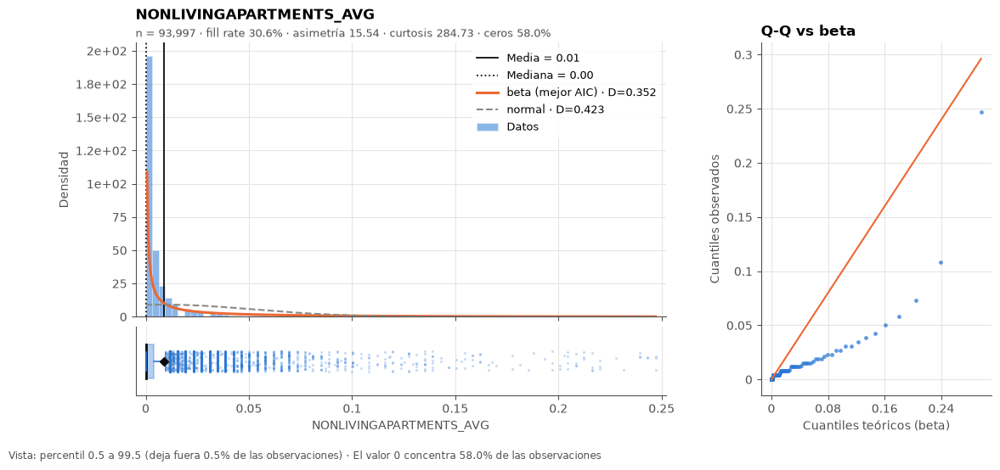

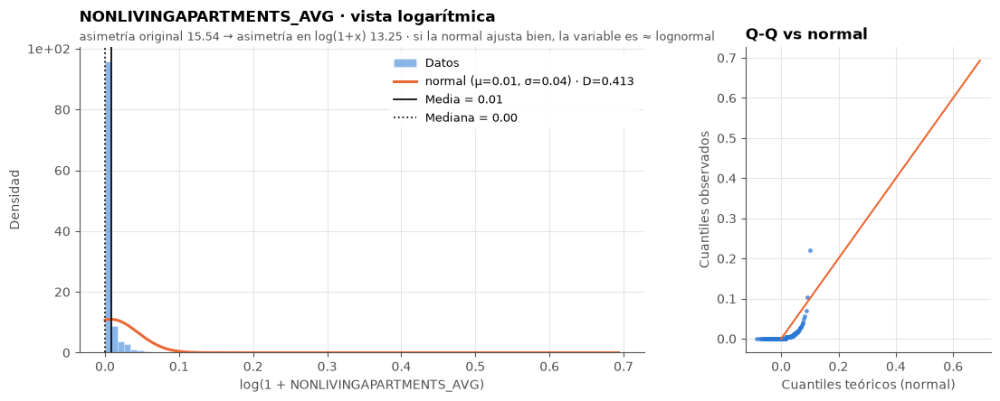

#### `NONLIVINGAREA_AVG`

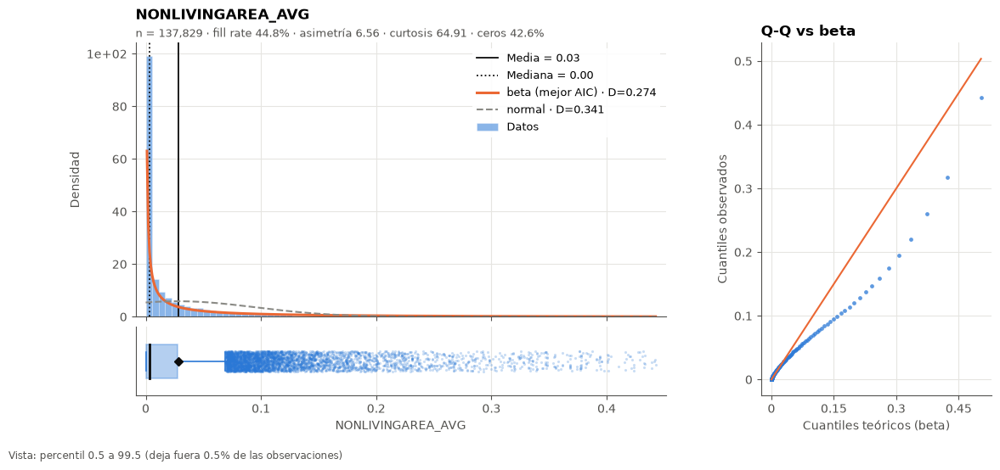

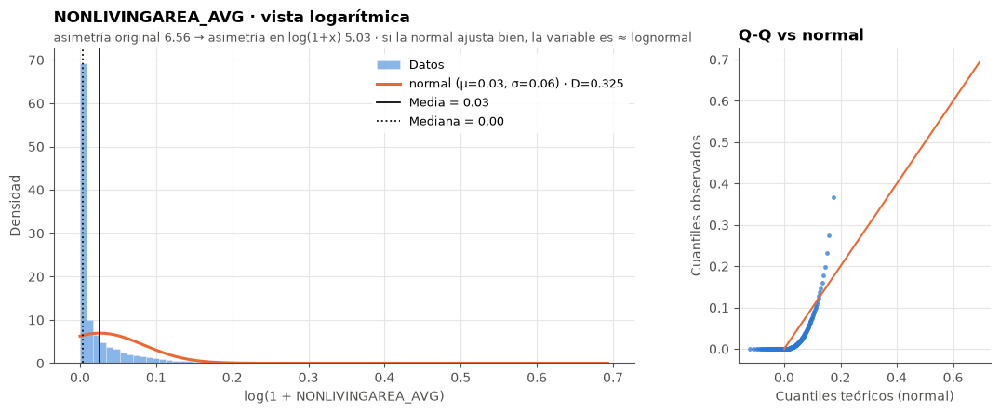

#### `APARTMENTS_MODE`

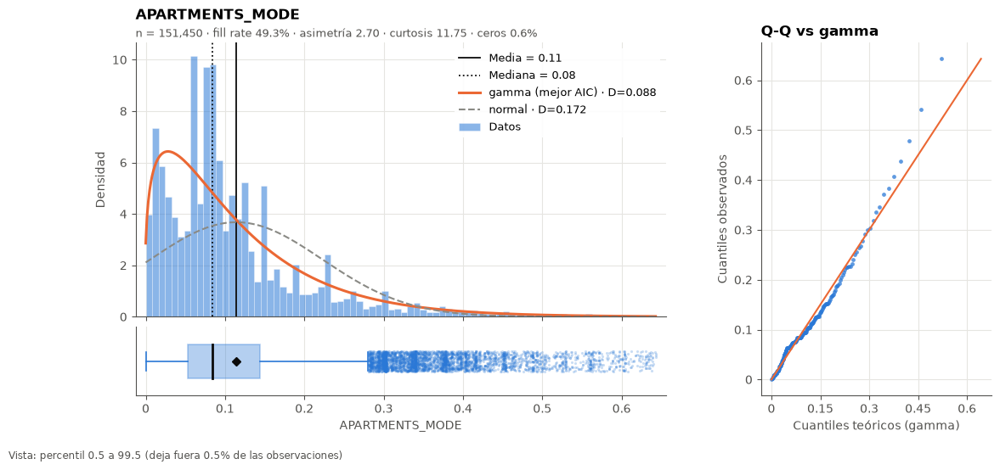

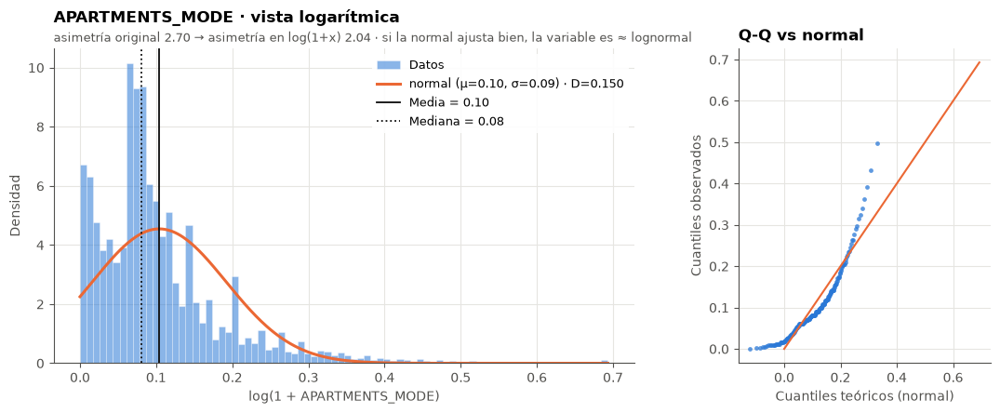

#### `BASEMENTAREA_MODE`

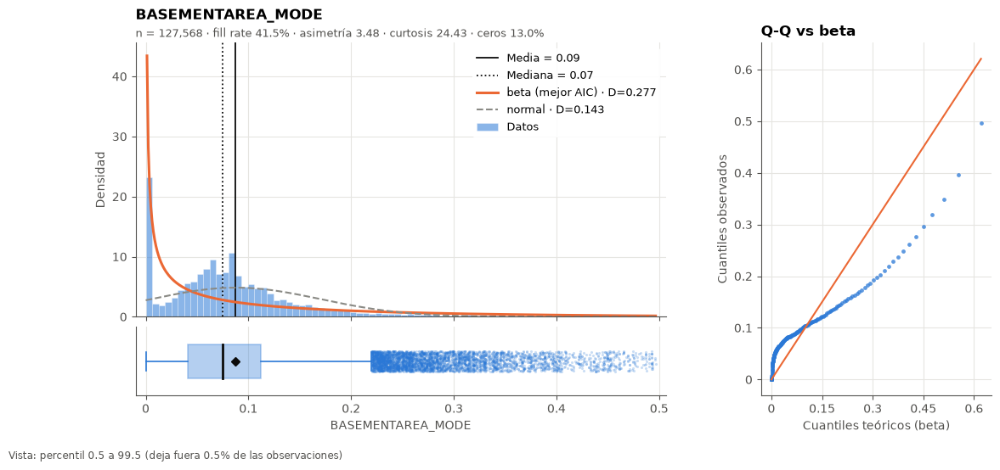

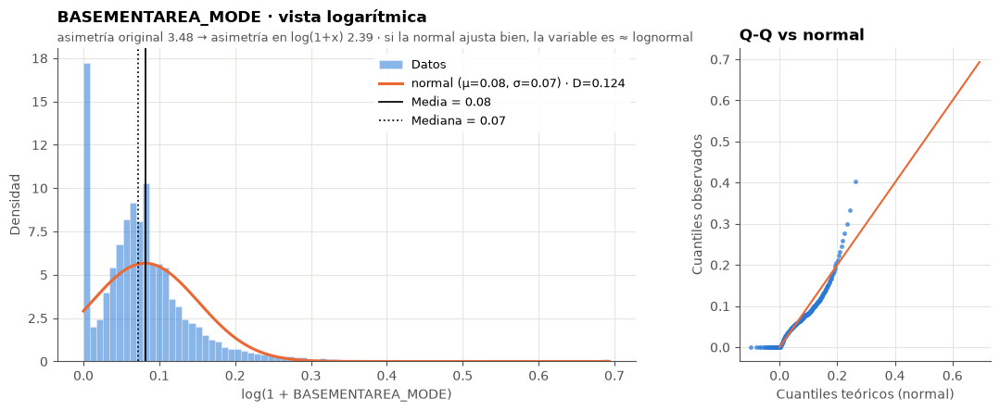

#### `YEARS_BEGINEXPLUATATION_MODE`

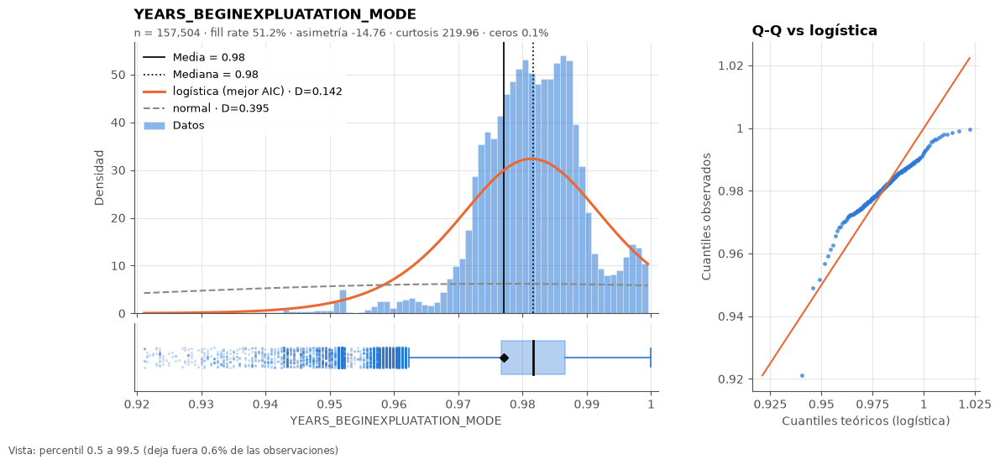

#### `YEARS_BUILD_MODE`

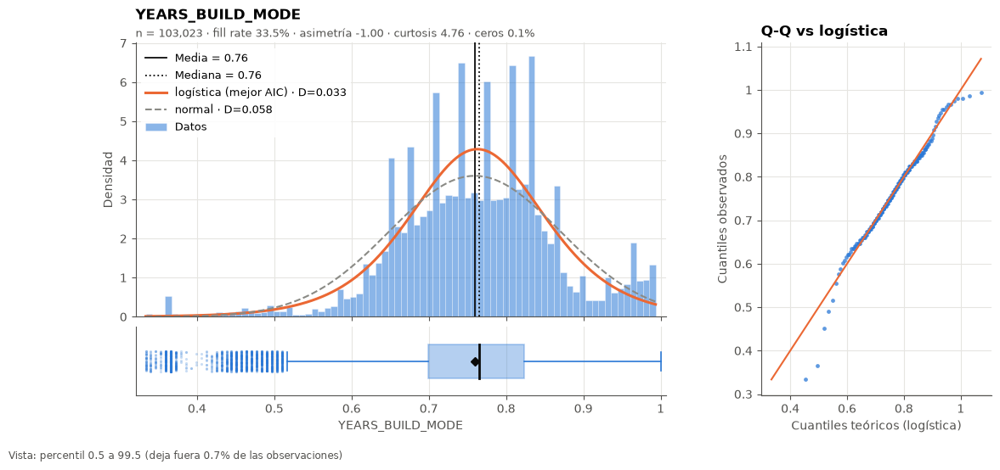

#### `COMMONAREA_MODE`

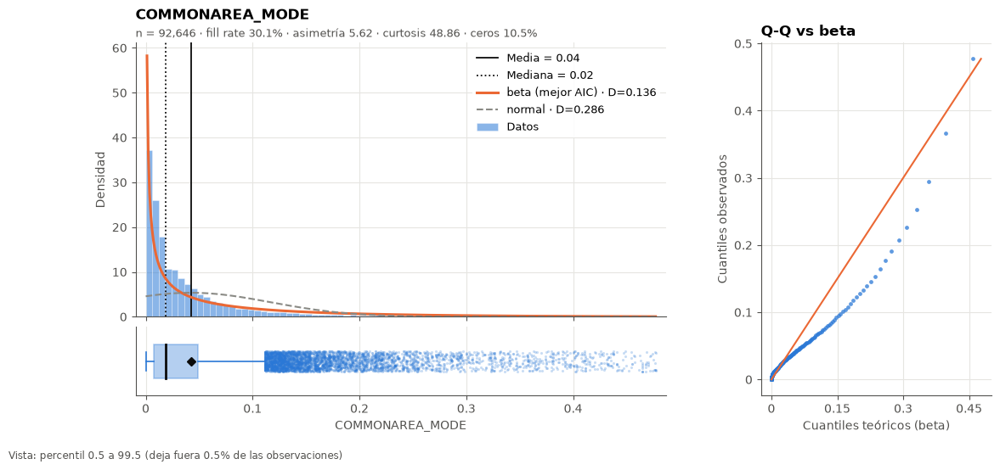

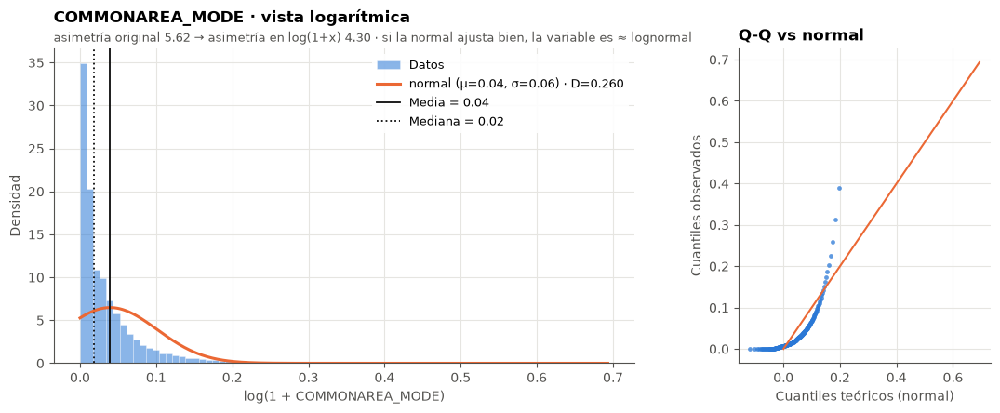

#### `ELEVATORS_MODE`

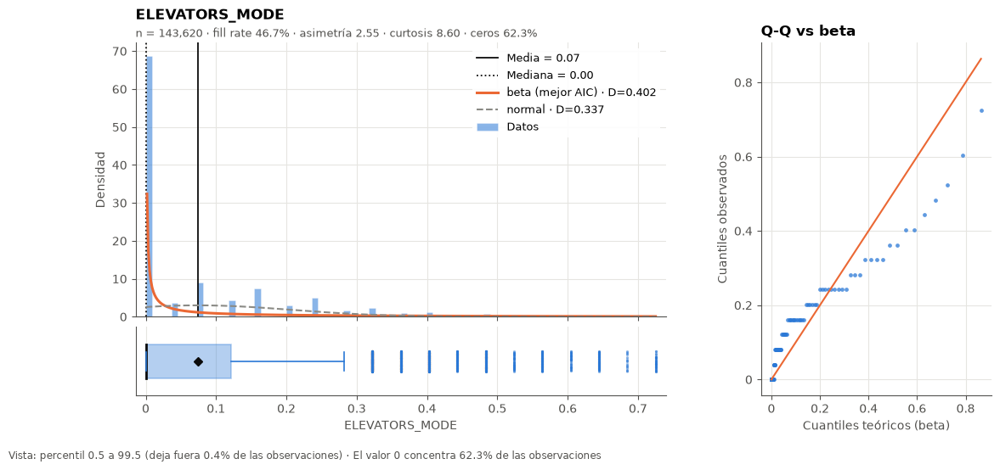

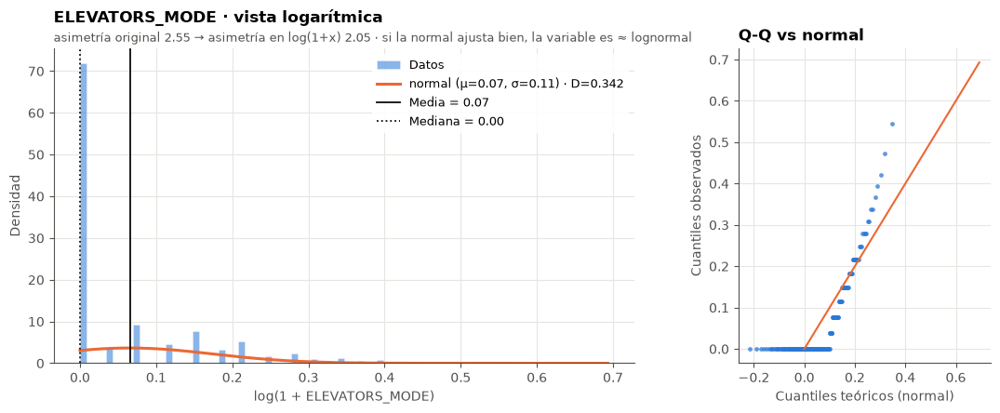

#### `ENTRANCES_MODE`

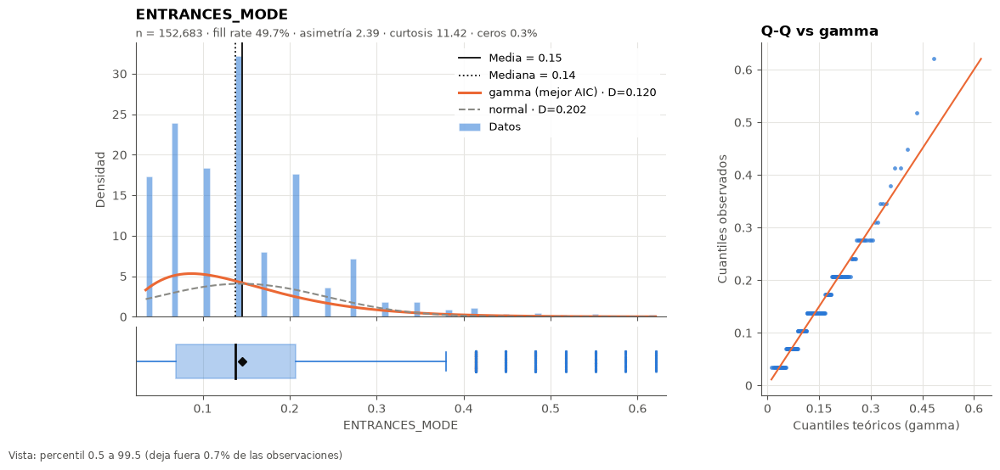

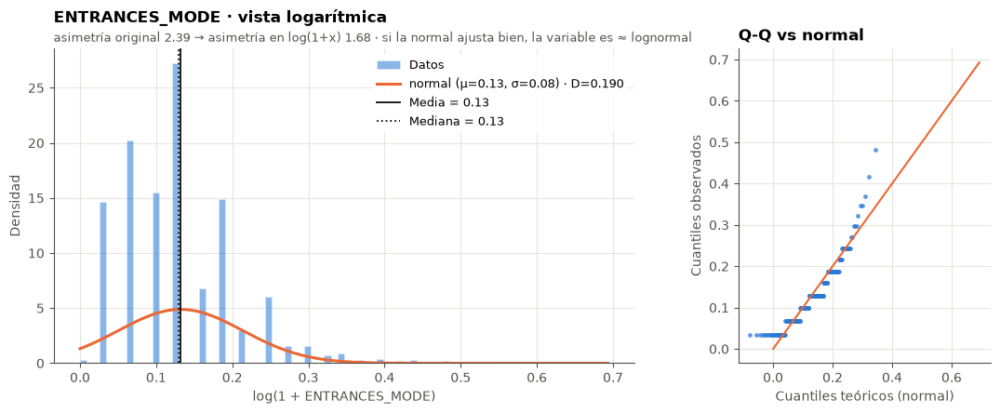

#### `FLOORSMAX_MODE`

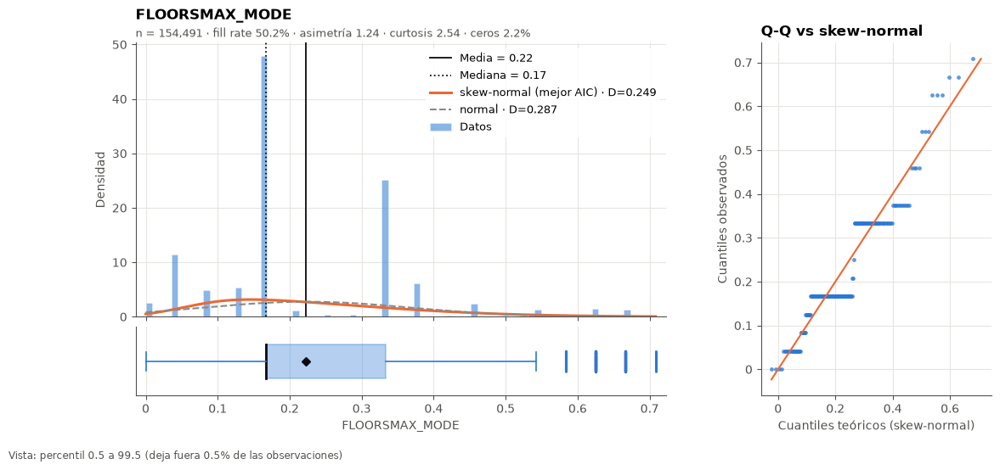

#### `FLOORSMIN_MODE`

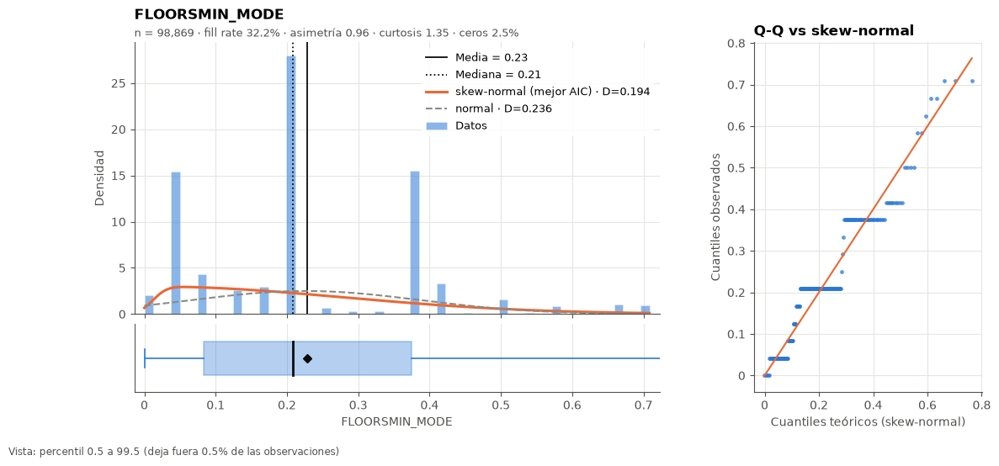

#### `LANDAREA_MODE`

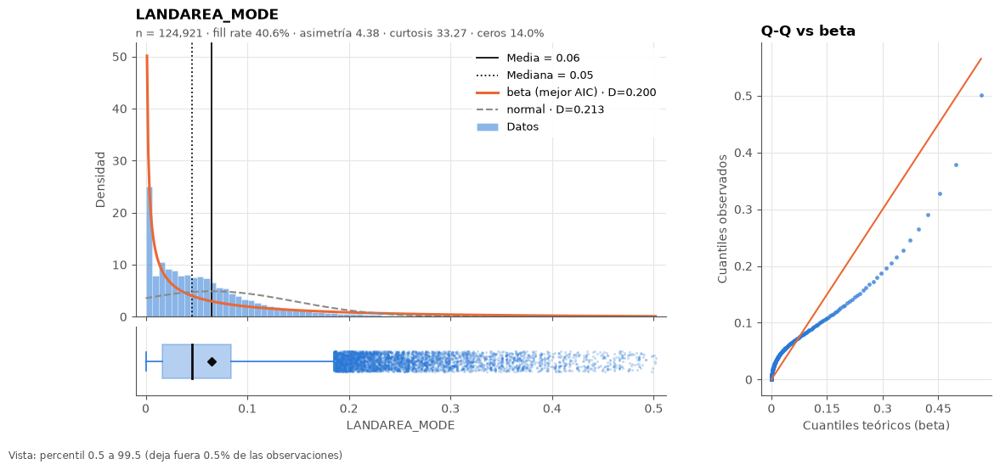

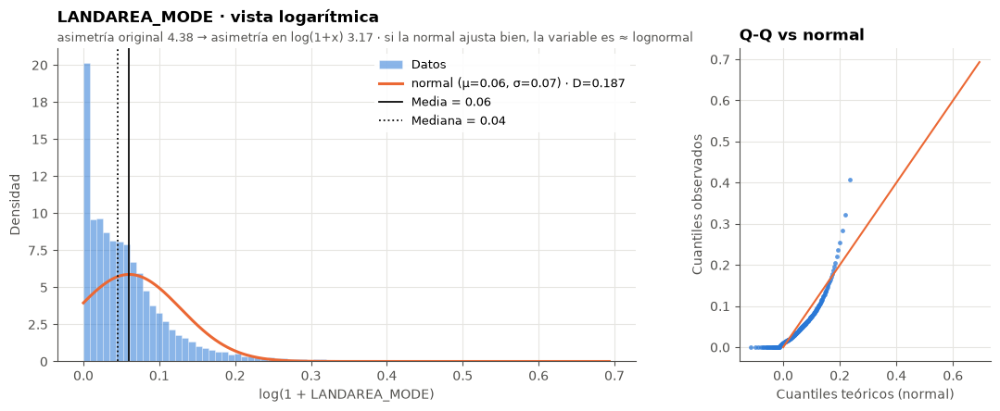

#### `LIVINGAPARTMENTS_MODE`

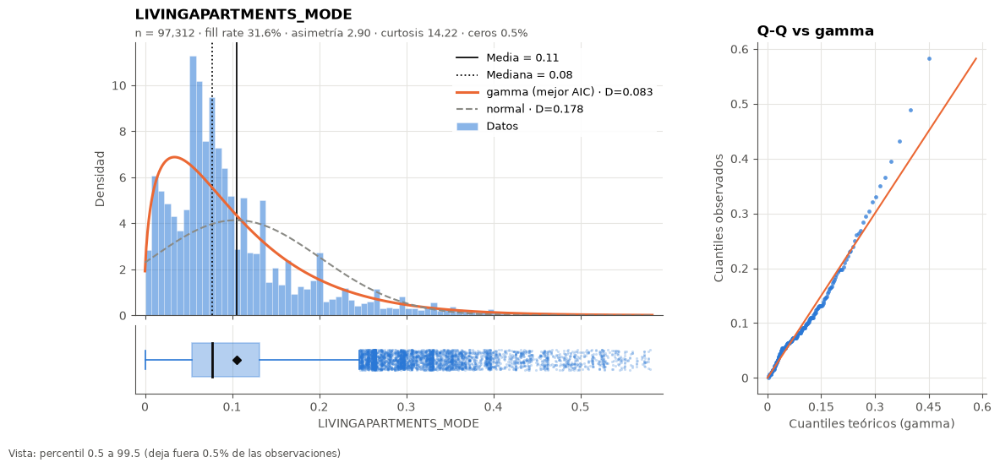

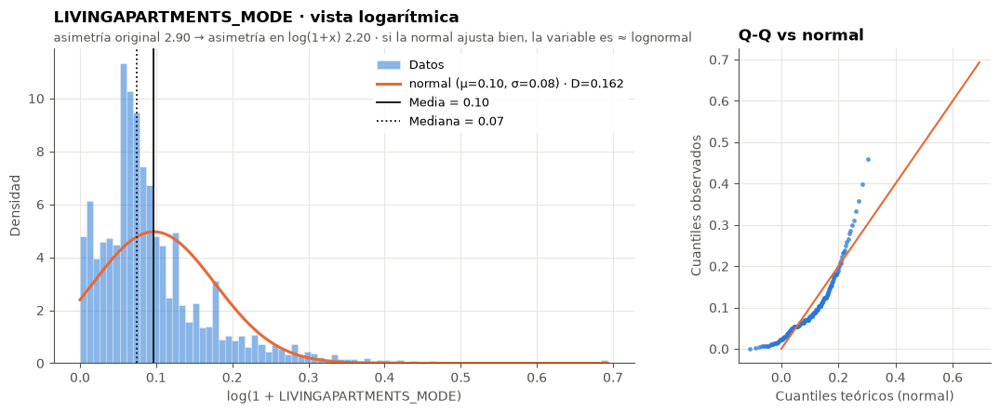

#### `LIVINGAREA_MODE`

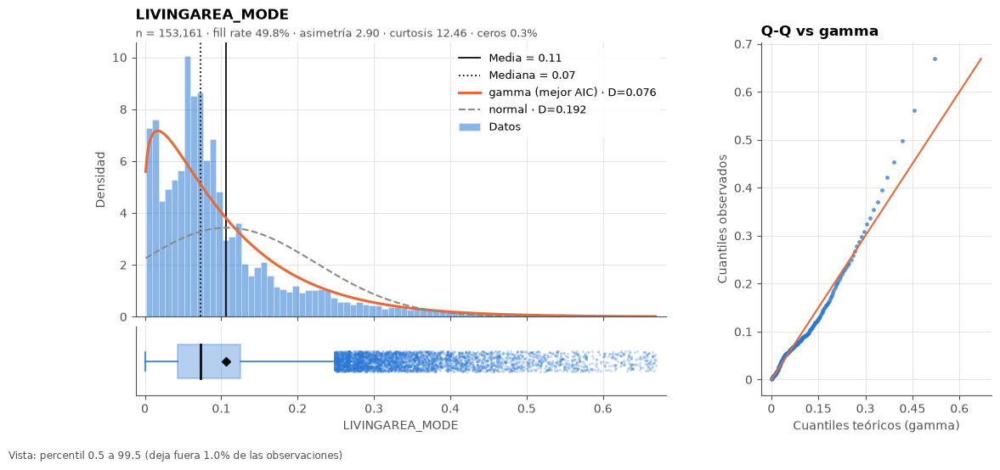

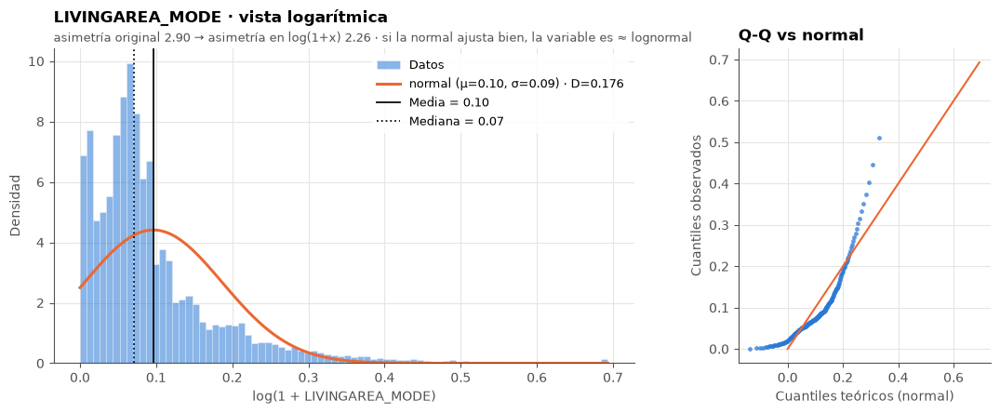

#### `NONLIVINGAPARTMENTS_MODE`

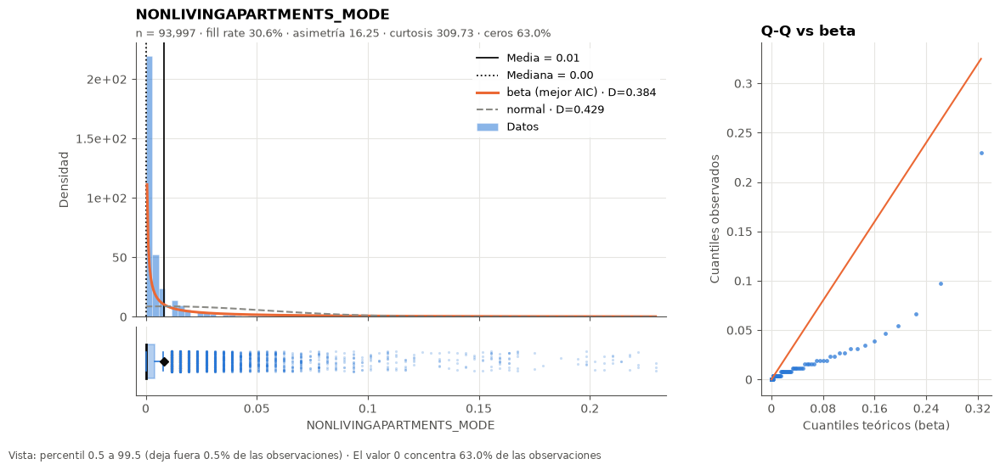

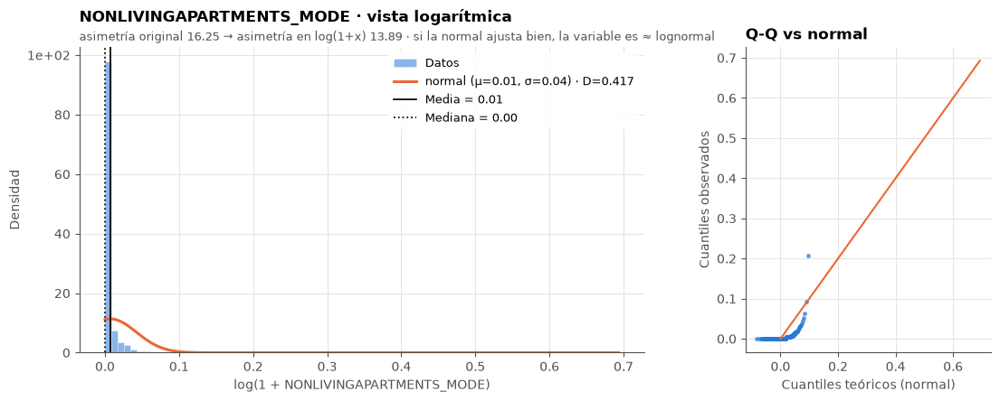

#### `NONLIVINGAREA_MODE`

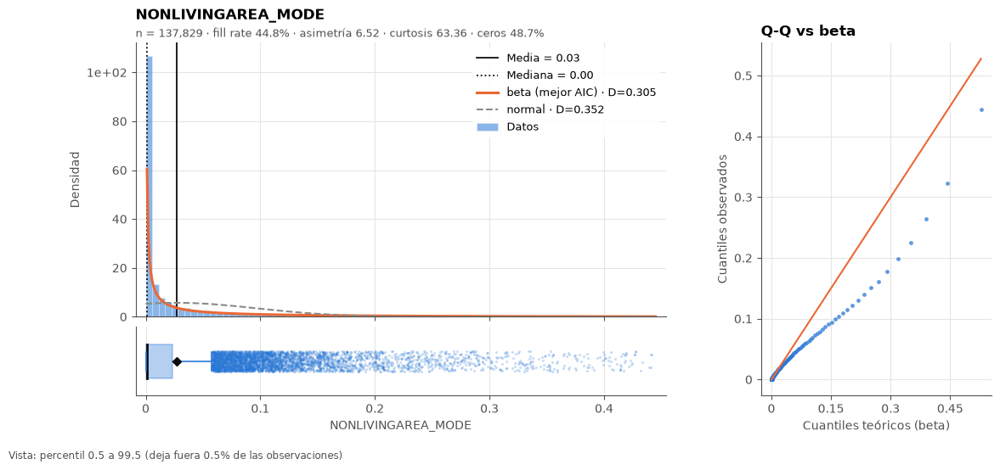

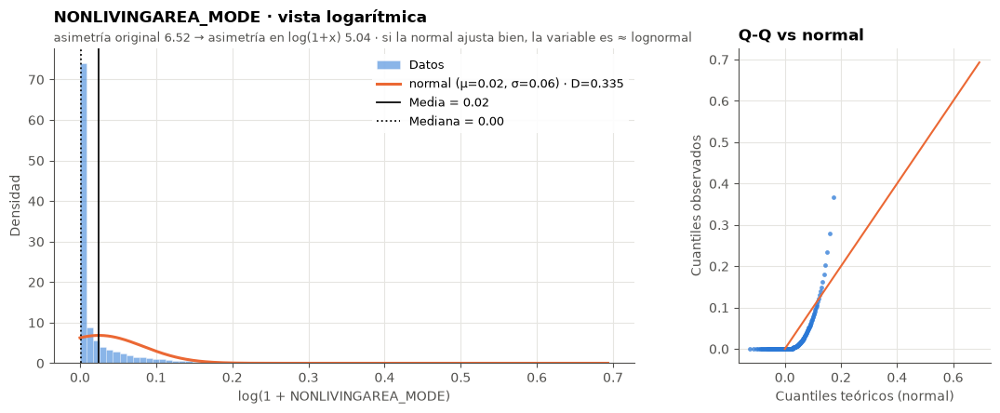

#### `APARTMENTS_MEDI`

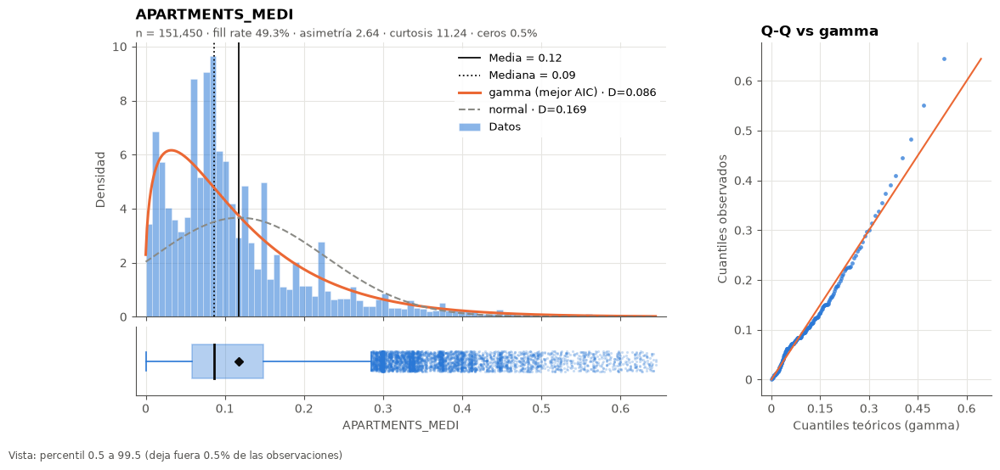

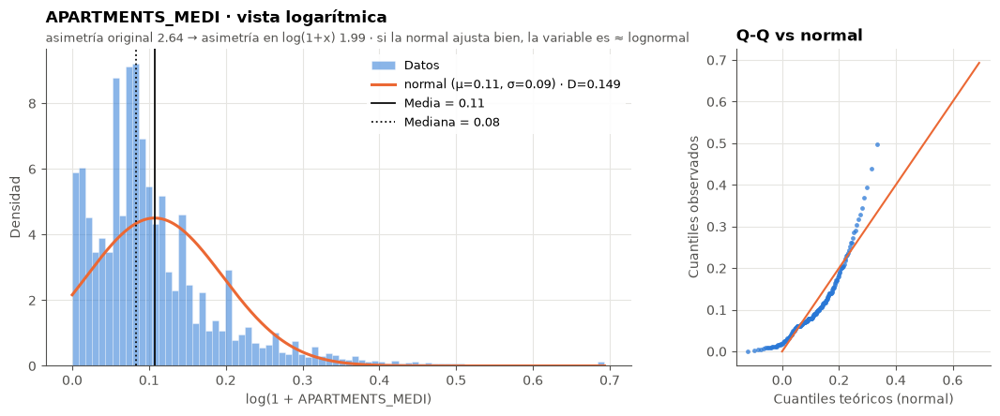

#### `BASEMENTAREA_MEDI`

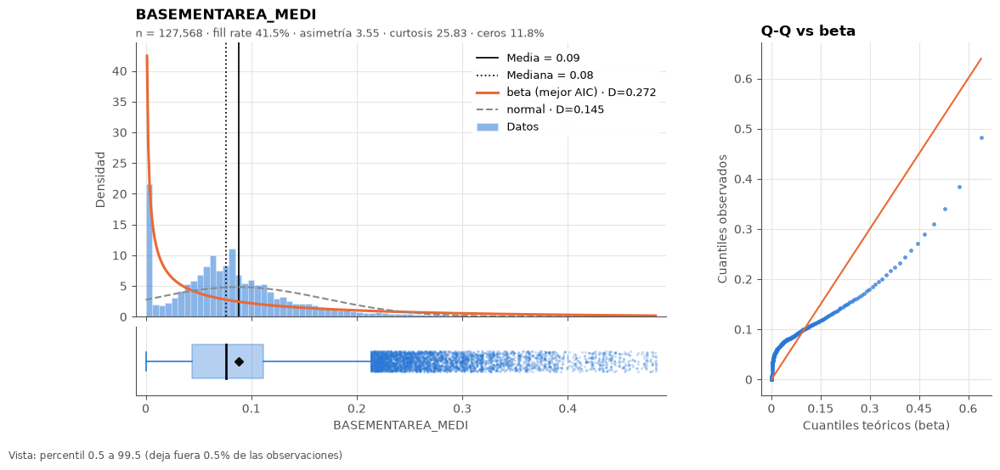

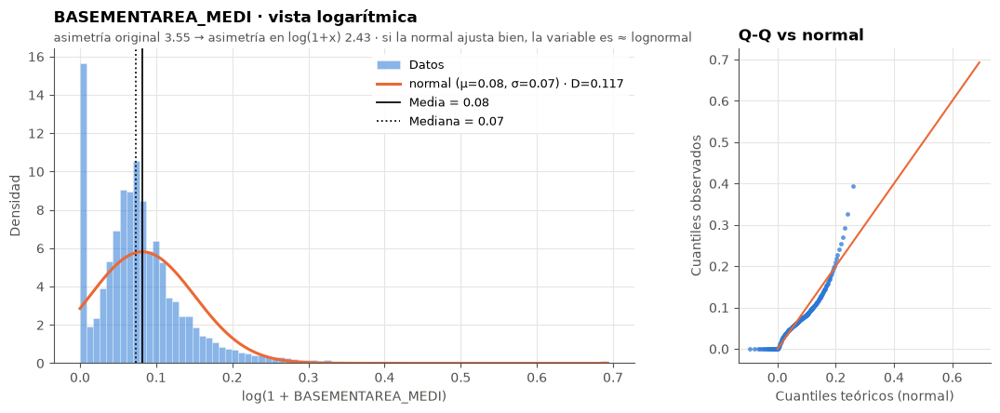

#### `YEARS_BEGINEXPLUATATION_MEDI`

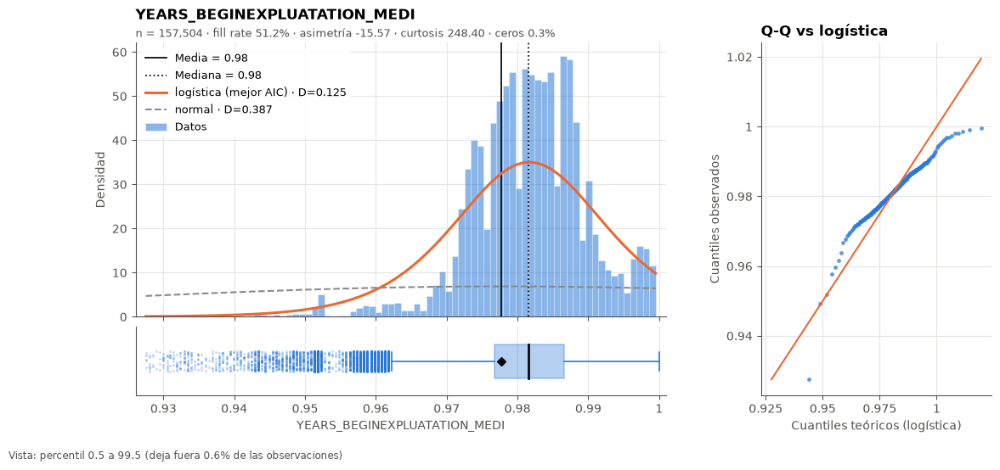

#### `YEARS_BUILD_MEDI`

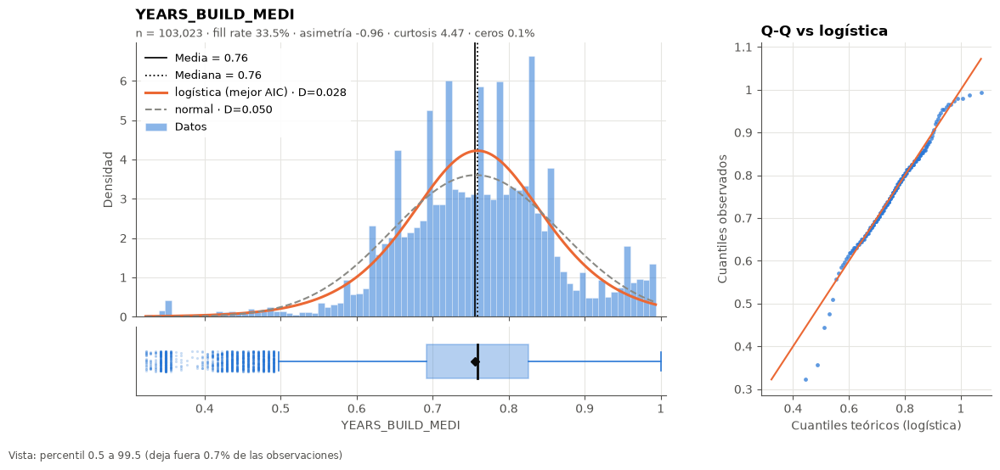

#### `COMMONAREA_MEDI`

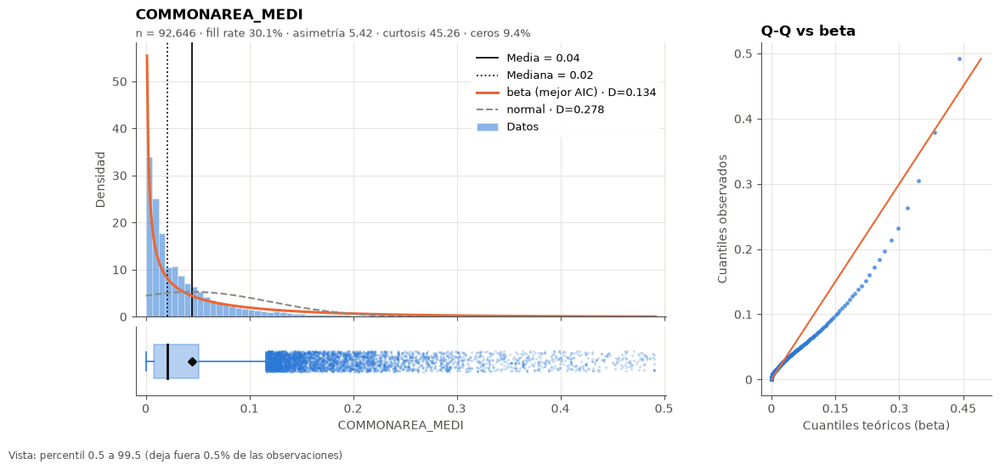

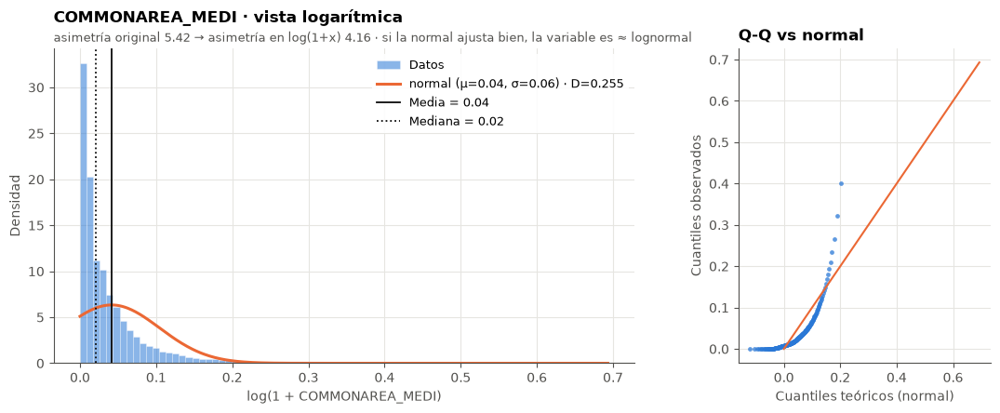

#### `ELEVATORS_MEDI`

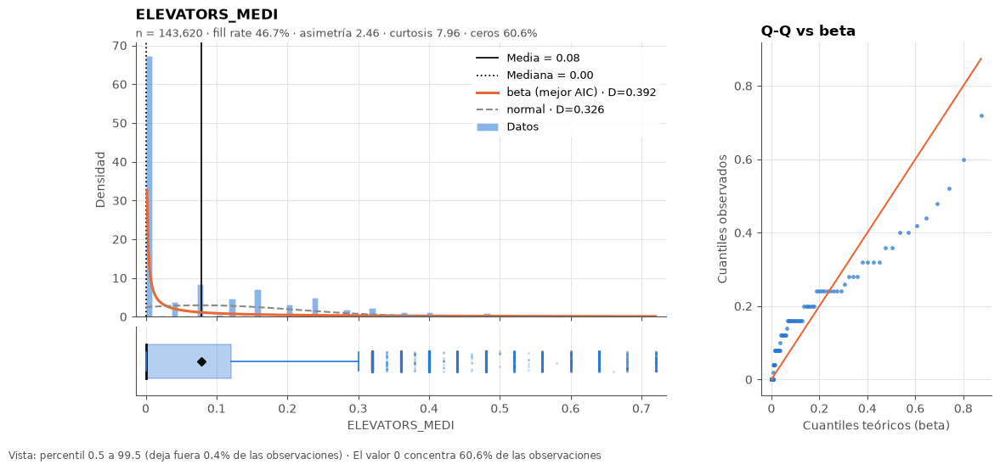

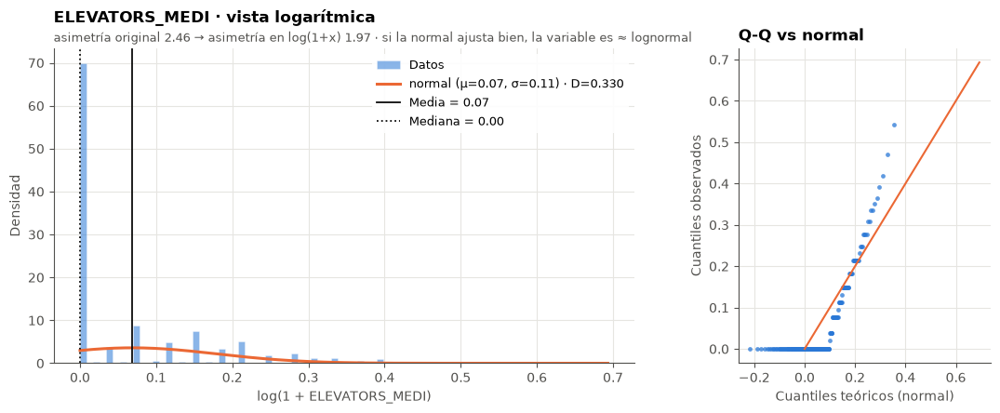

#### `ENTRANCES_MEDI`

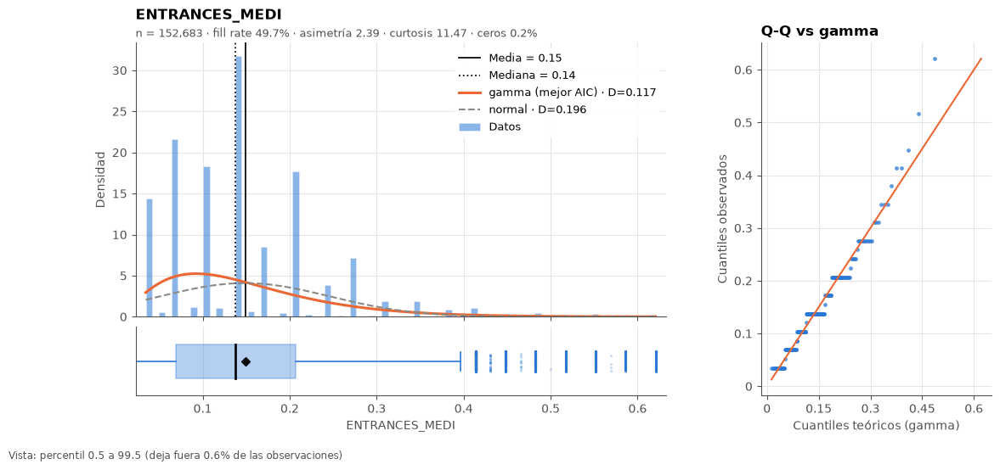

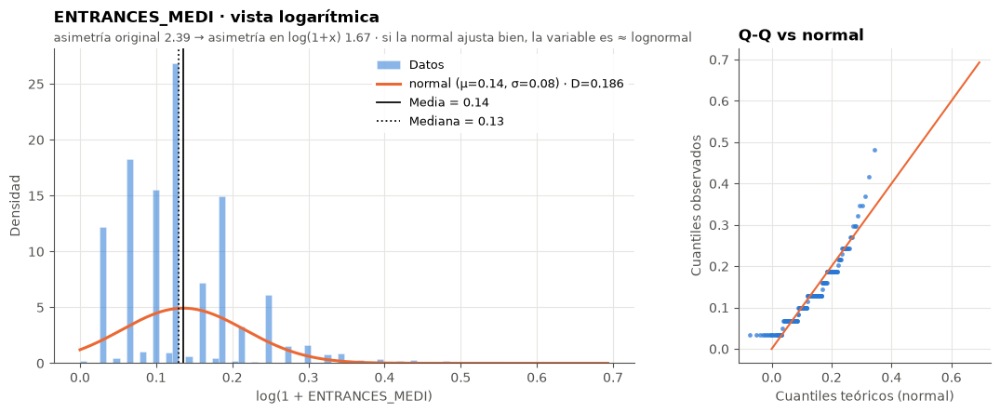

#### `FLOORSMAX_MEDI`

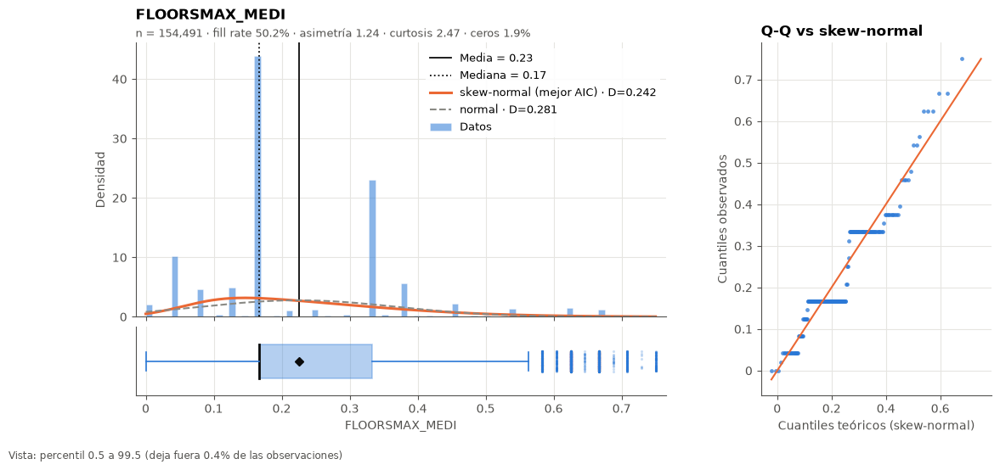

#### `FLOORSMIN_MEDI`

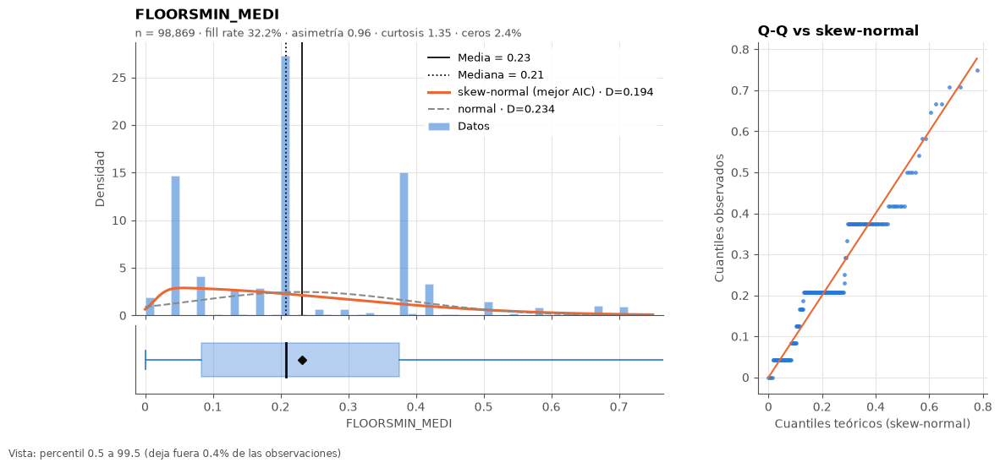

#### `LANDAREA_MEDI`

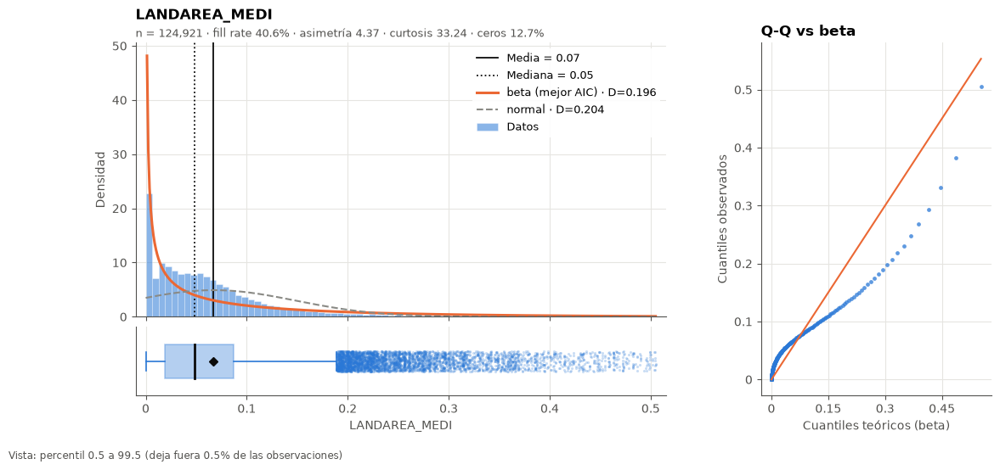

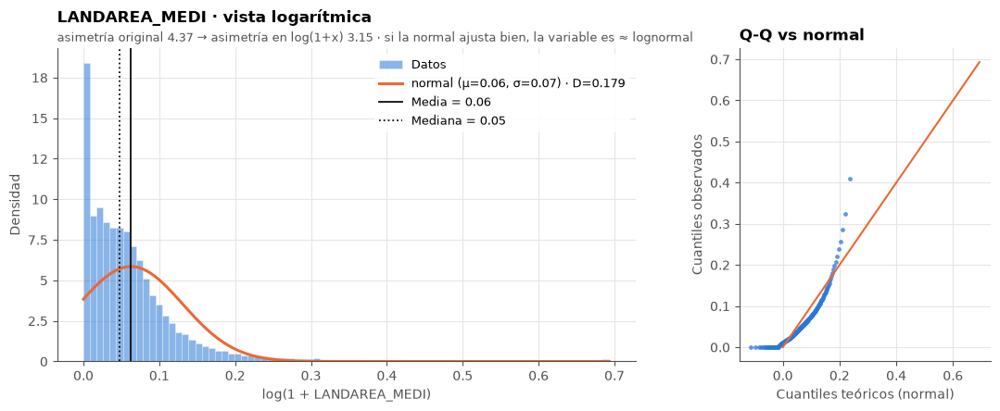

#### `LIVINGAPARTMENTS_MEDI`

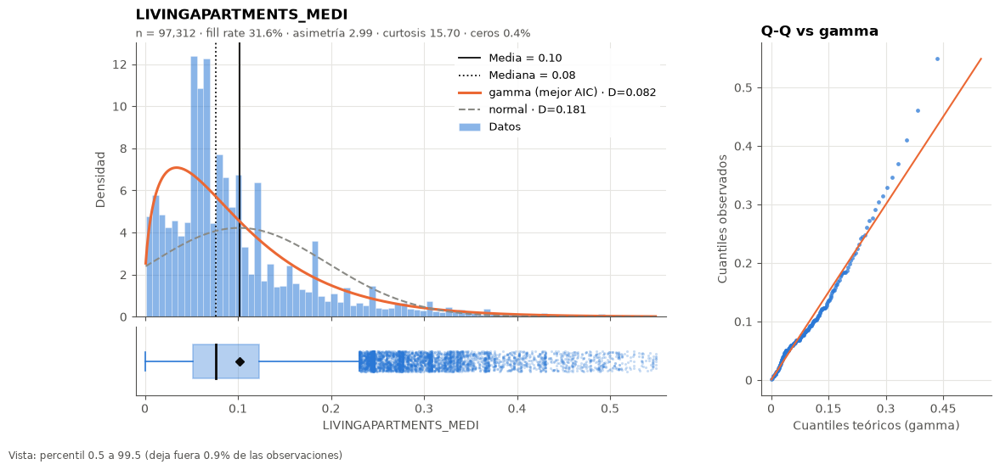

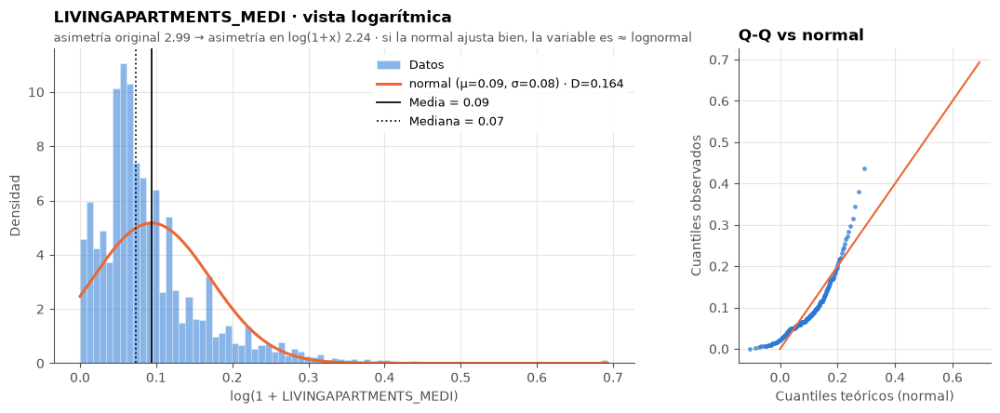

#### `LIVINGAREA_MEDI`

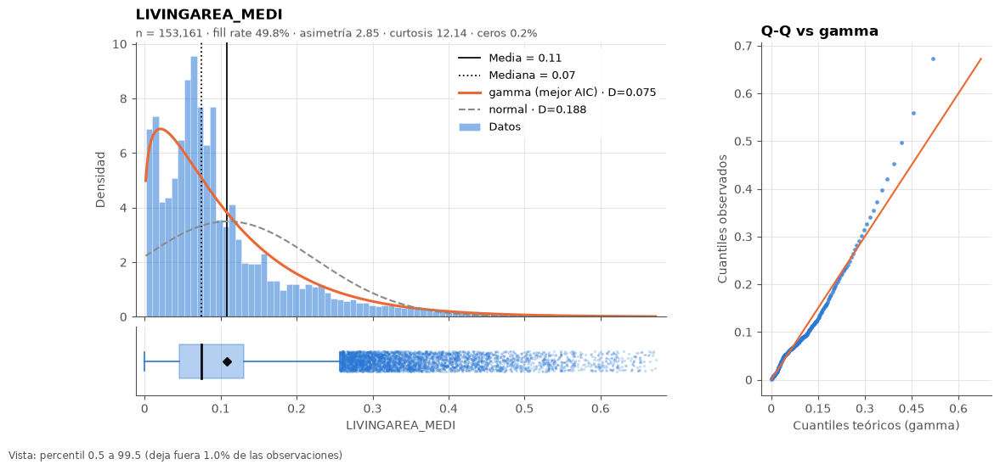

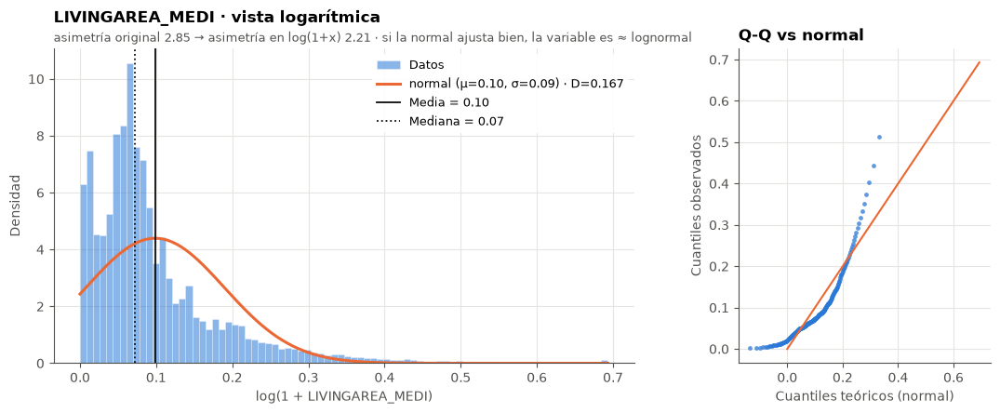

#### `NONLIVINGAPARTMENTS_MEDI`

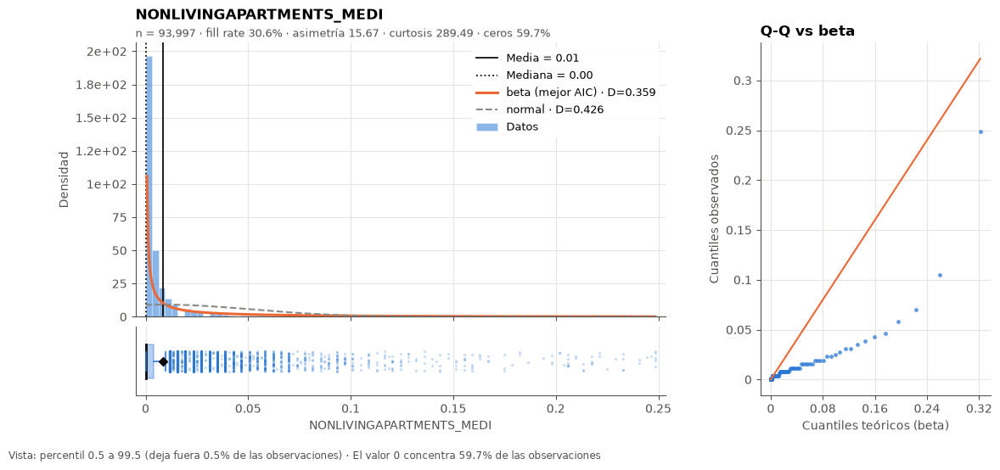

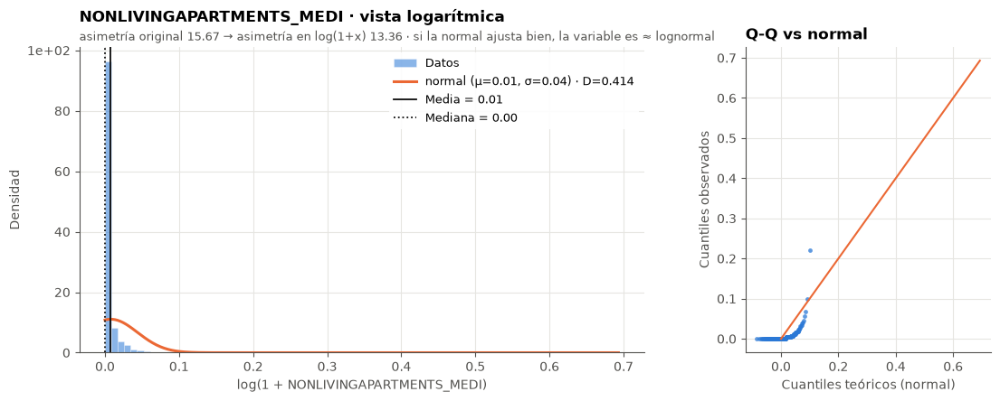

#### `NONLIVINGAREA_MEDI`

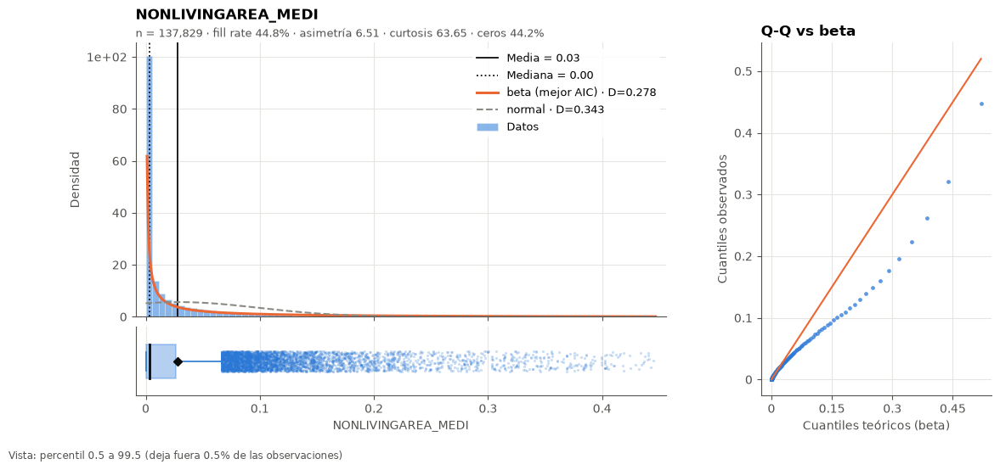

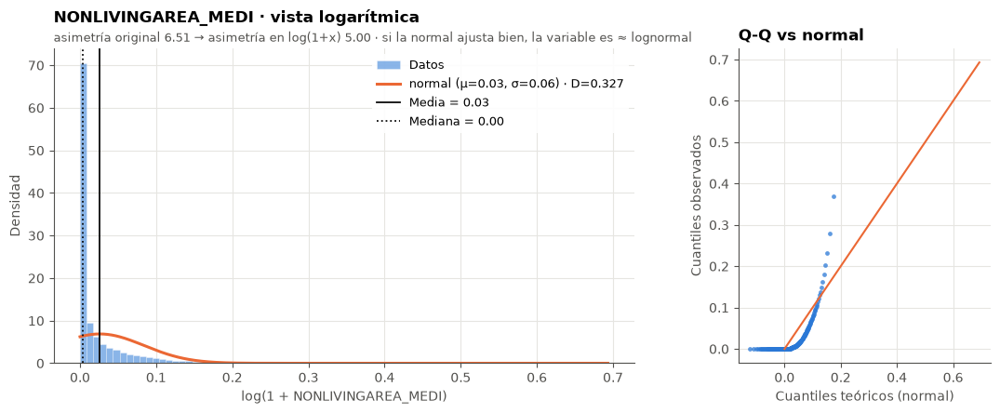

#### `TOTALAREA_MODE`

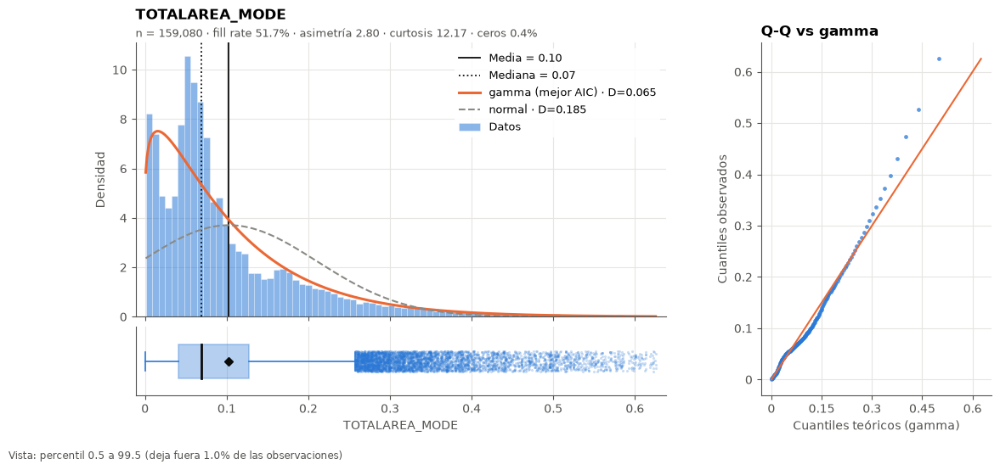

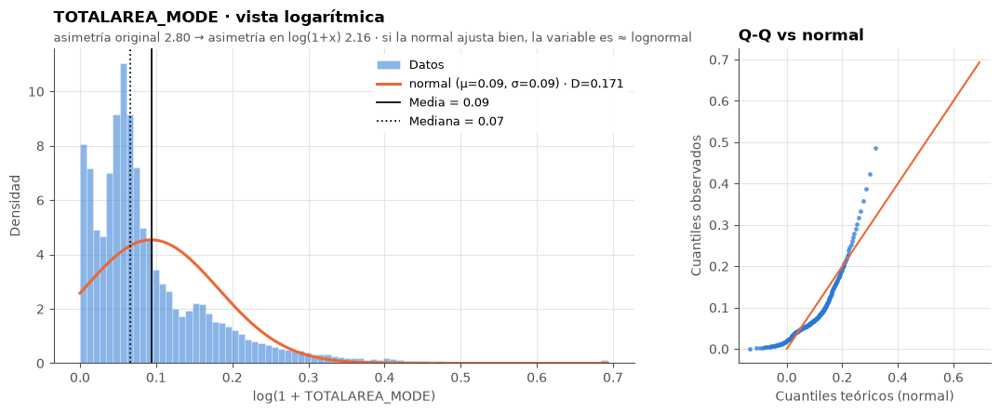

#### `OBS_30_CNT_SOCIAL_CIRCLE`

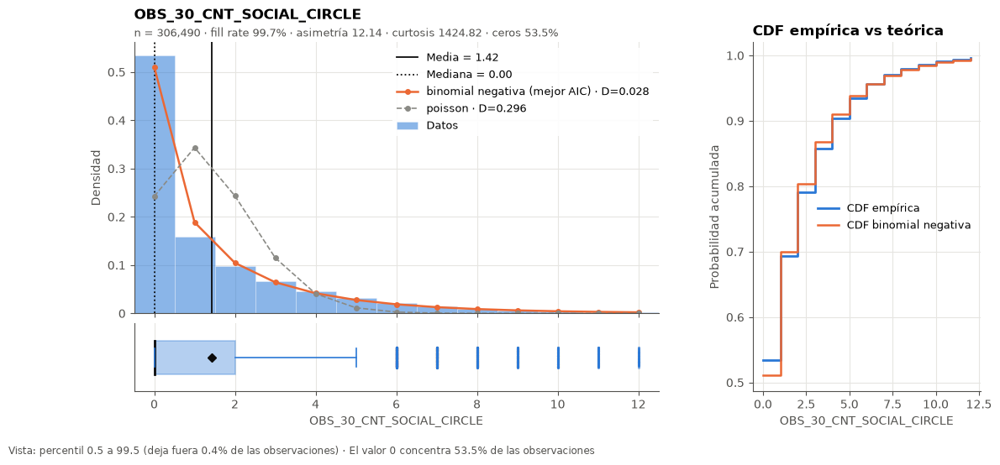

#### `DEF_30_CNT_SOCIAL_CIRCLE`

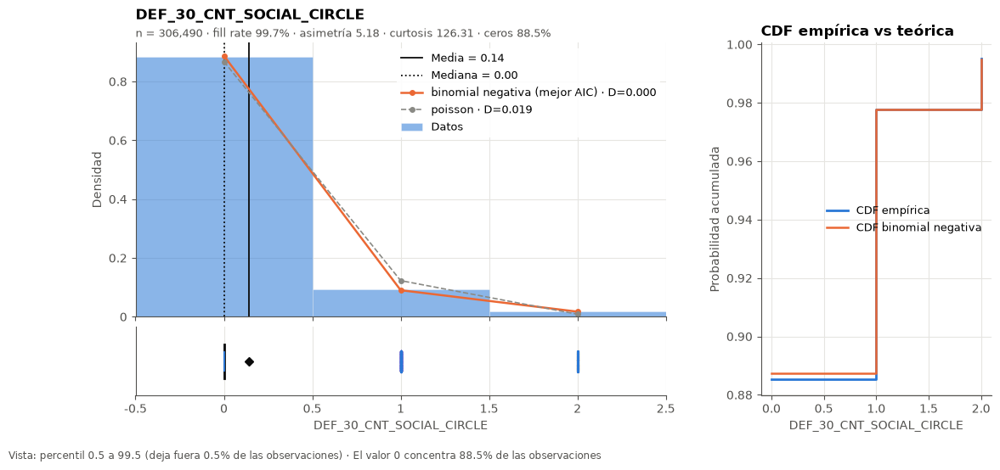

#### `OBS_60_CNT_SOCIAL_CIRCLE`

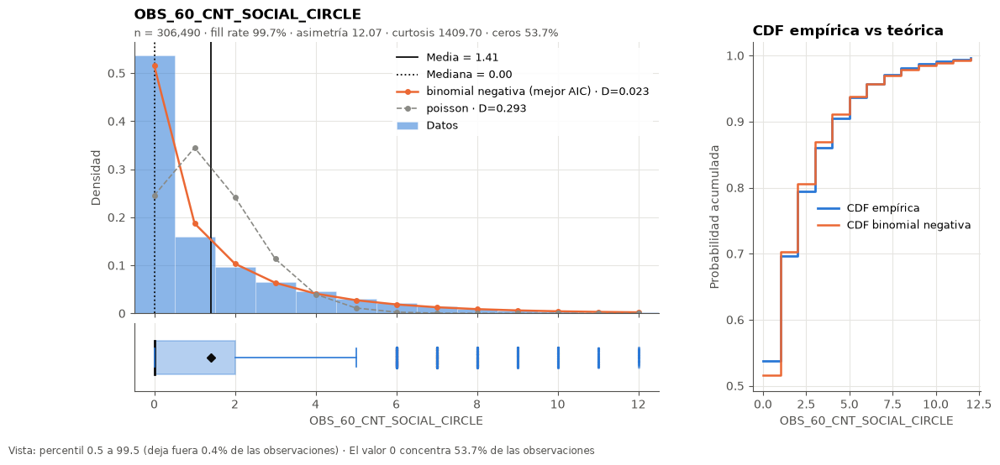

#### `DEF_60_CNT_SOCIAL_CIRCLE`

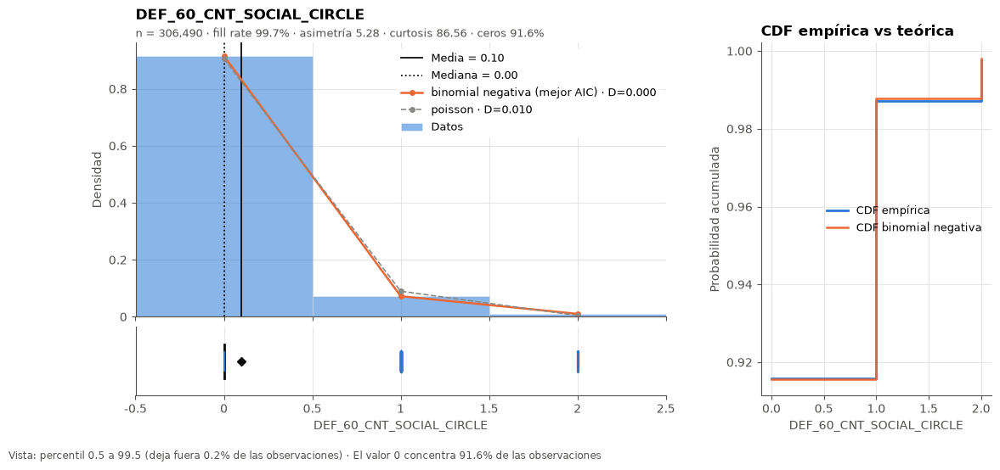

#### `DAYS_LAST_PHONE_CHANGE`

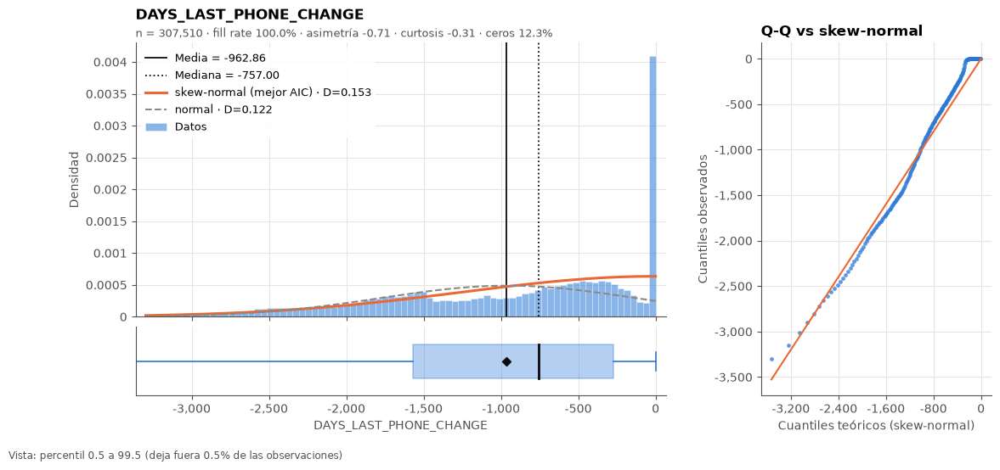

#### `AMT_REQ_CREDIT_BUREAU_HOUR`

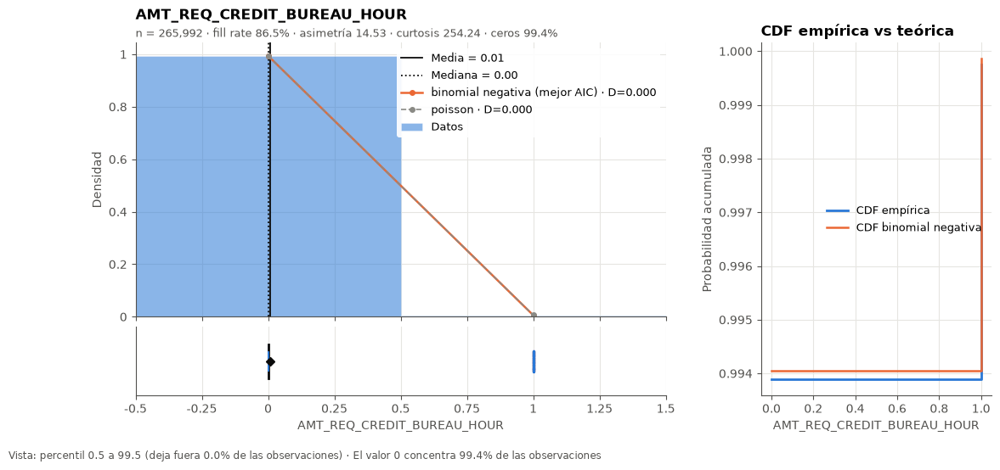

#### `AMT_REQ_CREDIT_BUREAU_DAY`

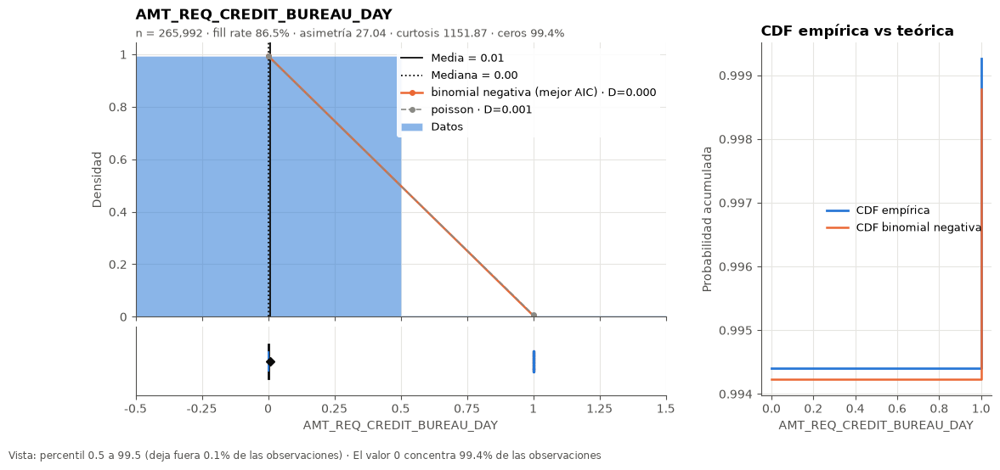

#### `AMT_REQ_CREDIT_BUREAU_WEEK`

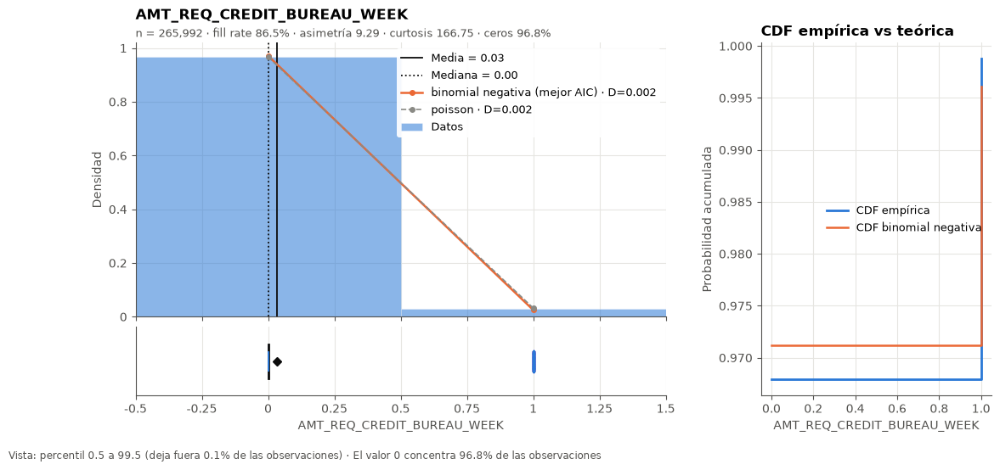

#### `AMT_REQ_CREDIT_BUREAU_MON`

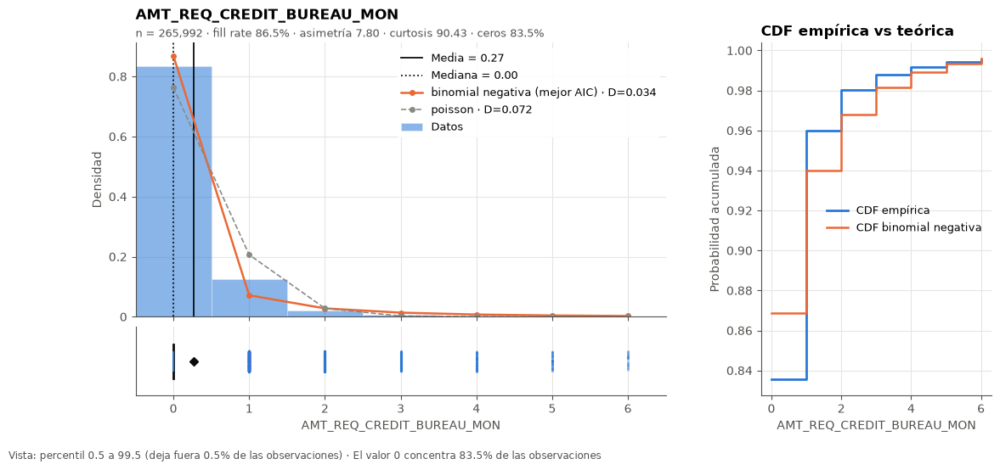

#### `AMT_REQ_CREDIT_BUREAU_QRT`

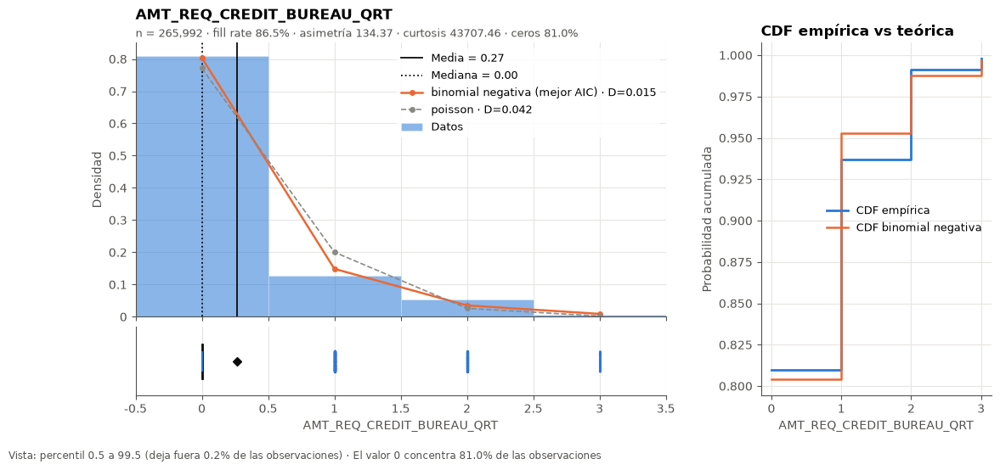

#### `AMT_REQ_CREDIT_BUREAU_YEAR`

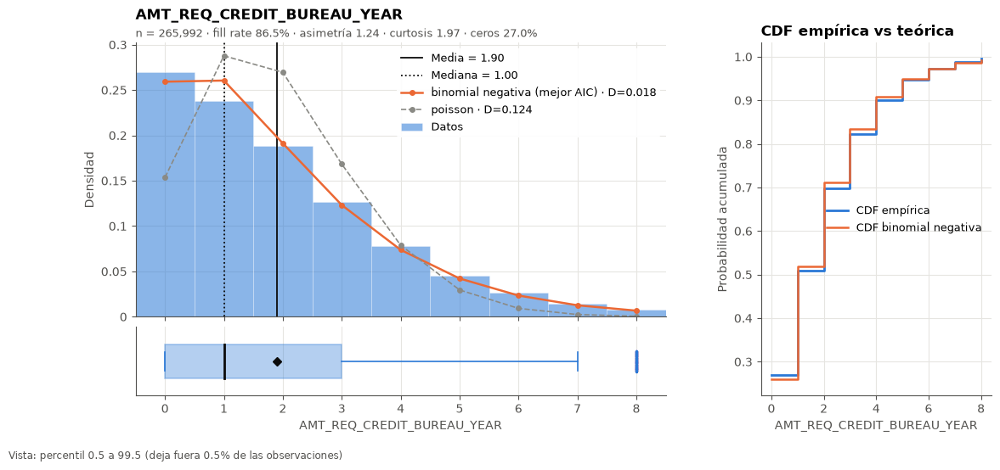

#### `BUREAU_N_CREDITOS`

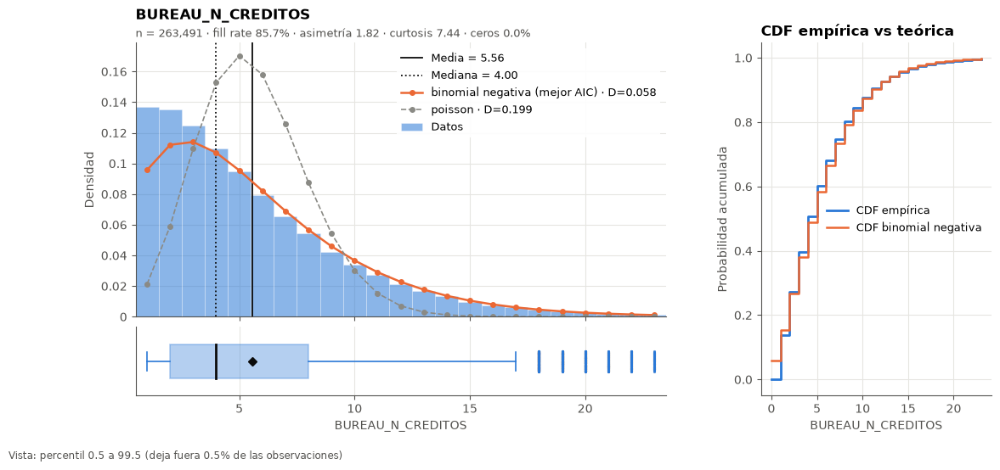

#### `BUREAU_N_ACTIVOS`

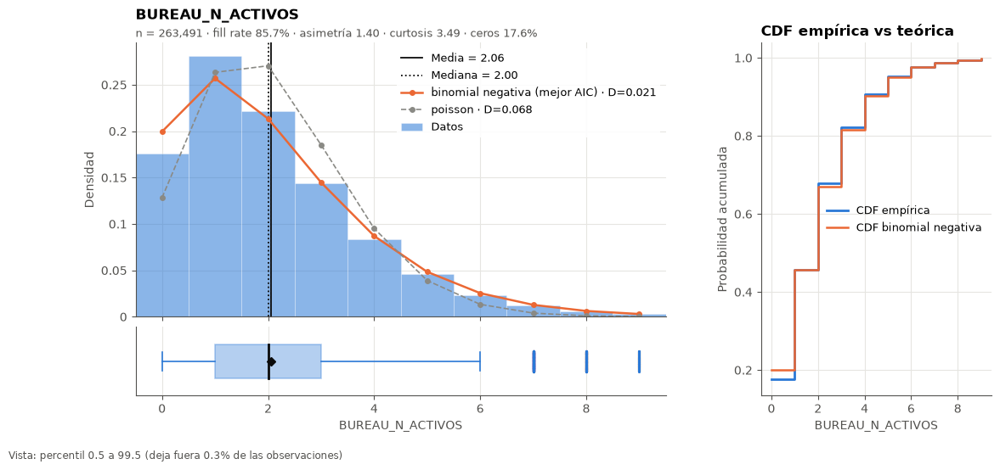

#### `BUREAU_DEUDA_TOTAL`

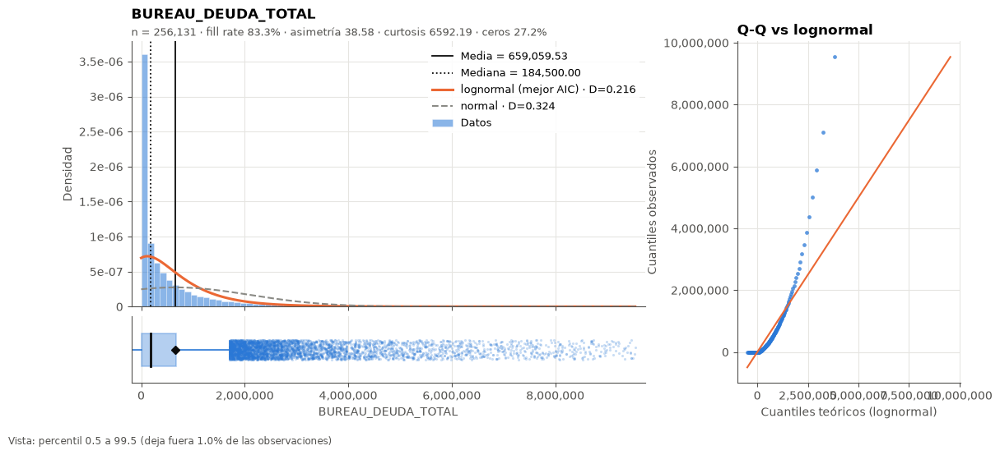

#### `BUREAU_MAX_DIAS_ATRASO`

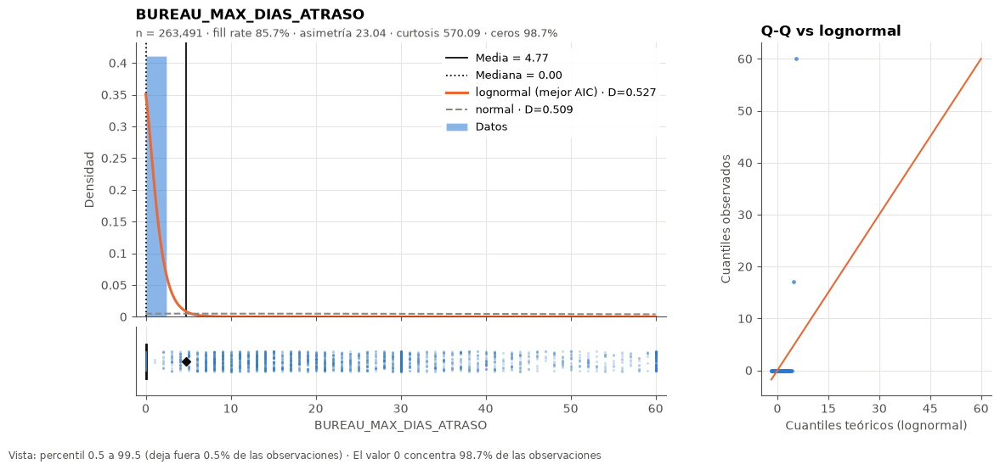

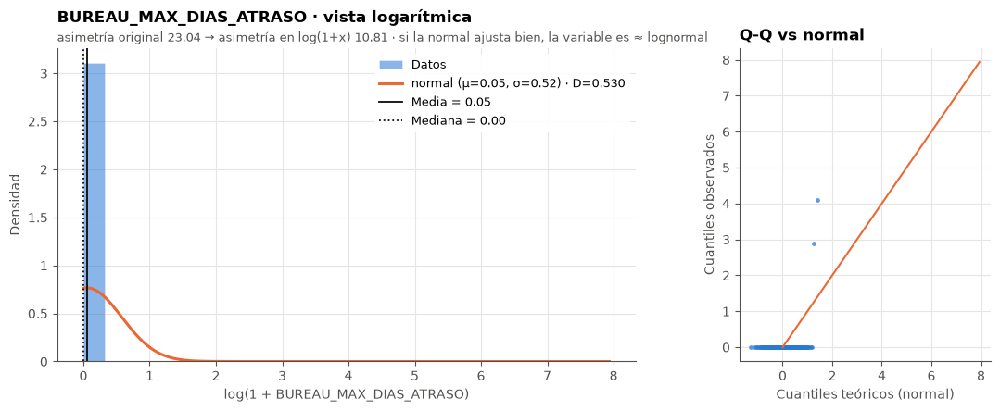

#### `BUREAU_MESES_OBSERVADOS`

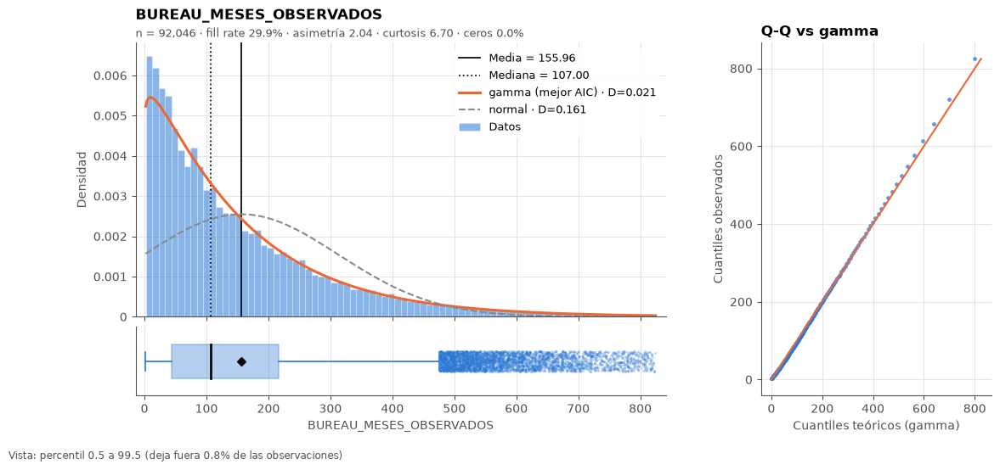

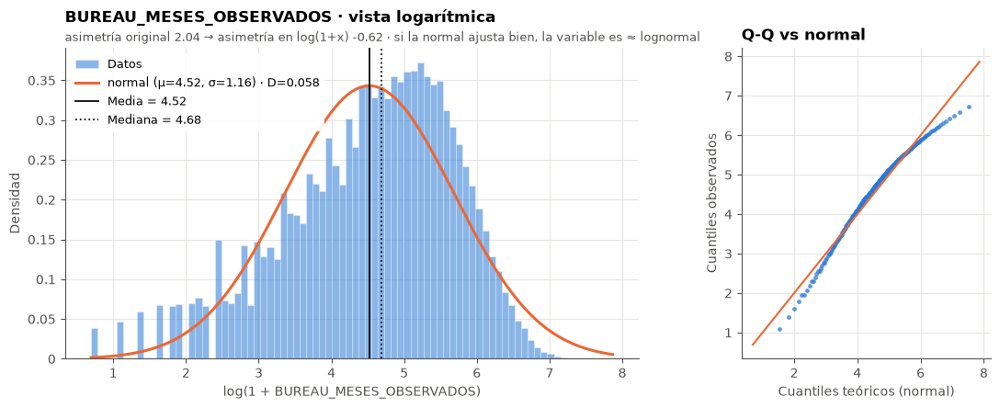

#### `BUREAU_MESES_CON_ATRASO`

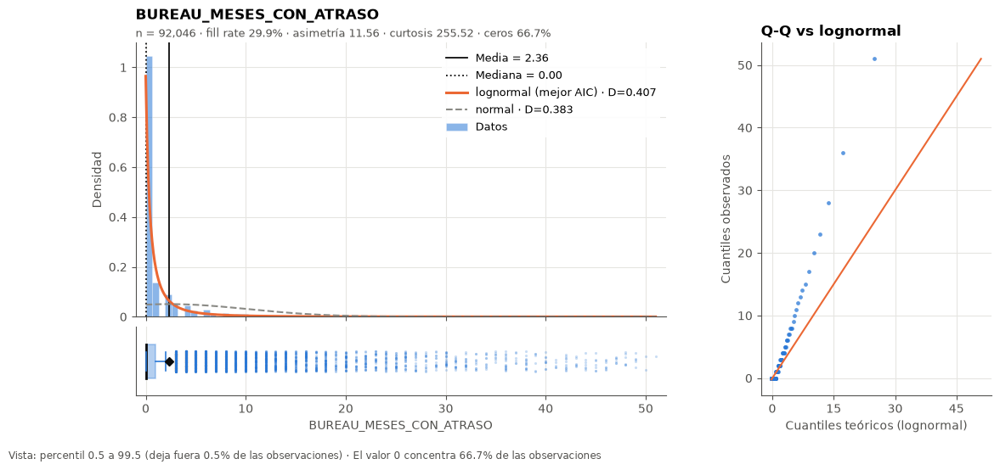

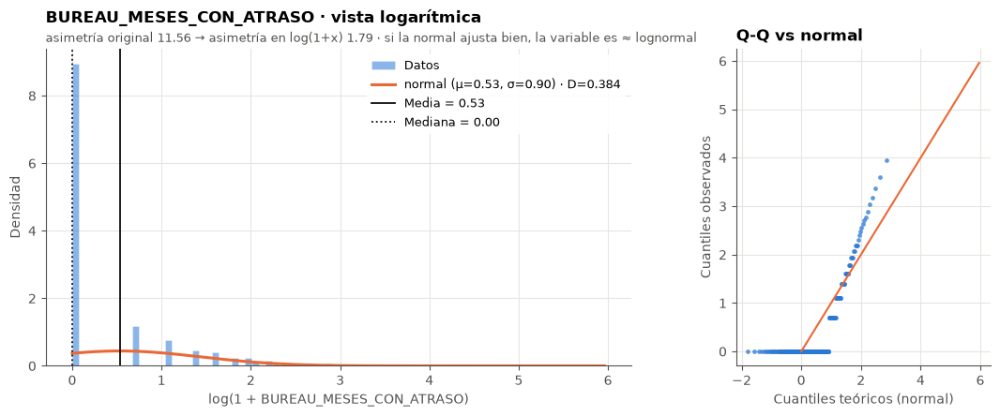

#### `BUREAU_MESES_ESTADO_CONOCIDO`

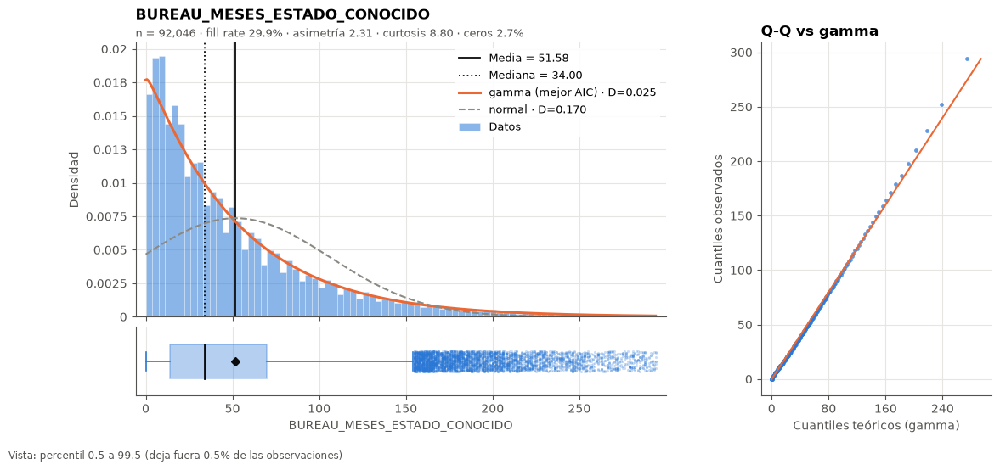

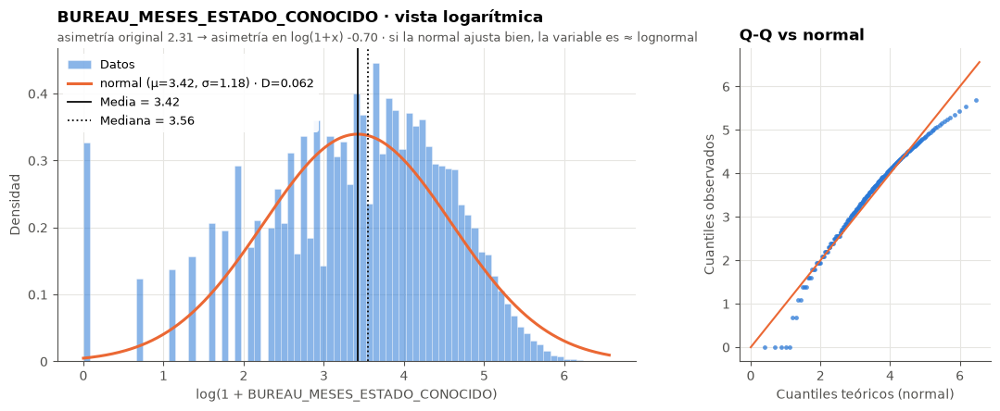

#### `BUREAU_PROP_MESES_CON_ATRASO`

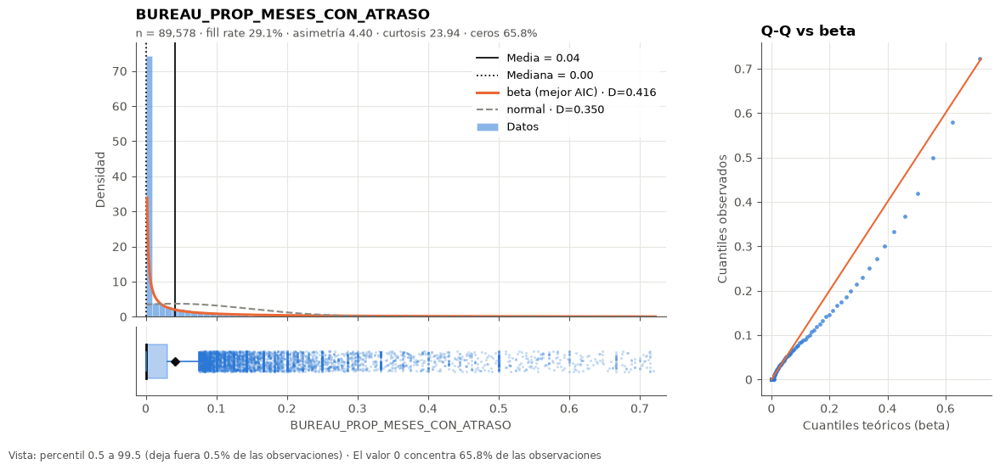

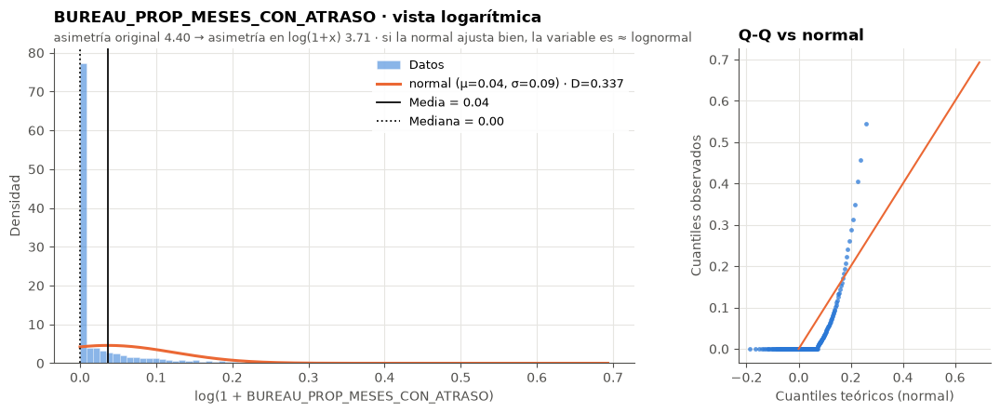

#### `HC_N_SOLICITUDES`

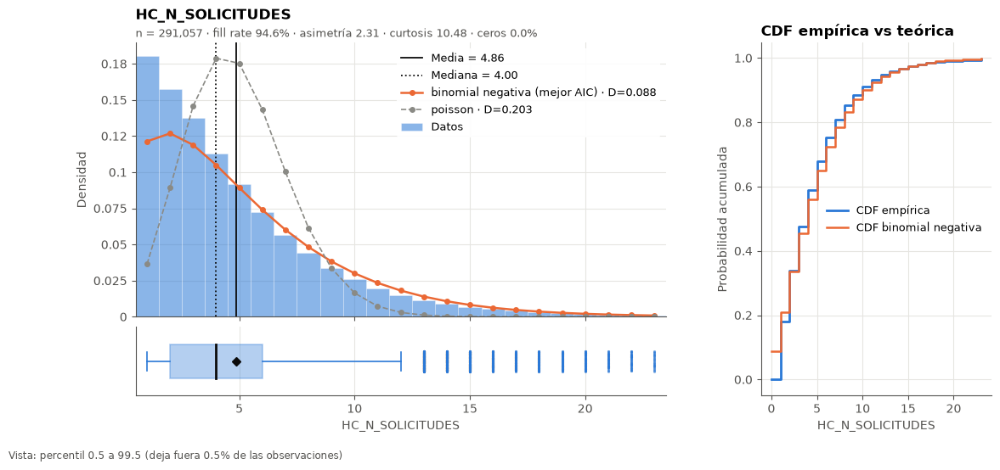

#### `HC_N_APROBADAS`

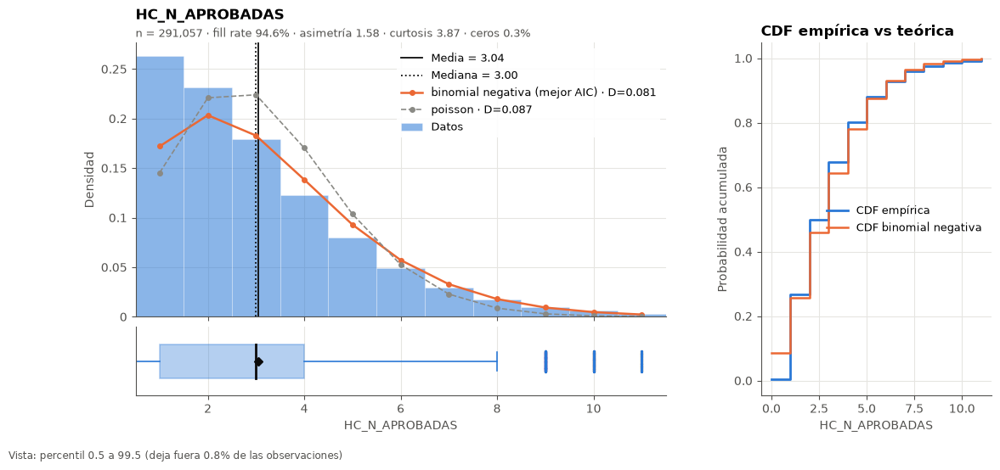

#### `HC_N_RECHAZADAS`

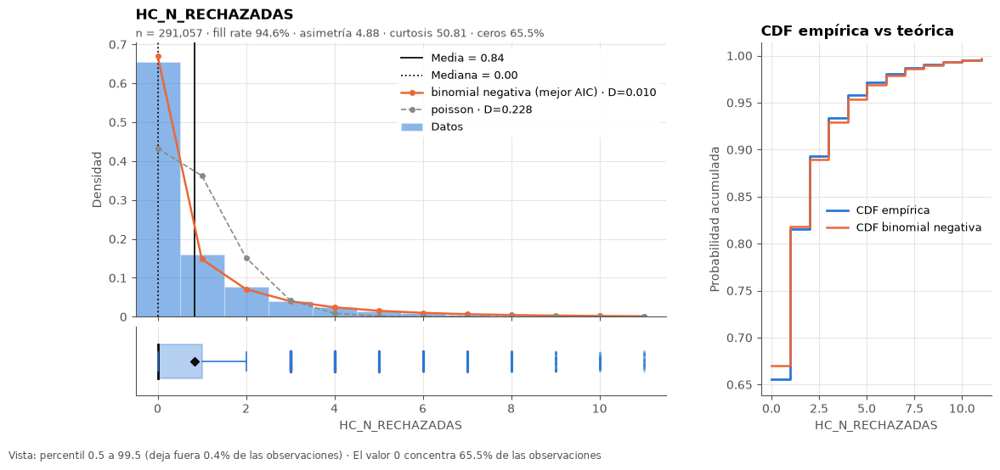

#### `HC_DIAS_ULTIMA_DECISION`

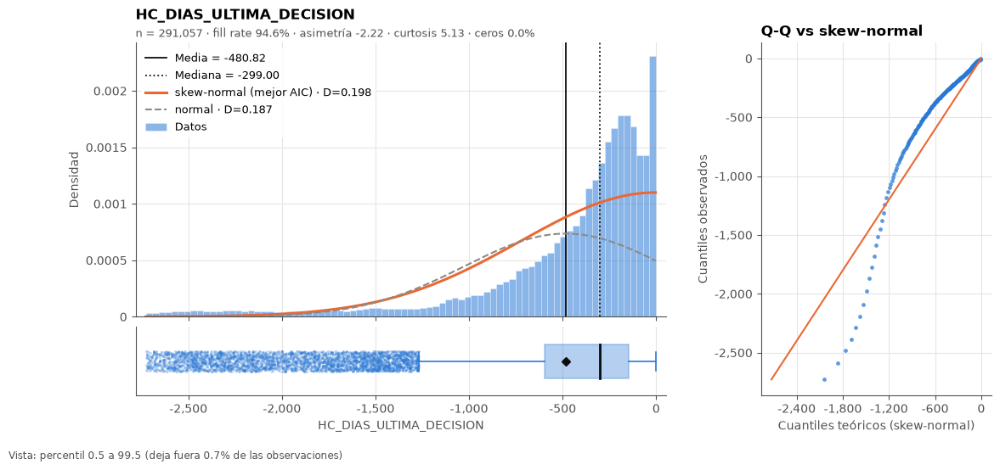

#### `HC_PROP_SOLICITUDES_RECHAZADAS`

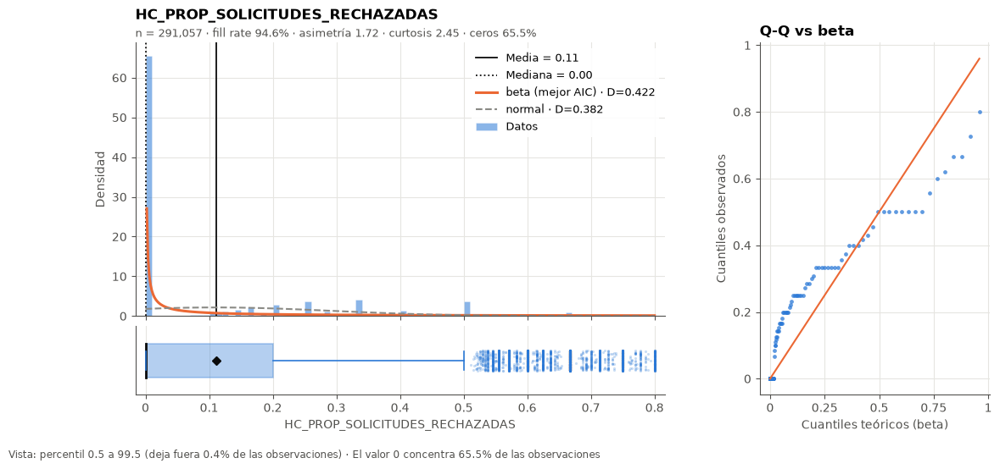

#### `HC_N_OPERACIONES_POS`

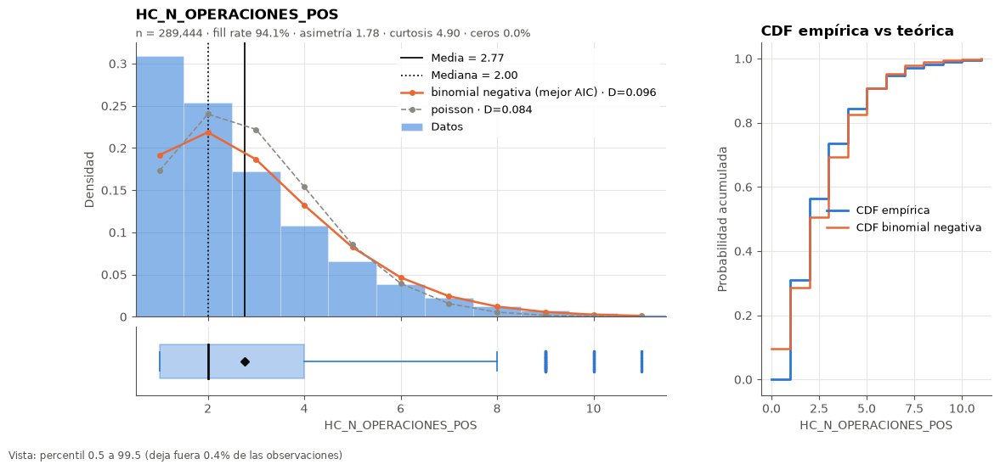

#### `HC_POS_MAX_ATRASO`

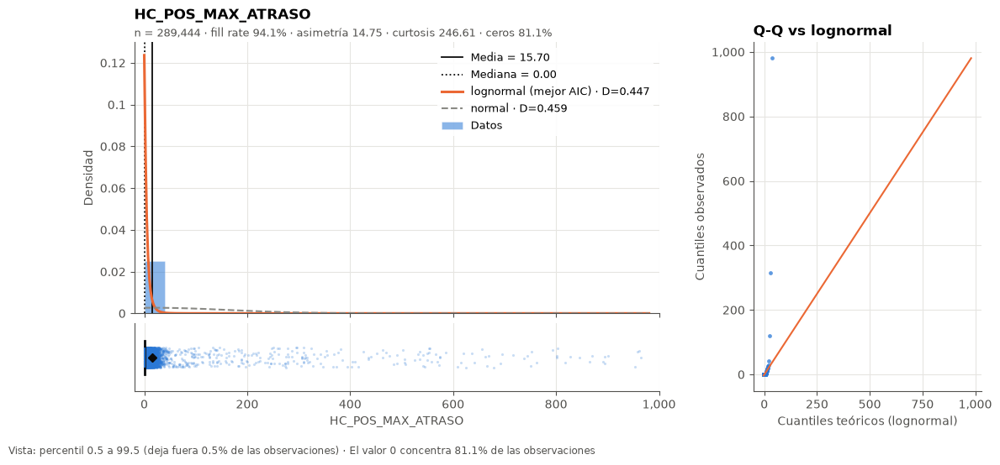

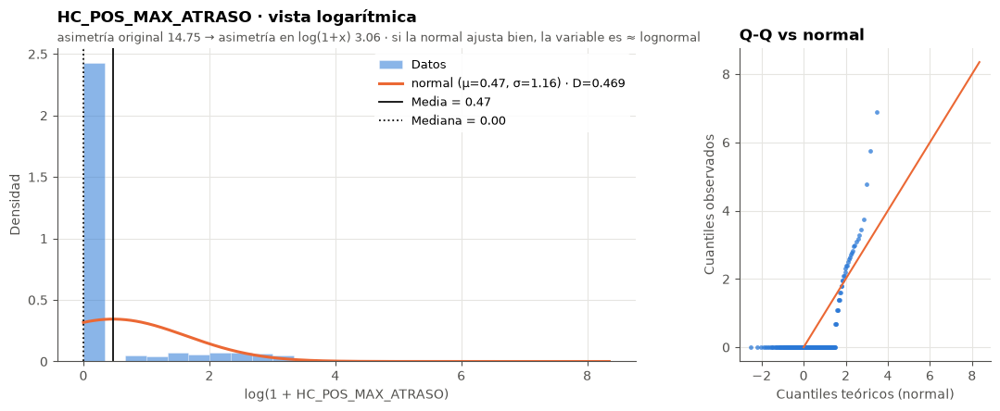

#### `HC_POS_MAX_CUOTAS_PENDIENTES`

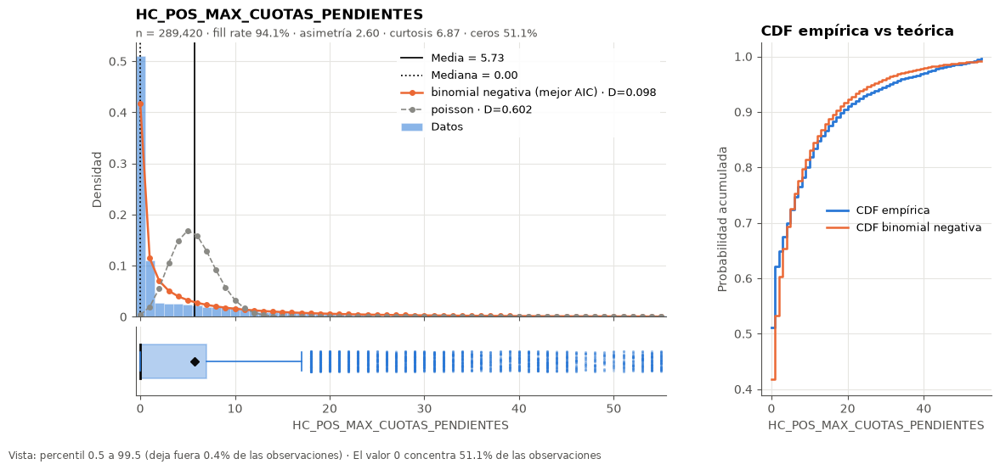

#### `HC_CARD_MAX_ATRASO`

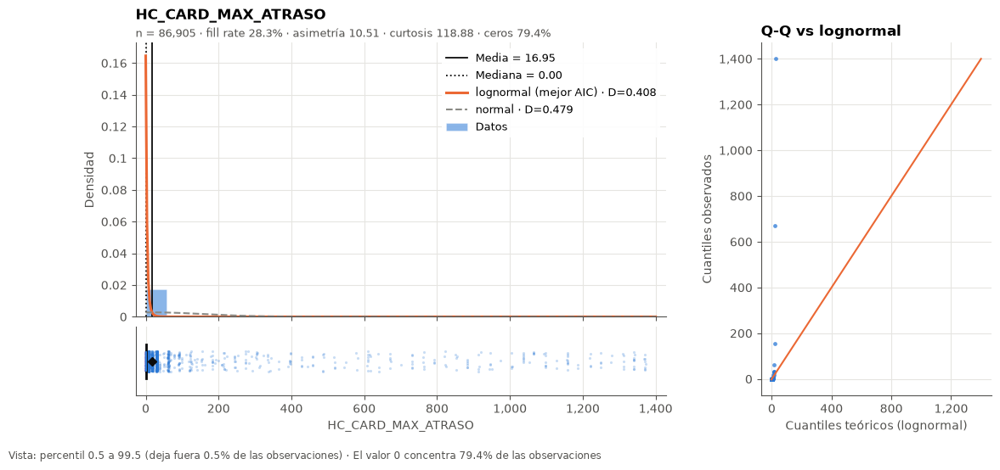

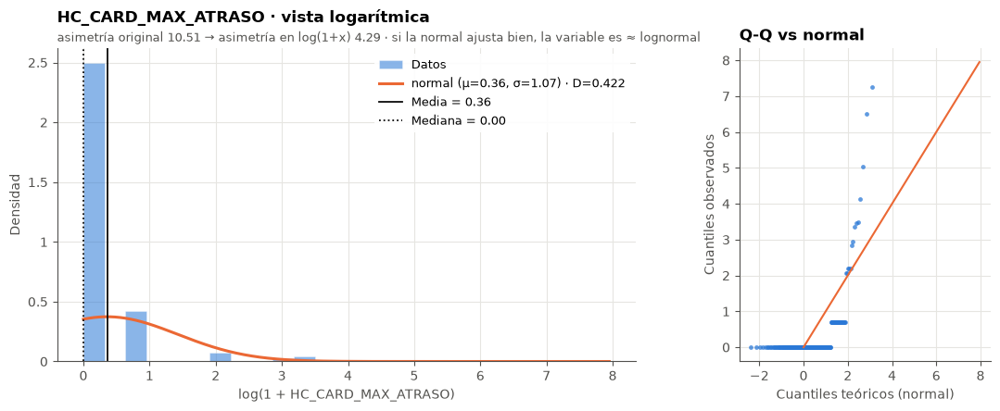

#### `HC_CARD_MAX_UTILIZACION`

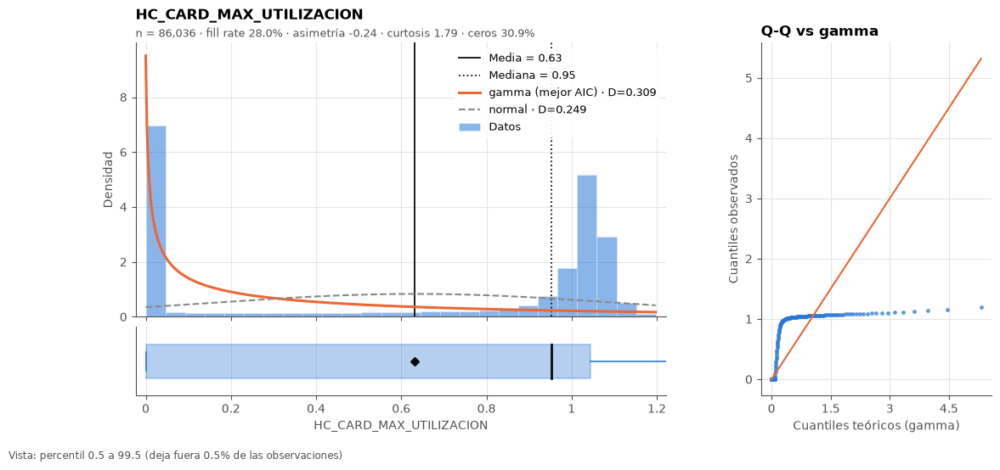

#### `HC_CARD_MAX_ULTIMO_SALDO`

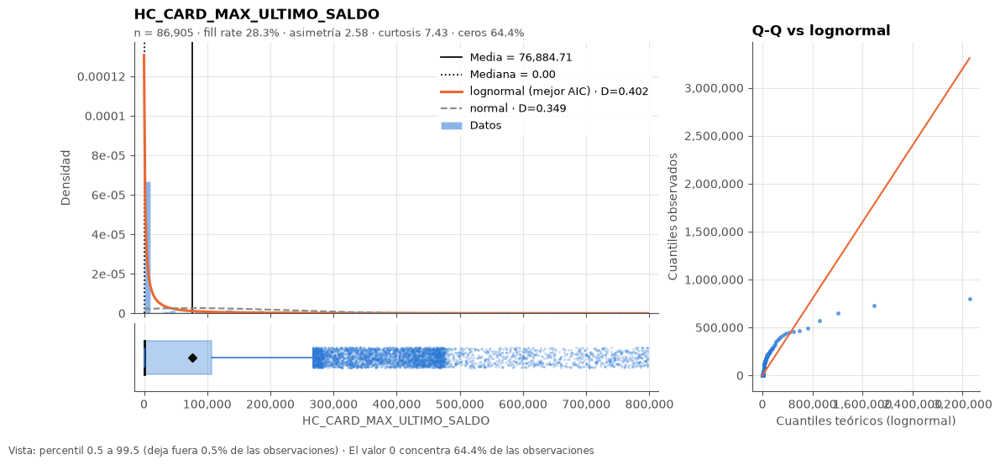

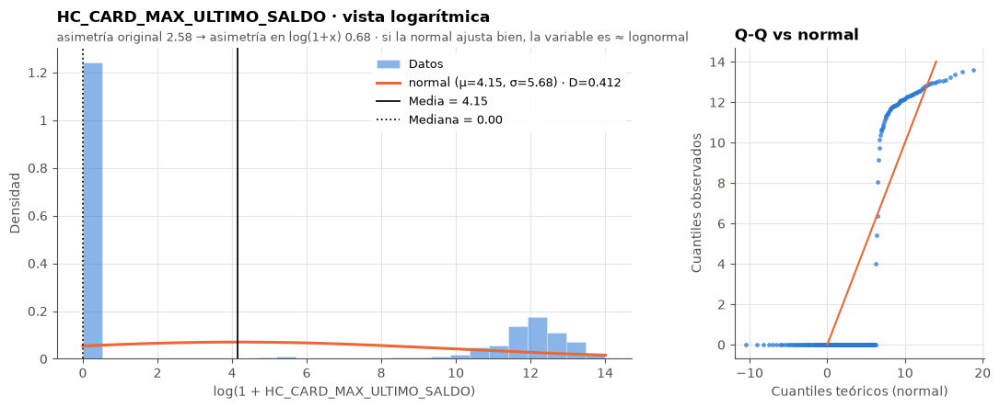

#### `HC_N_REGISTROS_PAGO`

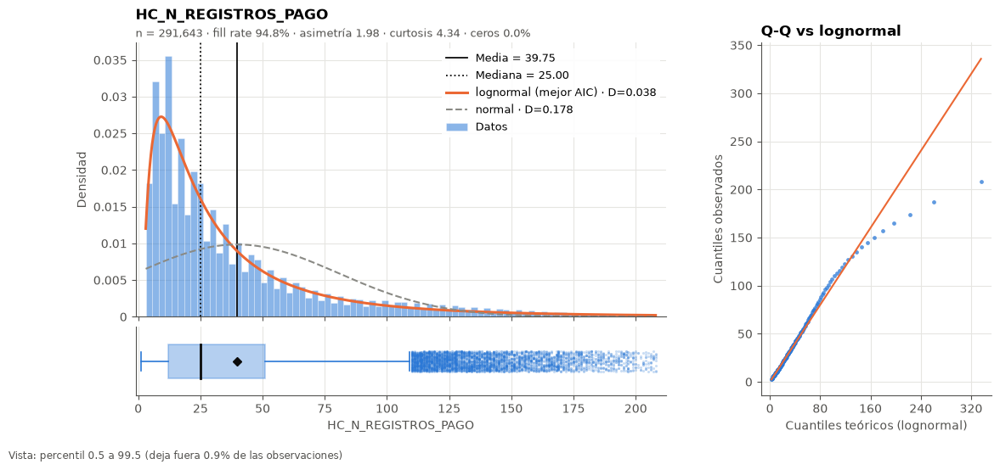

#### `HC_N_PAGOS_TARDE`

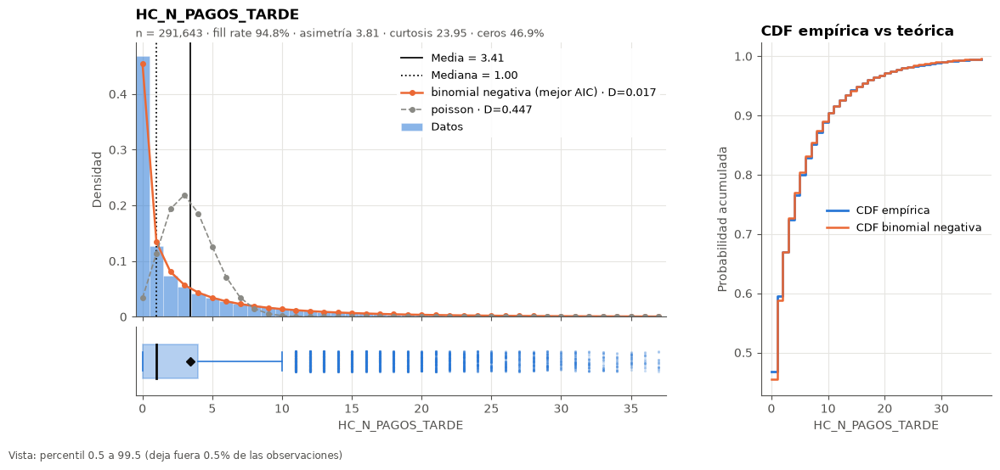

#### `HC_PAY_MAX_ATRASO`

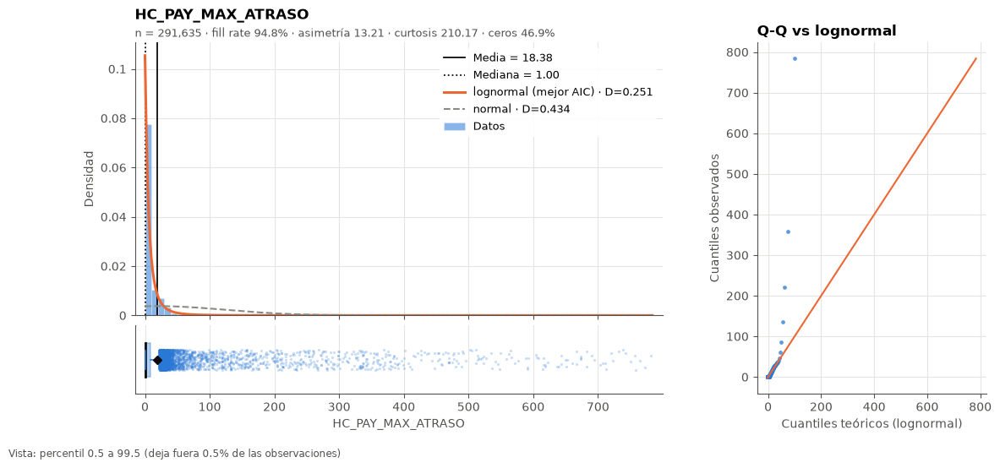

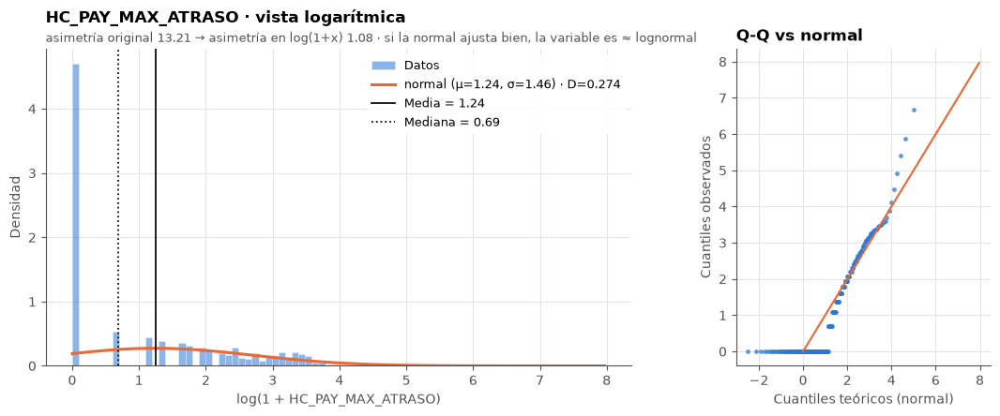

#### `HC_PROP_PAGOS_TARDE`

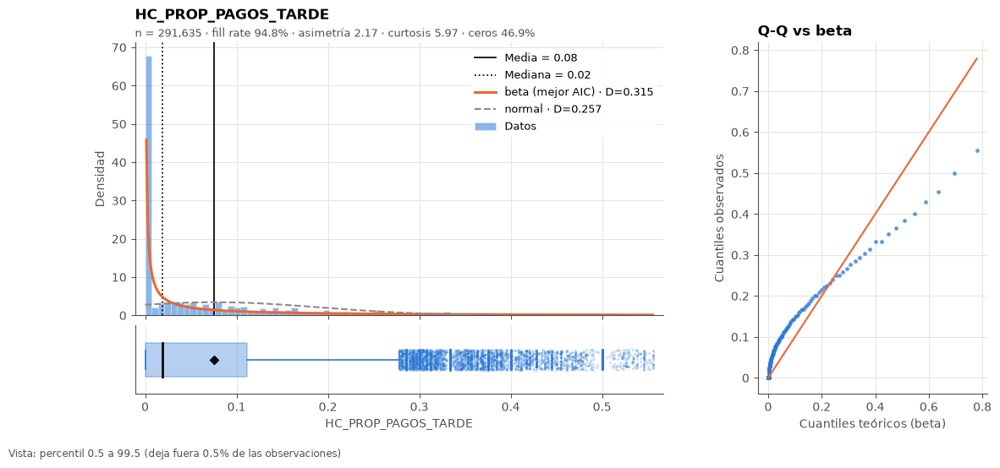

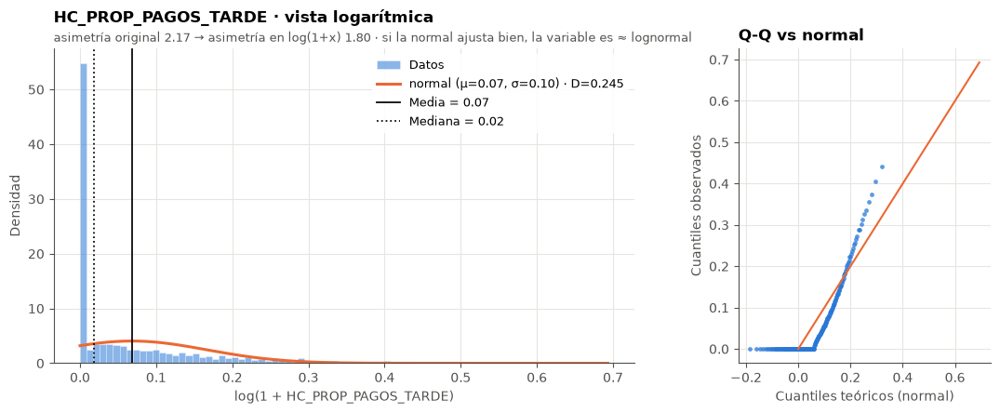

In [37]:
for col in NUMERICAS:
    display(Markdown(f"#### `{col}`"))
    graficar_numerica(col)
    if col in LOG_CANDIDATAS:
        graficar_numerica_log(col)

### 4B) Categóricas: frecuencias y visualización

#### Variable objetivo y dicotómicas

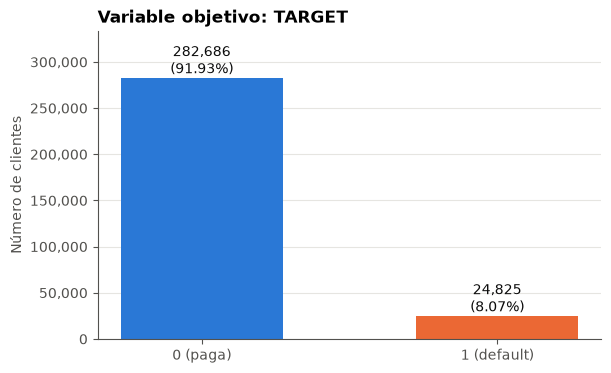

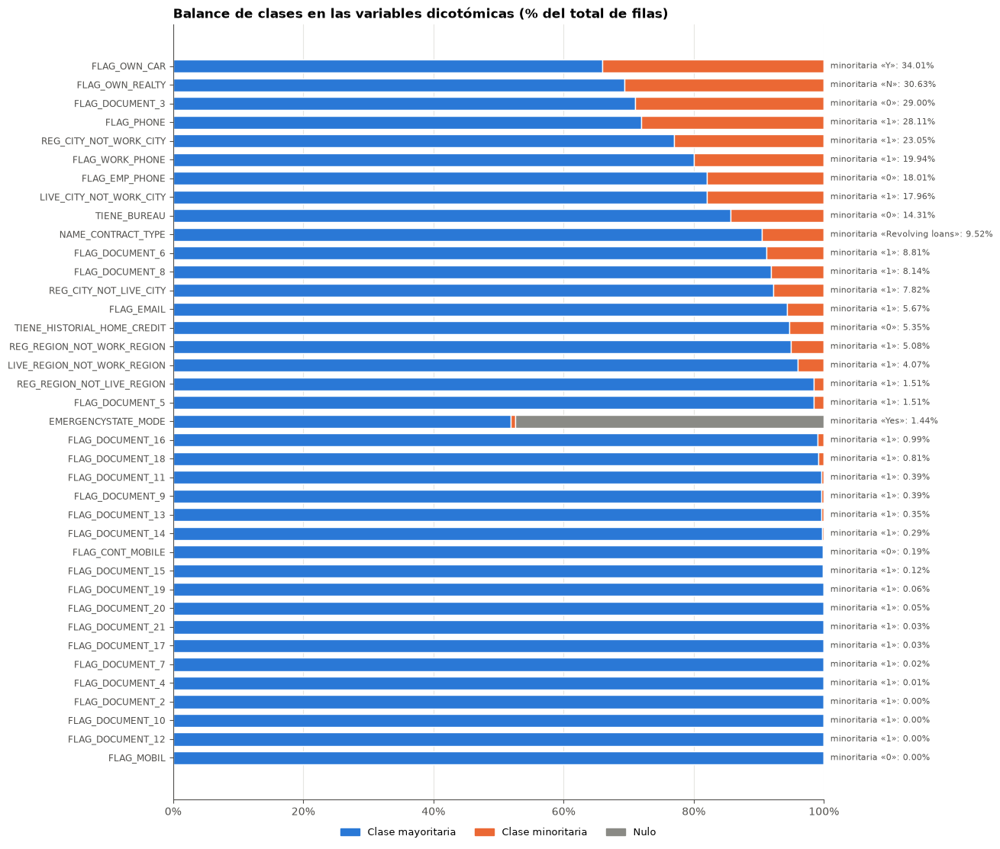

PosixPath('/home/claude/repo/artifacts/eda_figures/dicotomicas/01_balance_dicotomicas.png')

In [38]:
def grafico_target():
    vc = df[COL_TARGET].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6.5, 4))
    barras = ax.bar(["0 (paga)", "1 (default)"], vc.values, color=[C_PRINCIPAL, C_TEORICA], width=0.55)
    for b, v in zip(barras, vc.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / vc.sum():.2%})", ha="center", va="bottom", fontsize=10, color=C_TEXTO)
    ax.set_ylim(0, vc.max() * 1.18)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="x", visible=False)
    ax.set_title("Variable objetivo: TARGET")
    ax.set_ylabel("Número de clientes")
    return guardar_figura(fig, "dicotomicas", "00_TARGET")


def grafico_balance_dicotomicas():
    filas = []
    for c in DICO.index:
        vc = df[c].value_counts()
        filas.append({"variable": c, "mayoritaria": vc.iloc[0] / N, "minoritaria": vc.iloc[1] / N, "nulo": df[c].isna().mean(),
                      "etq": DICO.loc[c, "clase_minoritaria"], "p_min": DICO.loc[c, "pct_minoritaria"]})
    t = pd.DataFrame(filas).set_index("variable")
    fig, ax = plt.subplots(figsize=(11, 0.3 * len(t) + 1.8))
    y = np.arange(len(t))
    ax.barh(y, t["mayoritaria"], color=C_PRINCIPAL, height=0.7, edgecolor="white", linewidth=1)
    ax.barh(y, t["minoritaria"], left=t["mayoritaria"], color=C_TEORICA, height=0.7, edgecolor="white", linewidth=1)
    ax.barh(y, t["nulo"], left=t["mayoritaria"] + t["minoritaria"], color=C_REF, height=0.7, edgecolor="white", linewidth=1)
    for yi, (_, fila) in zip(y, t.iterrows()):
        ax.text(1.01, yi, f"minoritaria «{fila['etq']}»: {fila['p_min']:.2%}", va="center", fontsize=8, color=C_TEXTO2)
    ax.set_yticks(y); ax.set_yticklabels(t.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.grid(axis="y", visible=False)
    ax.set_title("Balance de clases en las variables dicotómicas (% del total de filas)")
    ax.legend(handles=[Patch(color=C_PRINCIPAL, label="Clase mayoritaria"), Patch(color=C_TEORICA, label="Clase minoritaria"), Patch(color=C_REF, label="Nulo")],
              loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=3)
    return guardar_figura(fig, "dicotomicas", "01_balance_dicotomicas")


grafico_target()
grafico_balance_dicotomicas()

#### Categóricas

In [39]:
def graficar_categorica(col, top=15):
    s = df[col]
    n_nulos = int(s.isna().sum())
    vc = s.value_counts(dropna=True)
    ordinal = pd.api.types.is_numeric_dtype(s)
    if ordinal:
        vc = vc.sort_index()
        vc.index = [int(i) if float(i).is_integer() else i for i in vc.index]
    k = len(vc)

    if k > top and not ordinal:
        etiquetas = [str(i) for i in vc.index[:top]] + [f"Otras ({k - top} categorías)"]
        valores = list(vc.values[:top]) + [int(vc.values[top:].sum())]
        tipos_barra = ["cat"] * top + ["otras"]
    else:
        etiquetas = [str(i) for i in vc.index]
        valores = list(vc.values)
        tipos_barra = ["cat"] * k
    if n_nulos > 0:
        etiquetas.append("Nulo"); valores.append(n_nulos); tipos_barra.append("nulo")
    etiquetas = [e if len(e) <= 38 else e[:36] + "…" for e in etiquetas]
    color = {"cat": C_PRINCIPAL, "otras": "#9db8d9", "nulo": C_REF}

    con_panel = k > 8
    fig, axes = plt.subplots(1, 2 if con_panel else 1, figsize=(13 if con_panel else 9, max(3.4, 0.36 * len(etiquetas) + 1.6)),
                             gridspec_kw={"width_ratios": [2.2, 1]} if con_panel else None)
    ax = axes[0] if con_panel else axes
    y = np.arange(len(etiquetas))
    ax.barh(y, valores, color=[color[t] for t in tipos_barra], height=0.7)
    xmax = max(valores)
    for yi, v in zip(y, valores):
        ax.text(v + xmax * 0.01, yi, f"{v:,} ({v / N:.1%})", va="center", fontsize=8.5, color=C_TEXTO2)
    ax.set_yticks(y); ax.set_yticklabels(etiquetas, fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, xmax * 1.22)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Número de clientes")
    ax.set_title(col, pad=18)
    m = CATM.loc[col]
    ax.annotate(f"{m['n_categorias']} categorías · fill rate {m['fill_rate']:.1%} · moda {m['pct_moda']:.1%} · entropía normalizada {m['entropia_norm']:.2f} · HHI {m['hhi']:.3f}",
                xy=(0, 1), xycoords="axes fraction", xytext=(0, 5), textcoords="offset points", fontsize=9, color=C_TEXTO2)

    if con_panel:
        p_ord = vc.sort_values(ascending=False) / vc.sum()
        acum = p_ord.cumsum().to_numpy()
        axes[1].plot(np.arange(1, len(acum) + 1), acum, color=C_PRINCIPAL, lw=2, marker="o", ms=3)
        axes[1].axhline(0.8, color=C_REF, lw=1, ls="--")
        axes[1].set_ylim(0, 1.02)
        axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
        axes[1].set_xlabel("Nº de categorías (de mayor a menor frecuencia)")
        axes[1].set_ylabel("% acumulado de observaciones no nulas")
        axes[1].set_title("Concentración")
    fig.tight_layout()
    return guardar_figura(fig, "categoricas", col)

#### `CODE_GENDER`

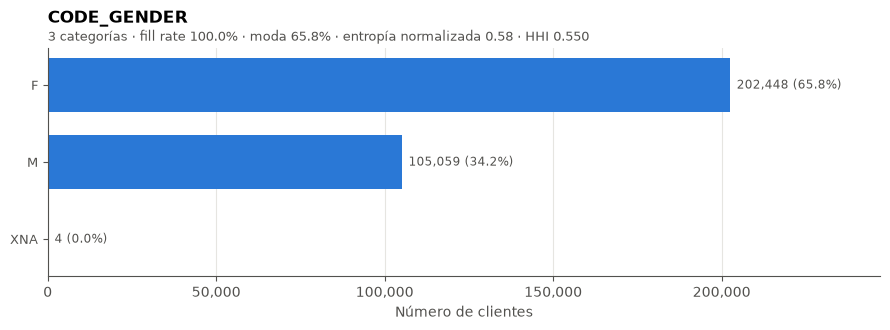

#### `NAME_TYPE_SUITE`

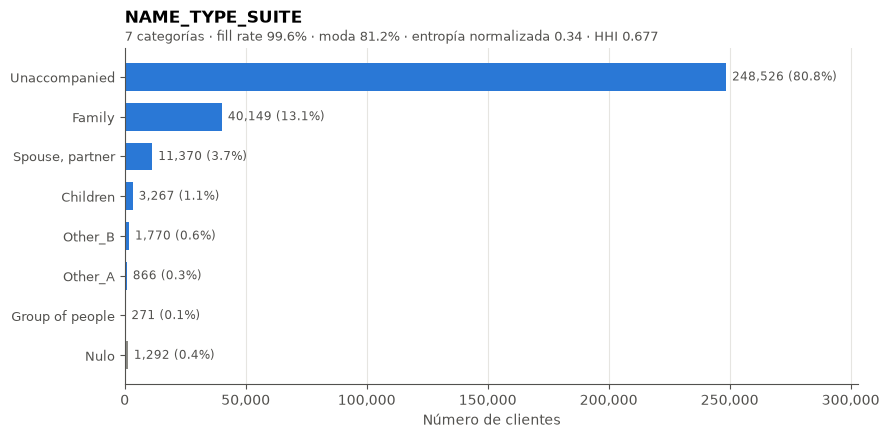

#### `NAME_INCOME_TYPE`

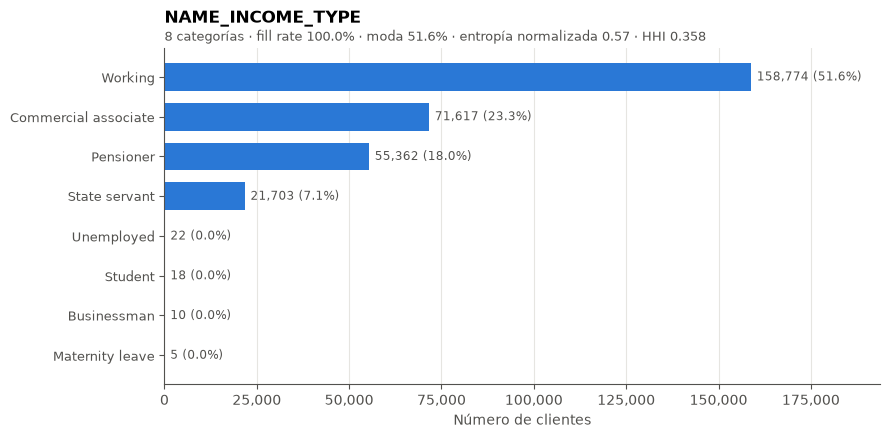

#### `NAME_EDUCATION_TYPE`

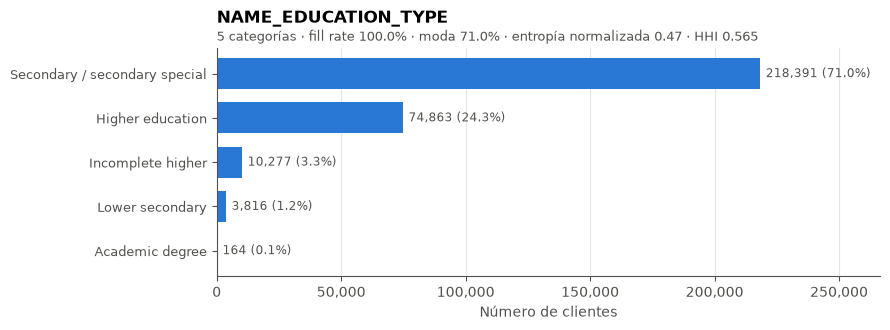

#### `NAME_FAMILY_STATUS`

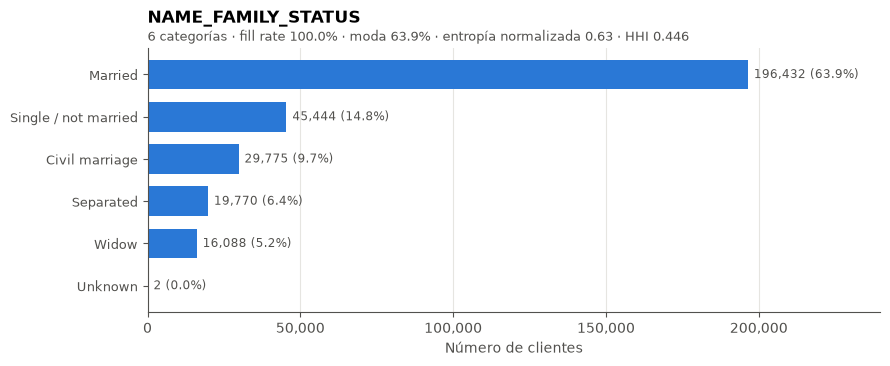

#### `NAME_HOUSING_TYPE`

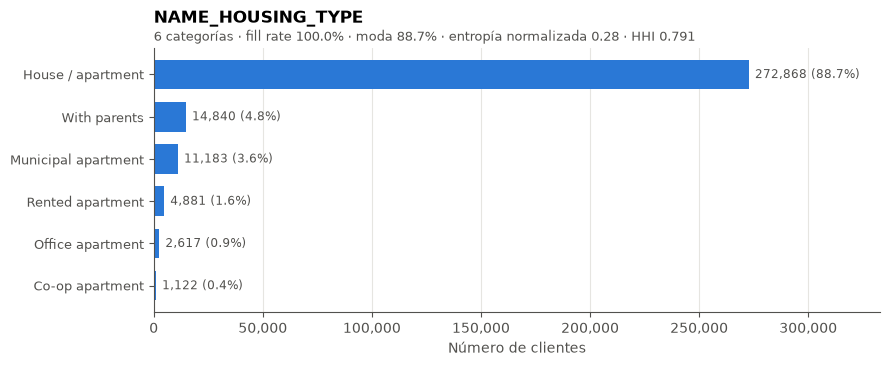

#### `OCCUPATION_TYPE`

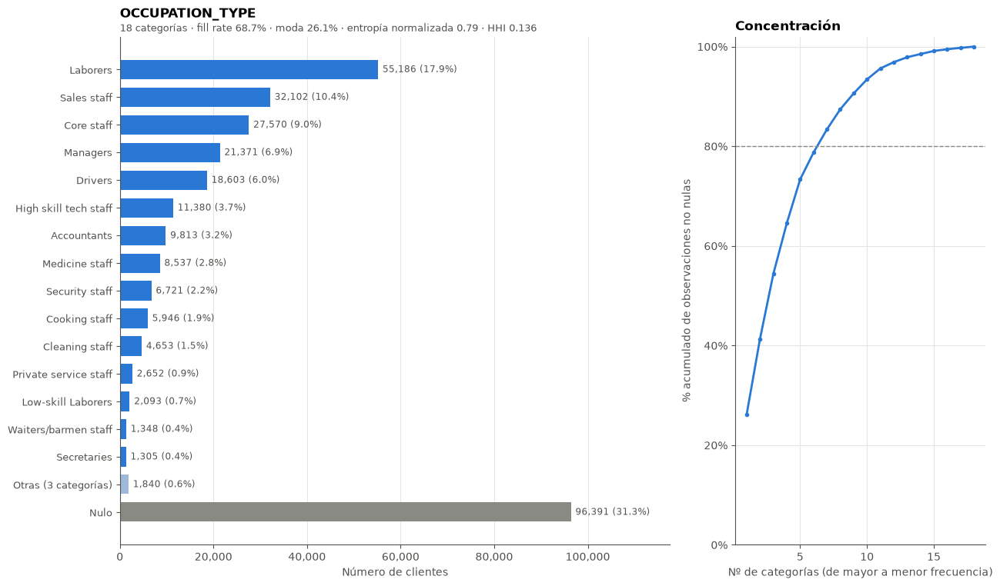

#### `REGION_RATING_CLIENT`

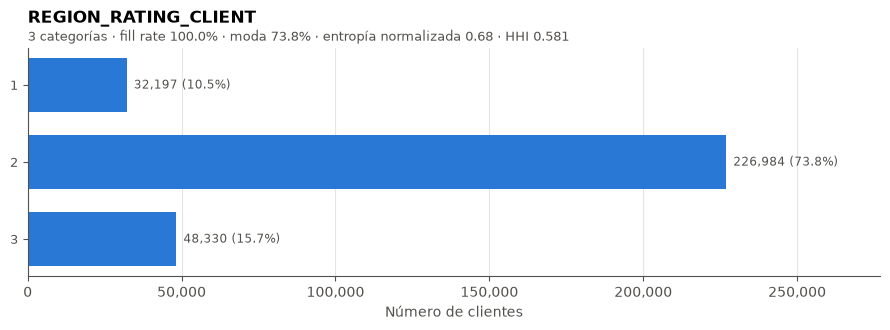

#### `REGION_RATING_CLIENT_W_CITY`

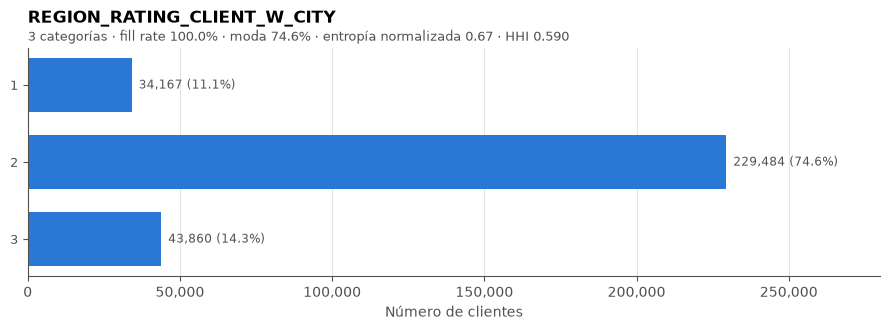

#### `WEEKDAY_APPR_PROCESS_START`

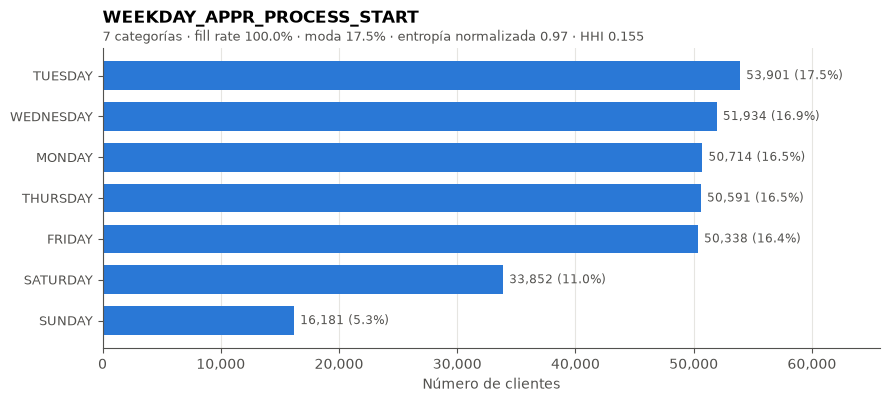

#### `ORGANIZATION_TYPE`

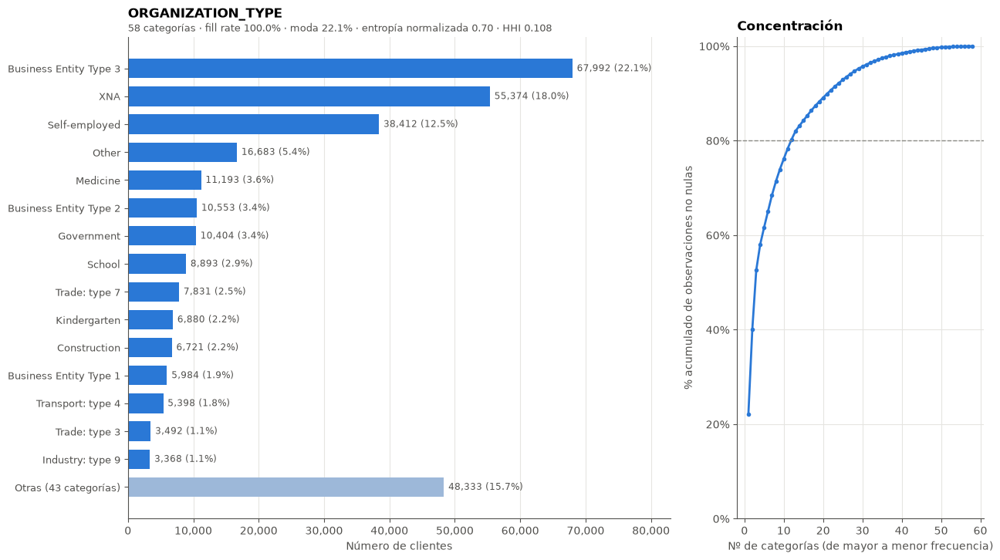

#### `FONDKAPREMONT_MODE`

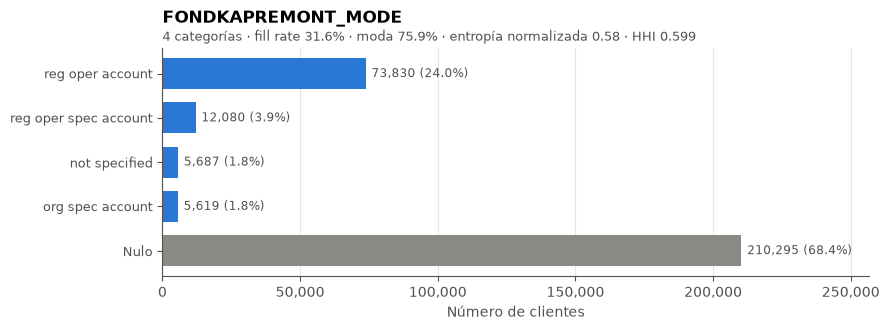

#### `HOUSETYPE_MODE`

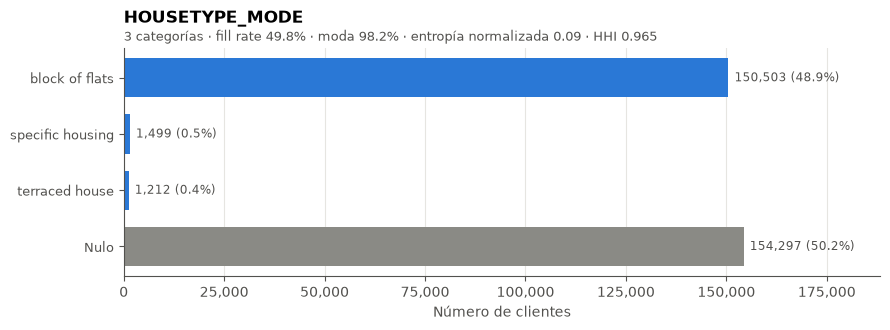

#### `WALLSMATERIAL_MODE`

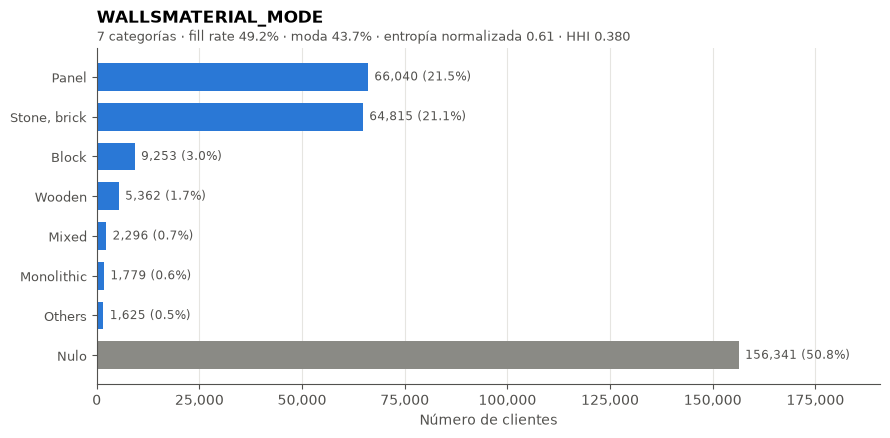

#### `HC_N_OPERACIONES_TARJETA`

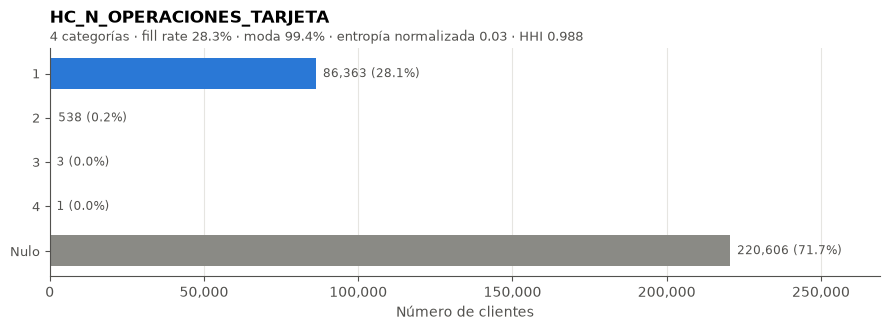

In [40]:
for col in CATEGORICAS:
    display(Markdown(f"#### `{col}`"))
    graficar_categorica(col)

### Observaciones del univariado
*(Espacio para anotar hallazgos y decisiones antes de pasar al bivariado.)*

---
## Paso 5) EDA bivariado: variables explicativas vs target
*Pendiente (fuera de este notebook).*